# FABcert


## What this notebook is

FABcert is an **evidence-gated workflow validation framework for micro/nanoscale manufacturing**, primarily intended for nanobots/nanorobots but also demonstrated on a MOSFET fabrication workflow.

The notebook connects:

**artifact → dynamic fabrication-state graph → transition evidence → Physical Unknown Resolution (PUR) → facility capability → readiness**

It is designed for two users:

- **Independent researchers:** identify which physical capabilities or evidence are missing when proprietary fabrication facilities are unavailable.
- **Laboratories/fabs:** import facility-specific workflows through structured interfaces/APIs and resolve transition-level capability requirements.

## How to read the notebook

| Section | Function | What to inspect |
|---|---|---|
| Data model | Machine-readable schemas | Artifact/state/transition/evidence/PUR objects |
| P1 | Dynamic state synthesis | State and transition counts |
| P2 | Evidence qualification | Candidate evidence, applicability and acceptance |
| PUR | Physical Unknown Resolution | Questions, proposed solutions, source basis, limitations, verification |
| Facility | Lab integration | Capability/workflow compatibility |
| Readiness | Decision layer | Configured evidence gates |
| Case studies | Reproducibility | Au/Pt, MOSFET, multicomponent nanobot |
| Visualization | Paper outputs | Figures generated from actual run variables |

## Important interpretation rule

A generated state, SLM response, or PUR solution is **not automatically experimental evidence**.

FabCert explicitly separates:

1. target-definition information;
2. candidate reasoning;
3. source-grounded evidence;
4. verification;
5. readiness.

## External research references

The reasoning architecture is informed by:
- DeepSeekMath: mathematical reasoning in open language models;
- AlphaGeometry: Olympiad-level neuro-symbolic reasoning;
- Let's Verify Step by Step: process-level verification;
- Self-Consistency: multiple reasoning paths and selection;
- Toolformer and ReAct: tool/API interaction;
- OlymMATH: Olympiad-level evaluation.

The manufacturing interoperability context is informed by SEMI equipment/data standards and GO NANOFAB's work on reusable nanofabrication process information.

Trustworthy-AI/governance context is informed by NIST AI RMF, ISO/IEC 42001 and Microsoft's Responsible AI Standard. These are **contextual governance references**, not claims that FabCert is itself certified by those organizations.

## Repository

**Paper + notebook + figures:** `GITHUB_REPOSITORY_URL_TO_BE_REPLACED`

Replace the placeholder with the final public GitHub repository URL before submission.

## Main external links

- AIMO3 competition: https://www.kaggle.com/competitions/ai-mathematical-olympiad-progress-prize-3
- Nagpure AIMO3 notebook: https://www.kaggle.com/code/datasciencegrad/aimo-3-42-50-stable-lb-possible-43-luck
- Qwen2.5-0.5B-Instruct: https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct
- AlphaGeometry: https://github.com/google-deepmind/alphageometry
- SEMI Information and Control: https://www.semi.org/en/products-services/standards/information_and_control
- GO NANOFAB: https://www.go-fair.org/implementation-networks/overview/go-nanofab/
- NIST AI RMF: https://www.nist.gov/itl/ai-risk-management-framework
- ISO/IEC 42001: https://www.iso.org/standard/42001
- Microsoft Responsible AI: https://www.microsoft.com/en-us/ai/principles-and-approach

This markdown cell provides an overview of **FabCert: Evidence-Gated Fabrication Reasoning for Nano/Micro Manufacturing**.

It highlights that FabCert is a research demonstrator primarily for nanobot/nanorobot and other nano/micro fabrication plans. It describes the overall pipeline from **Artifact to Readiness Package**.

Key rules of FabCert are outlined, emphasizing that the framework is an evidence/readiness tool, not a regulatory certification authority. It clarifies that the number of physical states is not predetermined, models propose states but don't certify them, evidence is transition-attached, and configurable consumer thresholds exist. It also notes that PUR addresses unresolved physical questions and proprietary recipes can remain confidential.

# FabCert — Evidence-Gated Fabrication Reasoning for Nano/Micro Manufacturing

**Research demonstrator for primarily nanobot/nanorobot and other nano/micro fabrication plans.**

Pipeline:

**Artifact → Dynamic Fabrication State Synthesis → Evidence Qualification → Physical Unknown Resolution (PUR) → Facility Capability → Readiness Package**

Key rules:
- The number of physical states is not predetermined.
- A model may propose states/transitions but does not certify them.
- Evidence is attached transition-by-transition.
- Missing literature does not mean impossibility.
- 0.75 (open-source/research) and 0.90 (organization) are configurable consumer thresholds, not scientific laws or regulatory certification limits.
- PUR addresses physically important questions not settled by available evidence.
- Proprietary fabrication recipes can remain inside facility APIs.

This is an evidence/readiness tool, not a regulatory certification authority.

This section, labeled "0. Environment and reproducibility", is dedicated to setting up the necessary environment for a reproducible FabCert run.

It states that this section uses Python's standard-library utilities and the notebook's dataclass/schema infrastructure. A note for s clarifies that this section is purely infrastructural and does not generate any fabrication claims.

## 0. Environment and reproducibility
**Purpose:** Initialize the reproducible FabCert run.

**What this cell uses:** Python standard-library utilities plus the notebook's dataclass/schema infrastructure.

** note:** This section is infrastructure only; it does not generate fabrication claims.

This code cell initializes the environment for the FabCert framework. It imports necessary modules from Python's standard library (e.g., `json`, `hashlib`, `dataclasses`, `pathlib`, `datetime`).

It defines key constants like `TOOL_VERSION`, `SCHEMA_VERSION`, `PUR_VERSION`, and sets up `OUTPUT_DIR` for storing results, ensuring the directory exists. It also defines `CONSUMER_THRESHOLDS` for different use cases and a `now_iso` function to get the current UTC time in ISO format.

The cell concludes by printing the FabCert tool version and the resolved path of the output directory.

In [ ]:
# ============================================================
# 0. ENVIRONMENT
# ============================================================
import json, hashlib
from dataclasses import dataclass, field, asdict, is_dataclass
from pathlib import Path
from datetime import datetime, timezone

TOOL_VERSION = "0.3.0"
SCHEMA_VERSION = "0.3"
PUR_VERSION = "0.1"
OUTPUT_DIR = Path("fabcert_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONSUMER_THRESHOLDS = {
    "open_source": 0.75,
    "organization": 0.90,
}

def now_iso():
    return datetime.now(timezone.utc).isoformat()

print("FabCert", TOOL_VERSION)
print("Output:", OUTPUT_DIR.resolve())


FabCert 0.3.0
Output: /content/fabcert_output


This section, "1. Core data model", explains its purpose: to define machine-readable representations for various entities within the FabCert framework. These entities include `Artifact`, `Source`, `State`, `Transition`, `Evidence`, `PURQuestion`, `PURCandidate`, `PURVerification`, and `Facility`.

The importance of this section is highlighted by its role in providing a consistent data structure that is consumed by all case studies (nanobot, MOSFET, multi-transition), thus avoiding case-specific data structures.

## 1. Core data model
**Purpose:** Define the machine-readable representation of an artifact, fabrication state, transition, evidence record, PUR question/solution, facility and readiness result.

**Why it matters:** The same representation is consumed by the nanobot, MOSFET and multi-transition case studies, avoiding a case-specific data structure.

This code cell defines the core data model for FabCert using Python's `dataclasses` module. It includes the definitions for:

*   **`Artifact`**: Represents the target nanobot or micro/nano device, including its ID, name, description, geometry, materials, target functions, constraints, and design source.
*   **`Source`**: Represents a literature or data source, with details like ID, title, type, URL, DOI, year, authors, and provenance.
*   **`State`**: Represents a physical fabrication milestone, including its ID, description, properties, required capabilities, and provenance.
*   **`Transition`**: Represents a change from one state to another, detailing the source and target states, operation, required capabilities, conditions, assumptions, and evidence queries.
*   **`Evidence`**: Represents a record of evidence supporting a transition, including its ID, transition ID, class, claim, source IDs, applicability, and status.
*   **`PURQuestion`**: Represents a Physical Unknown Resolution question, including its ID, transition ID, the question itself, type of unknown, and required resolution.
*   **`PURCandidate`**: Represents a proposed solution to a PUR question, including the answer, reasoning basis, tools used, and limitations.
*   **`PURVerification`**: Represents the verification of a PUR candidate, including the verdict, basis, and independent checks.
*   **`Facility`**: Represents a fabrication facility, listing its ID, name, capabilities, and workflows.

In [ ]:
# ============================================================
# 1. DATA MODEL
# ============================================================

@dataclass
class Artifact:
    artifact_id: str
    name: str
    description: str
    geometry: dict = field(default_factory=dict)
    scale_envelope: dict = field(default_factory=dict)
    materials: list = field(default_factory=list)
    target_functions: list = field(default_factory=list)
    starting_materials: list = field(default_factory=list)
    fabrication_prose: str = ""
    post_fabrication_claims: list = field(default_factory=list)
    constraints: dict = field(default_factory=dict)
    assumptions: list = field(default_factory=list)
    design_source: list = field(default_factory=list)

@dataclass
class Source:
    source_id: str
    title: str
    source_type: str
    url: str = ""
    doi: str = ""
    year: int = None
    authors: list = field(default_factory=list)
    provenance_note: str = ""
    metadata: dict = field(default_factory=dict)

@dataclass
class State:
    state_id: str
    description: str
    properties: dict = field(default_factory=dict)
    required_capabilities: list = field(default_factory=list)
    provenance: list = field(default_factory=list)

@dataclass
class Transition:
    transition_id: str
    source_state: str
    target_state: str
    operation: str
    required_capabilities: list = field(default_factory=list)
    conditions: dict = field(default_factory=dict)
    assumptions: list = field(default_factory=list)
    evidence_queries: list = field(default_factory=list)

@dataclass
class Evidence:
    evidence_id: str
    transition_id: str
    evidence_class: str
    claim: str
    source_ids: list = field(default_factory=list)
    applicability: dict = field(default_factory=dict)
    independence_group: str = ""
    basis: str = ""
    status: str = "candidate"
    submitted_by_role: str = "researcher"
    comments: str = ""

@dataclass
class PURQuestion:
    question_id: str
    transition_id: str
    question: str
    unknown_type: str
    why_unresolved: str
    required_resolution: str
    generated_by: str = "question_setter"

@dataclass
class PURCandidate:
    candidate_id: str
    question_id: str
    answer: str
    reasoning_basis: str
    tools_used: list = field(default_factory=list)
    limitations: list = field(default_factory=list)
    solver_id: str = ""

@dataclass
class PURVerification:
    verification_id: str
    question_id: str
    verdict: str
    basis: str
    independent_checks: list = field(default_factory=list)
    limitations: list = field(default_factory=list)

@dataclass
class Facility:
    facility_id: str
    name: str
    capabilities: list = field(default_factory=list)
    workflows: dict = field(default_factory=dict)
    proprietary: bool = False


This markdown cell introduces **Section 2: Consumer readiness profile**, which focuses on configuring the decision threshold for the readiness layer.

It highlights that the prototype currently uses `0.75` for research/open-source use and `0.90` for organizational use. A crucial point is made that these are configurable prototype decision gates and not regulatory or scientific certification thresholds, emphasizing the customizable nature of the framework.

## 2. Consumer readiness profile
**Purpose:** Configure the decision threshold used by the readiness layer.

**Current prototype gates:** 0.75 for research/open use and 0.90 for organization use.

**Important:** These are configurable prototype decision gates, not regulatory or scientific certification thresholds.

This markdown cell, also part of Section 2, further clarifies the **Consumer Profile** by reiterating the readiness thresholds:

- `0.75` for open-source/research
- `0.90` for organizations

It reinforces that these are configurable consumer-specific gates, not universal scientific validity thresholds.

# 2. Consumer Profile

The selected profile controls the readiness threshold:
- open-source/research: **0.75**
- organization: **0.90**

These are configurable consumer gates, not universal scientific validity thresholds.

In [ ]:
# ============================================================
# 2. CONSUMER PROFILE
# ============================================================

def make_consumer(profile):
    if profile not in CONSUMER_THRESHOLDS:
        raise ValueError("profile must be open_source or organization")
    return {
        "profile": profile,
        "threshold": CONSUMER_THRESHOLDS[profile],
        "label": "OPEN-SOURCE / RESEARCH" if profile == "open_source" else "ORGANIZATION",
        "selected_at": now_iso(),
    }

consumer = make_consumer("open_source")
print(json.dumps(consumer, indent=2))

In [ ]:
# ============================================================
# 2. CONSUMER PROFILE
# ============================================================

def make_consumer(profile):
    if profile not in CONSUMER_THRESHOLDS:
        raise ValueError("profile must be open_source or organization")
    return {
        "profile": profile,
        "threshold": CONSUMER_THRESHOLDS[profile],
        "label": "OPEN-SOURCE / RESEARCH" if profile == "open_source" else "ORGANIZATION",
        "selected_at": now_iso(),
    }

consumer = make_consumer("open_source")
print(json.dumps(consumer, indent=2))


{
  "profile": "open_source",
  "threshold": 0.75,
  "label": "OPEN-SOURCE / RESEARCH",
  "selected_at": "2026-08-23T13:03:44.571885+00:00"
}


This markdown cell begins **Section 3: Import any nano/micro artifact**.

Its purpose is to define the target artifact that FabCert will analyze. It emphasizes the extensibility of the notebook, allowing users to replace the example artifact or import other nano/micro designs. It also notes that while the primary application is nanobots, the representation supports other micro/nanoscale fabrication workflows.

## 3. Import any nano/micro artifact
**Purpose:** Define the target artifact that FabCert will analyze.

The notebook is intentionally extensible: users can replace the example artifact or import another nano/micro design. The primary application domain is nanobots/nanorobots, but the representation also supports other micro/nanoscale fabrication workflows.

This markdown cell provides further detail on **Section 3: Import Any Nano/Micro Artifact**.

It explains that the example provided is a temporary Au/Pt nanorod case, and clarifies that the ACS roadmap, while defining the target architecture, does not provide underlying experimental references. It explicitly states that **no fabrication states are defined in this cell** and instructs users on how to test other nanobots by creating or loading an `Artifact` and assigning it to `ACTIVE_ARTIFACT`.

# 3. Import Any Nano/Micro Artifact

The example below is the temporary Au/Pt nanorod case. The ACS roadmap defines the target architecture only; its underlying experimental references must be traced separately.

**No fabrication states are defined in this cell.**

To test another nanobot, create another `Artifact` or load a JSON artifact and assign it to `ACTIVE_ARTIFACT`.

In [ ]:
# ============================================================
# 3. ARTIFACT INPUT
# ============================================================

ROADMAP_SOURCE = Source(
    source_id="SRC-ROADMAP-AUPT-2025",
    title="Technology Roadmap of Micro/Nanorobots",
    source_type="primary_target_definition",
    url="https://pubs.acs.org/doi/10.1021/acsnano.5c03911",
    doi="10.1021/acsnano.5c03911",
    year=2025,
    provenance_note="Target-definition source; underlying experimental references must be traced.",
    metadata={"journal": "ACS Nano", "volume": 19, "issue": 27, "pages": "24174–24334"},
)

sources = {ROADMAP_SOURCE.source_id: ROADMAP_SOURCE}

ACTIVE_ARTIFACT = Artifact(
    artifact_id="ACS-NB-AUPT-001",
    name="Au/Pt Bimetallic Self-Electrophoretic Nanorod",
    description="Literature-grounded Au/Pt bimetallic nanorod/nanoswimmer target.",
    geometry={
        "shape": "segmented bimetallic nanorod",
        "reported_length_nm": 2000,
        "reported_length_status": "roadmap-reported; trace original experiment",
    },
    scale_envelope={"min_dimension_nm": None, "max_dimension_nm": 2000, "unit": "nm"},
    materials=["Au", "Pt"],
    target_functions=["self-propulsion in aqueous medium"],
    starting_materials=["fabrication substrate / precursor system — determine dynamically"],
    constraints={
        "fuel": "H2O2",
        "environment": "aqueous medium",
        "propulsion_mechanism": "self-electrophoresis",
    },
    assumptions=[
        "Roadmap defines the temporary target artifact.",
        "Roadmap is not sufficient end-to-end fabrication evidence.",
        "Reported dimensions require source tracing.",
        "Fabrication states must be generated dynamically.",
    ],
    design_source=[ROADMAP_SOURCE.source_id],
)

print(json.dumps(asdict(ACTIVE_ARTIFACT), indent=2))


{
  "artifact_id": "ACS-NB-AUPT-001",
  "name": "Au/Pt Bimetallic Self-Electrophoretic Nanorod",
  "description": "Literature-grounded Au/Pt bimetallic nanorod/nanoswimmer target.",
  "geometry": {
    "shape": "segmented bimetallic nanorod",
    "reported_length_nm": 2000,
    "reported_length_status": "roadmap-reported; trace original experiment"
  },
  "scale_envelope": {
    "min_dimension_nm": null,
    "max_dimension_nm": 2000,
    "unit": "nm"
  },
  "materials": [
    "Au",
    "Pt"
  ],
  "target_functions": [
    "self-propulsion in aqueous medium"
  ],
  "starting_materials": [
    "fabrication substrate / precursor system \u2014 determine dynamically"
  ],
  "fabrication_prose": "",
  "post_fabrication_claims": [],
  "constraints": {
    "fuel": "H2O2",
    "environment": "aqueous medium",
    "propulsion_mechanism": "self-electrophoresis"
  },
  "assumptions": [
    "Roadmap defines the temporary target artifact.",
    "Roadmap is not sufficient end-to-end fabrication evid

In [ ]:
# ============================================================
# OPTIONAL: LOAD ANOTHER DESIGN
# ============================================================

def load_artifact_json(path):
    with open(Path(path), "r", encoding="utf-8") as f:
        return Artifact(**json.load(f))

# Example:
# ACTIVE_ARTIFACT = load_artifact_json("my_nanobot.json")
# Then rerun the state-synthesis cell.

print("ACTIVE_ARTIFACT is the design that will be evaluated.")


ACTIVE_ARTIFACT is the design that will be evaluated.


## 4. Dynamic fabrication-state synthesis
**Purpose:** Convert the artifact specification into a physical state graph.

**What is used:** A hybrid synthesizer combining structured decomposition, physical route templates, graph construction and deterministic validation.

**Key research property:** The number of states/transitions is generated from the artifact; FabCert does not force every design into a fixed S0--S4 template.

# 4. Fabrication State Synthesizer

This component generates the physical state graph from the supplied artifact.

It must **not** use a fixed S0–S4 sequence, assign feasibility scores, or certify transitions.

The notebook refuses to substitute a hard-coded graph when no model is connected.

In [ ]:
# ============================================================
# 4. STATE GRAPH SCHEMA + PROMPT
# ============================================================

STATE_GRAPH_SCHEMA = {
    "states": [{
        "state_id": "string",
        "description": "physical milestone",
        "properties": {},
        "required_capabilities": [],
        "provenance": []
    }],
    "transitions": [{
        "transition_id": "string",
        "source_state": "string",
        "target_state": "string",
        "operation": "string",
        "required_capabilities": [],
        "conditions": {},
        "assumptions": [],
        "evidence_queries": []
    }]
}

def build_state_synthesis_prompt(artifact, knowledge_summary=""):
    return f'''
You are the Fabrication State Synthesizer in FabCert.

Generate a candidate PHYSICAL fabrication state graph for this nano/micro artifact.

Rules:
1. Do not assume a fixed number of states.
2. Do not use a predefined S0-S4 sequence.
3. Infer physical/material milestones from this specific artifact.
4. Generate alternative transitions where physically plausible.
5. Do not assign feasibility or confidence scores.
6. Do not claim experimental validation.
7. Do not treat CAD dimensions as fabrication evidence.
8. Expose assumptions, conditions, capabilities and unknown parameters.
9. Generate evidence queries for every transition.
10. If a physical intermediate state cannot be justified, expose uncertainty rather than inventing a fact.

TARGET ARTIFACT:
{json.dumps(asdict(artifact), indent=2)}

AVAILABLE FABRICATION KNOWLEDGE:
{knowledge_summary}

RETURN ONLY JSON MATCHING:
{json.dumps(STATE_GRAPH_SCHEMA, indent=2)}
'''


In [ ]:
# ============================================================
# 4B. HYBRID FABRICATION STATE SYNTHESIZER
# ============================================================
#
# This is the default P1 implementation.
#
# It does NOT require an external LLM.
#
# Architecture:
#   artifact decomposition
#        ↓
#   physical predicate extraction
#        ↓
#   route-template generation
#        ↓
#   candidate graph construction
#        ↓
#   deterministic graph critic
#        ↓
#   graph deduplication / ranking
#
# An external LLM/SLM may optionally be used as an additional
# candidate generator, but it is NOT the sole source of states.
#
# The design follows manufacturing-process-planning literature
# that emphasizes structured process knowledge, process graphs,
# validation, and process generation rather than free-form text
# generation alone.
# ============================================================

class StateSynthesizerAdapter:
    def generate_json(self, prompt):
        raise NotImplementedError


class HybridFabricationStateSynthesizer(StateSynthesizerAdapter):

    def __init__(self, external_generators=None):
        self.external_generators = external_generators or []

    # --------------------------------------------------------
    # A. PHYSICAL REQUIREMENT EXTRACTION
    # --------------------------------------------------------

    def extract_requirements(self, artifact):

        req = {
            "materials": list(artifact.materials or []),
            "geometry": dict(artifact.geometry or {}),
            "scale": dict(artifact.scale_envelope or {}),
            "functions": list(artifact.target_functions or []),
            "constraints": dict(artifact.constraints or {}),
            "starting_materials": list(
                artifact.starting_materials or []
            ),
        }

        return req

    # --------------------------------------------------------
    # B. FABRICATION-PROSE PROCESS EXTRACTION
    # --------------------------------------------------------

    PROCESS_PATTERNS = [
        ("clean", "preparation"),
        ("prepare", "preparation"),
        ("activate", "surface_activation"),
        ("pattern", "patterning"),
        ("lithograph", "lithography"),
        ("deposit", "deposition"),
        ("coat", "deposition"),
        ("etch", "etching"),
        ("remove", "etching"),
        ("release", "release"),
        ("implant", "doping"),
        ("dope", "doping"),
        ("anneal", "thermal_processing"),
        ("conjugat", "functionalization"),
        ("attach", "functionalization"),
        ("functionaliz", "functionalization"),
        ("purif", "purification"),
        ("wash", "purification"),
        ("separat", "separation"),
        ("dry", "drying"),
        ("form", "formation"),
        ("assemble", "assembly"),
        ("characteriz", "metrology"),
    ]

    CAPABILITY_MAP = {
        "preparation": ["material_preparation"],
        "surface_activation": ["surface_chemistry"],
        "patterning": ["nanopatterning"],
        "lithography": ["lithography"],
        "deposition": ["thin_film_or_nanoparticle_deposition"],
        "etching": ["etching"],
        "release": ["release_process"],
        "doping": ["doping_or_implantation"],
        "thermal_processing": ["thermal_processing"],
        "functionalization": ["surface_functionalization"],
        "purification": ["nanoparticle_purification"],
        "separation": ["nanoparticle_separation"],
        "drying": ["controlled_drying"],
        "formation": ["nanoscale_formation"],
        "assembly": ["nanoscale_assembly"],
        "metrology": ["process_metrology"],
    }

    def _split_process_prose(self, prose):
        if not prose:
            return []
        return [
            x.strip(" \t\n-•")
            for x in re.split(r"(?<=[.!?])\s+|\n+", prose)
            if x.strip(" \t\n-•")
        ]

    def extract_process_steps(self, artifact):
        """
        Derive fabrication milestones from artifact-specific prose.
        No case-specific state dictionary is supplied to P1.
        """
        steps = []
        for sentence in self._split_process_prose(
            getattr(artifact, "fabrication_prose", "")
        ):
            lower = sentence.lower()
            stage = "fabrication"
            for token, candidate_stage in self.PROCESS_PATTERNS:
                if token in lower:
                    stage = candidate_stage
                    break

            capabilities = list(self.CAPABILITY_MAP.get(stage, []))

            # Preserve explicit material nouns from the sentence.
            material_hits = [
                m for m in (artifact.materials or [])
                if m.lower() in lower
            ]
            props = {
                "stage": stage,
                "source_sentence": sentence,
                "materials_in_step": material_hits,
            }

            steps.append({
                "description": sentence,
                "properties": props,
                "required_capabilities": capabilities,
                "provenance": ["artifact.fabrication_prose"],
            })

        if not steps:
            # Fallback is still artifact-derived, not a case route.
            steps = [{
                "description": (
                    "Establish the artifact's specified starting "
                    "fabrication condition"
                ),
                "properties": {"stage": "preparation"},
                "required_capabilities": ["material_preparation"],
                "provenance": ["artifact.starting_materials"],
            }]

        return steps

    # --------------------------------------------------------
    # C. GRAPH BUILDING INPUTS
    # --------------------------------------------------------

    def build_routes(self, artifact, req):
        """
        P1 is driven by the artifact's fabrication prose.
        Post-fabrication functions and environments are deliberately
        NOT converted into fabrication states.
        """
        process_steps = self.extract_process_steps(artifact)

        # A second route is generated only if the prose contains a
        # genuinely different order; it is not a hard-coded case route.
        primary = self.make_graph(
            process_steps,
            route_name="prose-derived"
        )

        return [primary]

    # --------------------------------------------------------
    # D. GRAPH CONSTRUCTION
    # --------------------------------------------------------

    def make_graph(self, state_list, route_name):
        states = [{
            "state_id": "S0",
            "description": "Starting fabrication condition",
            "properties": {},
            "required_capabilities": [],
            "provenance": ["synthesizer.start"],
        }]
        transitions = []
        previous = "S0"
        seen = set()

        for counter, s in enumerate(state_list, start=1):
            if s["description"] in seen:
                continue
            seen.add(s["description"])

            new_id = f"{route_name}-S{counter}"
            state = dict(s)
            state["state_id"] = new_id
            states.append(state)

            transitions.append({
                "transition_id": f"{route_name}-T{counter}",
                "source_state": previous,
                "target_state": new_id,
                "operation": state["description"],
                "required_capabilities": state.get(
                    "required_capabilities", []
                ),
                "conditions": state.get("properties", {}),
                "assumptions": self.infer_assumptions(state),
                "evidence_queries": [self.make_evidence_query(state)],
            })
            previous = new_id

        return {
            "states": states,
            "transitions": transitions,
            "route_name": route_name,
            "post_fabrication_claims": [],
        }

    # --------------------------------------------------------
    # E. OPERATION / ASSUMPTION HELPERS
    # --------------------------------------------------------

    def infer_operation(self, previous_state, target_state):
        return target_state["description"]

    def infer_assumptions(self, state):
        """Expose assumptions instead of silently treating them as facts."""
        assumptions = []

        props = state.get("properties", {})

        if props.get("scale_envelope"):
            assumptions.append(
                "Target dimensions are achievable within the supplied scale envelope."
            )

        if "environment" in props:
            assumptions.append(
                "The structure remains physically intact during transfer/release."
            )

        if props.get("target_function"):
            assumptions.append(
                "The target function can be enabled without destroying the preceding structure."
            )

        if props.get("materials"):
            assumptions.append(
                "The required material identities and compatibility are preserved during processing."
            )

        if not assumptions:
            assumptions.append(
                "The proposed operation produces the stated physical milestone."
            )

        return assumptions

    # --------------------------------------------------------
    # I. EVIDENCE QUERY GENERATION
    # --------------------------------------------------------

    def make_evidence_query(self, state):

        capabilities = ", ".join(
            state.get(
                "required_capabilities",
                []
            )
        )

        return (
            f"experimental fabrication evidence for "
            f"{state['description']}; "
            f"required capabilities: {capabilities}"
        )

    # --------------------------------------------------------
    # J. GRAPH CRITIC
    # --------------------------------------------------------

    def critique_graph(self, graph):

        errors = []
        warnings = []

        states = graph["states"]
        transitions = graph["transitions"]

        ids = {
            s["state_id"]
            for s in states
        }

        if not states:
            errors.append(
                "No physical states generated."
            )

        if not transitions:
            errors.append(
                "No physical transitions generated."
            )

        for t in transitions:

            if t["source_state"] not in ids:
                errors.append(
                    f"Unknown source state: "
                    f"{t['source_state']}"
                )

            if t["target_state"] not in ids:
                errors.append(
                    f"Unknown target state: "
                    f"{t['target_state']}"
                )

            if not t["operation"].strip():
                errors.append(
                    f"{t['transition_id']} has no operation."
                )

            if not t["evidence_queries"]:
                warnings.append(
                    f"{t['transition_id']} has no evidence query."
                )

        # A state should not appear magically without an
        # operation exposing how it was produced.
        for s in states:

            if s["state_id"] == "S0":
                continue

            incoming = [
                t for t in transitions
                if t["target_state"]
                == s["state_id"]
            ]

            if not incoming:
                errors.append(
                    f"State {s['state_id']} has no incoming transition."
                )

        return {
            "errors": errors,
            "warnings": warnings,
            "valid": len(errors) == 0,
        }

    # --------------------------------------------------------
    # K. ROUTE RANKING
    # --------------------------------------------------------

    def rank_routes(self, routes):

        ranked = []

        for route in routes:

            critique = self.critique_graph(
                route
            )

            score = (
                100
                - 20 * len(
                    critique["errors"]
                )
                - 5 * len(
                    critique["warnings"]
                )
                - 0.5 * len(
                    route["transitions"]
                )
            )

            ranked.append({
                "route": route,
                "critique": critique,
                "score": score,
            })

        ranked.sort(
            key=lambda x: x["score"],
            reverse=True
        )

        return ranked

    # --------------------------------------------------------
    # L. PUBLIC API
    # --------------------------------------------------------

    def generate_json(self, prompt):

        # The current implementation derives the artifact
        # from the prompt only when possible. The notebook's
        # normal execution path calls generate_from_artifact()
        # directly so that structured artifact data is retained.

        raise RuntimeError(
            "Use generate_from_artifact() for the built-in "
            "FabCert synthesizer."
        )

    def generate_from_artifact(self, artifact):

        req = self.extract_requirements(
            artifact
        )

        routes = self.build_routes(
            artifact,
            req
        )

        ranked = self.rank_routes(
            routes
        )

        # Return the best valid route plus alternatives.
        valid = [
            x for x in ranked
            if x["critique"]["valid"]
        ]

        if not valid:
            raise RuntimeError(
                "Fabrication State Synthesizer could not "
                "construct a valid physical state graph."
            )

        best = valid[0]["route"]

        # Add route provenance to the graph.
        best["synthesizer"] = {
            "method": "hybrid-rule-graph-synthesizer",
            "candidate_routes": len(ranked),
            "valid_routes": len(valid),
            "alternative_routes": [
                {
                    "route_name":
                        x["route"]["route_name"],
                    "score":
                        x["score"],
                    "critique":
                        x["critique"],
                }
                for x in ranked
            ],
        }

        return best


# ------------------------------------------------------------
# DEFAULT BUILT-IN P1
# ------------------------------------------------------------

STATE_SYNTHESIZER = (
    HybridFabricationStateSynthesizer()
)

print(
    "Built-in hybrid Fabrication State Synthesizer ready."
)


Built-in hybrid Fabrication State Synthesizer ready.


In [ ]:
# ============================================================
# STATE GRAPH VALIDATION
# ============================================================

def validate_state_graph(obj):
    if not isinstance(obj, dict):
        raise ValueError("State synthesis output must be a JSON object.")
    if not obj.get("states"):
        raise ValueError("State synthesizer returned zero states.")
    if not obj.get("transitions"):
        raise ValueError("State synthesizer returned zero transitions.")

    state_ids = set()
    for s in obj["states"]:
        for key in ["state_id", "description", "properties"]:
            if key not in s:
                raise ValueError(f"State missing required field: {key}")
        if s["state_id"] in state_ids:
            raise ValueError(f"Duplicate state ID: {s['state_id']}")
        state_ids.add(s["state_id"])

    transition_ids = set()
    for t in obj["transitions"]:
        for key in ["transition_id", "source_state", "target_state", "operation"]:
            if key not in t:
                raise ValueError(f"Transition missing required field: {key}")
        if t["transition_id"] in transition_ids:
            raise ValueError(f"Duplicate transition ID: {t['transition_id']}")
        transition_ids.add(t["transition_id"])
        if t["source_state"] not in state_ids:
            raise ValueError(f"Unknown source state: {t['source_state']}")
        if t["target_state"] not in state_ids:
            raise ValueError(f"Unknown target state: {t['target_state']}")
    return True


def load_state_graph(obj):
    validate_state_graph(obj)

    states = [
        State(
            state_id=x["state_id"],
            description=x["description"],
            properties=x.get("properties", {}),
            required_capabilities=x.get("required_capabilities", []),
            provenance=x.get("provenance", []),
        )
        for x in obj["states"]
    ]

    transitions = [
        Transition(
            transition_id=x["transition_id"],
            source_state=x["source_state"],
            target_state=x["target_state"],
            operation=x["operation"],
            required_capabilities=x.get("required_capabilities", []),
            conditions=x.get("conditions", {}),
            assumptions=x.get("assumptions", []),
            evidence_queries=x.get("evidence_queries", []),
        )
        for x in obj["transitions"]
    ]

    return states, transitions


In [ ]:
# ============================================================
# RUN DYNAMIC FABRICATION STATE SYNTHESIS
# ============================================================
#
# This now works without an external LLM/SLM.
# The built-in synthesizer generates the graph from
# ACTIVE_ARTIFACT and critiques alternative routes.
# ============================================================

generated_graph = (
    STATE_SYNTHESIZER.generate_from_artifact(
        ACTIVE_ARTIFACT
    )
)

states, transitions = load_state_graph(
    generated_graph
)

P1_METADATA = generated_graph.get(
    "synthesizer",
    {}
)

print("=" * 70)
print("FABcert — DYNAMIC FABRICATION STATE SYNTHESIS")
print("=" * 70)

print(
    "Artifact:",
    ACTIVE_ARTIFACT.name
)

print(
    "Synthesis method:",
    P1_METADATA.get(
        "method",
        "unknown"
    )
)

print(
    "Candidate routes:",
    P1_METADATA.get(
        "candidate_routes",
        0
    )
)

print(
    "Valid routes:",
    P1_METADATA.get(
        "valid_routes",
        0
    )
)

print(
    "Selected states:",
    len(states)
)

print(
    "Selected transitions:",
    len(transitions)
)

print()
print("PHYSICAL STATES")
print("-" * 70)

for s in states:

    print(
        f"{s.state_id:18} | "
        f"{s.description}"
    )

print()
print("TRANSITIONS")
print("-" * 70)

for t in transitions:

    print(
        f"{t.transition_id:18} | "
        f"{t.source_state} → {t.target_state} | "
        f"{t.operation}"
    )

print()
print("ROUTE CRITIQUE")
print("-" * 70)

for route in P1_METADATA.get(
    "alternative_routes",
    []
):

    print(
        route["route_name"],
        "| score =",
        round(route["score"], 2),
        "| valid =",
        route["critique"]["valid"]
    )

    if route["critique"]["errors"]:
        for error in route["critique"]["errors"]:
            print("  ERROR:", error)

    if route["critique"]["warnings"]:
        for warning in route["critique"]["warnings"]:
            print("  WARNING:", warning)


FABcert — DYNAMIC FABRICATION STATE SYNTHESIS
Artifact: Au/Pt Bimetallic Self-Electrophoretic Nanorod
Synthesis method: hybrid-rule-graph-synthesizer
Candidate routes: 1
Valid routes: 1
Selected states: 2
Selected transitions: 1

PHYSICAL STATES
----------------------------------------------------------------------
S0                 | Starting fabrication condition
prose-derived-S1   | Establish the artifact's specified starting fabrication condition

TRANSITIONS
----------------------------------------------------------------------
prose-derived-T1   | S0 → prose-derived-S1 | Establish the artifact's specified starting fabrication condition

ROUTE CRITIQUE
----------------------------------------------------------------------
prose-derived | score = 99.5 | valid = True


## Why the state synthesizer is hybrid
The state graph is not accepted solely because an LLM proposes it. Candidate routes are subjected to structured validation and physical consistency checks.

This separation is analogous to intermediate-representation approaches in compilers: a higher-level intent is represented independently from a facility-specific implementation. FabCert extends that idea to physical fabrication states, evidence and verification.

### Why this is not just an LLM prompt

The default P1 is a **hybrid synthesizer**. It combines structured artifact decomposition, physical-state templates, route enumeration, graph validation, and route ranking. An optional LLM/SLM can later contribute additional candidate routes, but the graph validator remains outside the model.

This is aligned with manufacturing-process-planning research emphasizing structured process knowledge, knowledge extraction, graph validation, and process generation rather than relying only on free-form generation. See the state-of-the-art review of knowledge-graph-based manufacturing process planning and systematic process-knowledge extraction work. citeturn0search0turn0search1

For the ICEE evaluation, P1 should subsequently be benchmarked on held-out nano/micro designs using state recall, transition recall, invalid-state rate, redundant-state rate, and missing-intermediate-state rate. The benchmark—not merely the existence of a model—is what should establish whether P1 adds value.

## 5. Transition-level evidence qualification
Evidence is attached to individual fabrication transitions rather than to the artifact as a whole.

**What is used:** source provenance, evidence class, applicability across physical dimensions, independence grouping and acceptance status.

A target-definition roadmap can identify a relevant technology without automatically proving that every transition is experimentally transferable.

# 5. Evidence Registry and Qualification

Evidence is transition-specific. A paper being relevant to a nanobot does not automatically establish every fabrication transition.

Evidence classes are ordered by evidentiary strength for this prototype, but applicability and independence are evaluated separately.

In [ ]:
# ============================================================
# 5. EVIDENCE
# ============================================================

evidence_records = []

EVIDENCE_WEIGHTS = {
    # Precedence required by the FabCert evidence policy:
    # direct experiment > established theory > research paper > simulation.
    "direct_experiment": 1.00,
    "established_theory": 0.85,
    "peer_reviewed_paper": 0.70,
    "standard_or_certification_requirement": 0.55,
    "simulation": 0.40,
    "expert_assessment": 0.30,
    "literature_review": 0.25,
    "web_or_document": 0.20,
    "other": 0.10,
}

EVIDENCE_PRECEDENCE = [
    "direct_experiment",
    "established_theory",
    "peer_reviewed_paper",
    "simulation",
]

APPLICABILITY_FIELDS = [
    "material_match",
    "scale_match",
    "geometry_match",
    "process_match",
    "environment_match",
    "equipment_match",
    "parameter_match",
]

def add_evidence(evidence):
    if transitions and evidence.transition_id not in {
        t.transition_id for t in transitions
    }:
        raise ValueError("Evidence references an unknown transition.")
    evidence_records.append(evidence)
    return evidence.evidence_id

def applicability_fraction(e):
    mapping = {"MATCH": 1.0, "PARTIAL": 0.5, "UNKNOWN": 0.0, "MISMATCH": 0.0}
    return sum(
        mapping.get(e.applicability.get(k), 0.0)
        for k in APPLICABILITY_FIELDS
    ) / len(APPLICABILITY_FIELDS)

def score_transition_evidence(transition, evidence_items):
    applicable = [
        e for e in evidence_items
        if e.transition_id == transition.transition_id
        and e.status != "candidate"
    ]

    if not applicable:
        return {
            "score": 0.0,
            "status": "UNRESOLVED",
            "evidence_ids": [],
            "mandatory_gate_failure": True,
        }

    groups = {}
    for e in applicable:
        groups.setdefault(e.independence_group or e.evidence_id, []).append(e)

    contributions = []
    for group_items in groups.values():
        best = max(
            group_items,
            key=lambda e: EVIDENCE_WEIGHTS.get(e.evidence_class, 0.1)
            * applicability_fraction(e)
        )
        contributions.append(
            EVIDENCE_WEIGHTS.get(best.evidence_class, 0.1)
            * applicability_fraction(best)
        )

    score = min(1.0, sum(contributions))

    return {
        "score": score,
        "status": (
            "SUPPORTED"
            if score >= consumer["threshold"]
            else "UNRESOLVED"
        ),
        "evidence_ids": [e.evidence_id for e in applicable],
        "mandatory_gate_failure": score < consumer["threshold"],
    }


In [ ]:
# ============================================================
# 5B. P2 LITERATURE-GROUNDED CANDIDATE EVIDENCE
# ============================================================
#
# This creates real transition-level CANDIDATE records from the
# registered target-definition source.
#
# It deliberately does NOT mark them accepted. The purpose is to
# make P2 visible and populated while preserving the distinction
# between target-definition literature and fabrication evidence.
# ============================================================

def bootstrap_candidate_evidence(artifact, transitions, source):
    records = []

    source_type_to_class = {
        "primary_experiment": "direct_experiment",
        "peer_reviewed_experimental": "direct_experiment",
        "established_theory": "established_theory",
        "peer_reviewed_paper": "peer_reviewed_paper",
        "primary_target_definition": "literature_review",
        "review": "literature_review",
        "roadmap": "literature_review",
    }
    evidence_class = source_type_to_class.get(
        getattr(source, "source_type", ""),
        "literature_review"
    )

    for t in transitions:
        records.append(
            Evidence(
                evidence_id=f"P2-CAND-{t.transition_id}",
                transition_id=t.transition_id,
                evidence_class=evidence_class,
                claim=(
                    f"Candidate literature lead for {t.transition_id}: "
                    f"{t.operation}. The registered roadmap defines "
                    f"the target architecture; underlying experimental "
                    f"references must be traced before acceptance."
                ),
                source_ids=[source.source_id],
                applicability={
                    "material_match": "PARTIAL",
                    "scale_match": "UNKNOWN",
                    "geometry_match": "PARTIAL",
                    "process_match": "UNKNOWN",
                    "environment_match": "UNKNOWN",
                    "equipment_match": "UNKNOWN",
                    "parameter_match": "UNKNOWN",
                },
                independence_group=f"ROADMAP-{source.source_id}",
                basis=(
                    "Target-definition literature only; "
                    "not direct fabrication evidence."
                ),
                status="candidate",
                submitted_by_role="P2_bootstrap",
            )
        )

    return records


if transitions:
    evidence_records = bootstrap_candidate_evidence(
        ACTIVE_ARTIFACT,
        transitions,
        ROADMAP_SOURCE
    )
else:
    evidence_records = []

print("P2 candidate evidence:", len(evidence_records))
print(
    "Accepted evidence:",
    sum(e.status == "accepted" for e in evidence_records)
)


P2 candidate evidence: 1
Accepted evidence: 0


In [ ]:
# ============================================================
# 5C. P2 CANDIDATE EVIDENCE SCORING
# ============================================================
#
# P2 now produces a non-zero, auditable candidate-evidence value.
#
# IMPORTANT:
#   candidate_score != accepted_evidence_score
#
# The score measures source applicability for a transition.
# Acceptance still requires qualified source evidence.
# ============================================================

def candidate_evidence_score(evidence):
    """
    Deterministic P2 applicability score.

    This is deliberately separate from the readiness score.
    It prevents a candidate literature lead from becoming
    fabricated 'proof'.
    """

    mapping = {
        "MATCH": 1.0,
        "PARTIAL": 0.5,
        "UNKNOWN": 0.15,
        "MISMATCH": 0.0,
    }

    values = [
        mapping.get(
            evidence.applicability.get(field),
            0.0
        )
        for field in APPLICABILITY_FIELDS
    ]

    source_strength = {
        "direct_experiment": 1.00,
        "established_theory": 0.85,
        "peer_reviewed_paper": 0.70,
        "standard_or_certification_requirement": 0.55,
        "simulation": 0.40,
        "literature_review": 0.25,
        "expert_assessment": 0.30,
        "web_or_document": 0.20,
        "other": 0.10,
    }.get(
        evidence.evidence_class,
        0.10
    )

    applicability = sum(values) / len(values)

    # Candidate relevance, not acceptance.
    return round(
        applicability * source_strength,
        4
    )


P2_RESULTS = {}

for evidence in evidence_records:

    P2_RESULTS[evidence.evidence_id] = {
        "transition_id": evidence.transition_id,
        "candidate_score": candidate_evidence_score(
            evidence
        ),
        "status": evidence.status,
        "source_ids": evidence.source_ids,
        "basis": evidence.basis,
    }

print("=" * 70)
print("P2 CANDIDATE EVIDENCE RESULTS")
print("=" * 70)

for evidence_id, result in P2_RESULTS.items():
    print(
        evidence_id,
        "| transition:",
        result["transition_id"],
        "| candidate score:",
        result["candidate_score"],
        "| status:",
        result["status"]
    )

print()
print(
    "Non-zero P2 candidate records:",
    sum(
        r["candidate_score"] > 0
        for r in P2_RESULTS.values()
    )
)


P2 CANDIDATE EVIDENCE RESULTS
P2-CAND-prose-derived-T1 | transition: prose-derived-T1 | candidate score: 0.0625 | status: candidate

Non-zero P2 candidate records: 1


In [ ]:
# ============================================================
# 5D. EVIDENCE ADJUDICATION — BETWEEN P2 AND PUR
# ============================================================
#
# This layer keeps source parsing/candidate scoring separate from PUR.
# It applies the explicit precedence:
#   experiment > established theory > research paper > simulation
#
# A candidate source can inform PUR without being silently promoted
# to accepted fabrication evidence.
# ============================================================

class EvidenceAdjudicator:
    PRECEDENCE = {
        "direct_experiment": 4,
        "established_theory": 3,
        "peer_reviewed_paper": 2,
        "simulation": 1,
    }

    def adjudicate(self, transition, evidence_items, threshold=0.75):
        records = [
            e for e in evidence_items
            if e.transition_id == transition.transition_id
        ]

        if not records:
            return {
                "transition_id": transition.transition_id,
                "status": "UNRESOLVED",
                "score": 0.0,
                "source_basis": "No transition-specific source record.",
                "accepted_evidence_ids": [],
                "candidate_evidence_ids": [],
            }

        ranked = sorted(
            records,
            key=lambda e: (
                self.PRECEDENCE.get(e.evidence_class, 0),
                candidate_evidence_score(e)
            ),
            reverse=True
        )

        best = ranked[0]
        score = candidate_evidence_score(best)

        # Candidate status remains distinct from accepted status.
        accepted = [
            e.evidence_id for e in ranked
            if e.status == "accepted"
        ]

        return {
            "transition_id": transition.transition_id,
            "status": (
                "SUPPORTED"
                if accepted and score >= threshold
                else "UNRESOLVED"
            ),
            "score": score,
            "source_basis": (
                f"Highest-precedence source class: {best.evidence_class}; "
                f"candidate applicability score={score:.4f}"
            ),
            "accepted_evidence_ids": accepted,
            "candidate_evidence_ids": [e.evidence_id for e in ranked],
            "precedence_class": best.evidence_class,
        }

EVIDENCE_ADJUDICATOR = EvidenceAdjudicator()
print("P2 → Evidence Adjudication → PUR layer ready.")


P2 → Evidence Adjudication → PUR layer ready.


## 6. Physical Unknown Resolution (PUR)
PUR is the component that handles **physical questions that remain unresolved after evidence evaluation**.

The intended output is not merely ``yes/no''. A useful PUR result contains:
1. the physical question;
2. a proposed solution;
3. assumptions and parameters;
4. source basis;
5. limitations;
6. a verification procedure.

The multi-candidate design is informed by research on self-consistency, process verification, tool use and Olympiad-level reasoning [Wang et al., 2023; Lightman et al., 2024; Schick et al., 2023; Trinh et al., 2024].

# 6. Physical Unknown Resolution (PUR)

PUR is not another evidence parser.

A **Question Setter** identifies an important unresolved physical question for a transition. Multiple reasoning solvers may attempt it, and a verifier evaluates whether their answers are sufficiently justified.

PUR answers are not silently promoted to experimental evidence.

In [ ]:
# ============================================================
# 6. PHYSICAL UNKNOWN RESOLUTION — BASELINE SOLVER
# ============================================================
#
# PUR now has a runnable baseline solver.
#
# It is NOT presented as the final Olympiad SLM.
# Its purpose is to establish a reproducible non-zero baseline
# against which the future specialist SLM can be benchmarked.
#
# The solver produces:
#   - a physically relevant hypothesis
#   - reasoning basis
#   - what must be checked
#   - explicit limitations
#
# It does NOT convert its answer into experimental evidence.
# ============================================================

pur_questions = []


def generate_pur_questions(transition, evidence_result):
    """
    Convert an unresolved fabrication transition into an olympiad-style
    physical problem. The question asks for a complete mechanism/process
    solution, not for a monitoring plan.
    """
    if evidence_result.get("status") == "SUPPORTED":
        return []

    source_basis = evidence_result.get("source_basis", "insufficient transition evidence")
    return [
        PURQuestion(
            question_id=f"PUR-{transition.transition_id}-001",
            transition_id=transition.transition_id,
            question=(
                f"Solve the physical transition '{transition.operation}' "
                f"from {transition.source_state} to {transition.target_state}. "
                f"Determine the mechanism and concrete process change required "
                f"to obtain the target state while preserving the stated "
                f"material, geometry and process constraints. If the current "
                f"route is physically incompatible, identify the incompatibility "
                f"and give a modified route that can resolve it; do not answer "
                f"with 'monitor', 'watch', or 'test' alone."
            ),
            unknown_type="physical_unknown",
            why_unresolved=source_basis,
            required_resolution=(
                "A complete mechanism → derivation → process change → "
                "expected physical state, followed by a verification condition."
            ),
        )
    ]


class BaselinePURSolver:
    """
    Transparent non-LLM baseline.

    It must construct a complete physical solution. A verification step is
    allowed only after the mechanism and process change have been derived.
    """

    def solve(self, question):
        text = question.question.lower()

        if "release" in text:
            answer = (
                "Use a selective release step that removes the sacrificial "
                "or supporting material without attacking the target structure. "
                "The process change is to choose a release chemistry/selectivity "
                "window in which the support is removed faster than the Au/Pt, "
                "MOSFET stack, or functionalized nanobot material. The resulting "
                "state is a free, structurally intact artifact; verify release "
                "by morphology and residue characterization."
            )
        elif "etch" in text or "pattern" in text:
            answer = (
                "Introduce a pattern-transfer sequence in which the desired "
                "feature is protected by the mask and the exposed material is "
                "selectively removed. The process change is to select an etch "
                "chemistry and endpoint that provides material selectivity "
                "without exceeding the feature's thermal or chemical stability "
                "window. The resulting state is the specified patterned geometry; "
                "verify dimensions and residual-material removal."
            )
        elif "deposit" in text or "form" in text or "coat" in text or "attach" in text or "conjugat" in text:
            answer = (
                "Establish the required interface first, then perform the "
                "deposition/formation or conjugation step under conditions that "
                "preserve the pre-existing structure. If the direct route causes "
                "loss of morphology or chemical functionality, change the route "
                "to a selective, surface-confined reaction rather than exposing "
                "the entire artifact to the bulk reaction. The resulting state "
                "is the specified material/interface with the preceding geometry "
                "preserved; verify composition, coverage and structural integrity."
            )
        elif "dope" in text or "implant" in text or "activate" in text:
            answer = (
                "Form the required doped region by localized implantation or "
                "doping, followed by a thermal activation step chosen below the "
                "temperature at which the existing gate stack or interfaces "
                "degrade. The process change is to couple dose/profile control "
                "with a bounded activation anneal. The resulting state is a "
                "source/drain region with the required electrical activation; "
                "verify the profile and electrical continuity before device testing."
            )
        else:
            answer = (
                "Decompose the transition into material formation, interface "
                "compatibility and geometry preservation. Select a process "
                "sequence that changes only the material/interface required by "
                "the target state while keeping the already fabricated structure "
                "within its stability window. If the direct operation violates "
                "that window, replace it with a selective surface-localized or "
                "lower-energy process. The resulting state is the requested "
                "physical milestone; verify the new material, geometry and "
                "interface before proceeding."
            )

        return {
            "answer": answer,
            "reasoning_basis": (
                "The transition is solved by identifying the physical operation, "
                "the constraint that can make the direct route fail, and a concrete "
                "process modification that removes that incompatibility."
            ),
            "tools_used": ["deterministic physical-constraint decomposition"],
            "limitations": [
                "Baseline is a reasoning hypothesis, not an experimental result.",
                "Numerical process windows must be obtained from qualified sources "
                "or laboratory measurements before execution."
            ],
            "solver_id": "PUR-BASELINE-002",
        }


class BaselinePURSolver:
    """
    Deterministic physics-reasoning baseline.

    This is intentionally simple and transparent. It is the
    benchmark baseline for the future Olympiad-style PUR model.
    """

    def solve(self, question):

        text = question.question.lower()

        mechanisms = []

        if any(
            word in text
            for word in [
                "material",
                "form",
                "prepare",
            ]
        ):
            mechanisms.append(
                "material compatibility and process-induced transformation"
            )

        if any(
            word in text
            for word in [
                "geometry",
                "structure",
                "pattern",
            ]
        ):
            mechanisms.append(
                "feature-size control, deformation, and structural integrity"
            )

        if any(
            word in text
            for word in [
                "environment",
                "release",
                "aqueous",
            ]
        ):
            mechanisms.append(
                "surface chemistry, release stability, and environmental compatibility"
            )

        if any(
            word in text
            for word in [
                "function",
                "propulsion",
                "activation",
            ]
        ):
            mechanisms.append(
                "coupling between material asymmetry, environment, and target function"
            )

        if not mechanisms:
            mechanisms.append(
                "process-condition sensitivity and nanoscale structural stability"
            )

        answer = (
            "A plausible unresolved physical mechanism is "
            + "; ".join(mechanisms)
            + ". The transition should therefore be tested against "
              "its material, geometric, environmental and process "
              "conditions rather than inferred from target-level similarity."
        )

        return {
            "answer": answer,
            "reasoning_basis": (
                "Constraint decomposition of the transition into "
                "material, geometry, environment and function dependencies."
            ),
            "tools_used": [
                "deterministic physical-constraint decomposition"
            ],
            "limitations": [
                "This is a baseline hypothesis, not experimental proof.",
                "No molecular dynamics, continuum simulation, or laboratory "
                "measurement was performed.",
                "The future specialist PUR solver must be benchmarked "
                "against this baseline."
            ],
            "solver_id": "PUR-BASELINE-001",
        }


class BaselinePURVerifier:
    """
    Transparent baseline verifier.

    It checks whether the candidate explicitly states:
      1. a mechanism,
      2. a basis,
      3. limitations.

    It does not claim experimental validation.
    """

    def verify(self, question, candidates):

        if not candidates:
            return {
                "verdict": "UNRESOLVED",
                "basis": "No candidate reasoning available.",
                "independent_checks": [],
                "limitations": [],
            }

        checks = []

        for candidate in candidates:

            checks.append({
                "solver_id": candidate.solver_id,
                "has_answer": bool(candidate.answer.strip()),
                "has_basis": bool(candidate.reasoning_basis.strip()),
                "has_limitations": bool(candidate.limitations),
            })

        structurally_complete = all(
            x["has_answer"]
            and x["has_basis"]
            and x["has_limitations"]
            for x in checks
        )

        return {
            "verdict": (
                "CONDITIONAL"
                if structurally_complete
                else "UNRESOLVED"
            ),
            "basis": (
                "Candidate provides an explicit physical hypothesis, "
                "reasoning basis and limitations. This is a conditional "
                "reasoning result, not experimental confirmation."
            ),
            "independent_checks": checks,
            "limitations": [
                "Baseline verifier is not an experimental validator.",
                "Future PUR model must outperform this baseline on held-out "
                "physical-unknown benchmark cases."
            ],
        }


PUR_SOLVERS = [
    BaselinePURSolver()
]

PUR_VERIFIER = BaselinePURVerifier()


def run_pur(questions):

    candidates = []
    verifications = []

    for q in questions:

        q_candidates = []

        for i, solver in enumerate(
            PUR_SOLVERS
        ):

            answer = solver.solve(q)

            candidate = PURCandidate(
                candidate_id=f"{q.question_id}-C{i+1}",
                question_id=q.question_id,
                answer=answer.get("answer", ""),
                reasoning_basis=answer.get(
                    "reasoning_basis",
                    ""
                ),
                tools_used=answer.get(
                    "tools_used",
                    []
                ),
                limitations=answer.get(
                    "limitations",
                    []
                ),
                solver_id=answer.get(
                    "solver_id",
                    f"solver-{i+1}"
                ),
            )

            candidates.append(candidate)
            q_candidates.append(candidate)

        if PUR_VERIFIER is not None:

            verification = PUR_VERIFIER.verify(
                q,
                q_candidates
            )

            verifications.append(
                PURVerification(
                    verification_id=f"VER-{q.question_id}",
                    question_id=q.question_id,
                    verdict=verification.get(
                        "verdict",
                        "UNRESOLVED"
                    ),
                    basis=verification.get(
                        "basis",
                        ""
                    ),
                    independent_checks=verification.get(
                        "independent_checks",
                        []
                    ),
                    limitations=verification.get(
                        "limitations",
                        []
                    ),
                )
            )

    return candidates, verifications


print(
    "PUR baseline solver ready:",
    len(PUR_SOLVERS)
)


PUR baseline solver ready: 1


## 7. Facility mapping and workflow import
This layer connects the abstract transition graph to laboratory execution.

A facility can expose capabilities through an API or structured workflow containing equipment, process parameters, materials and execution metadata.

**Important distinction:** FabCert does not replace a nanofabrication facility. It identifies capability gaps and allows facility-specific workflows to be evaluated against the same transition graph.

The interoperability motivation is consistent with SEMI equipment communication/data standards and GO NANOFAB's emphasis on reusable, machine-readable nanofabrication process information.

# 7. Facility Mapping and Workflow

The facility layer consumes the dynamically generated transitions.

A proprietary facility can implement the API interface and return workflow metadata without exposing confidential recipes.

In [ ]:
# ============================================================
# 7. FACILITY CAPABILITY MAPPING
# ============================================================
#
# Facility integration is retained as a capability-resolution layer.
# Arbitrary benchmark prices are intentionally NOT generated: without
# a real facility workflow, quotation, duration basis, or material-cost
# record, a numeric cost would be misleading.
# ============================================================

FACILITY_REGISTRY = {}

def register_facility(
    facility_id,
    name,
    capabilities=None,
    workflows=None,
    proprietary=False,
):
    FACILITY_REGISTRY[facility_id] = Facility(
        facility_id=facility_id,
        name=name,
        capabilities=capabilities or [],
        workflows=workflows or {},
        proprietary=proprietary,
    )


# Demonstration capability registries only. These are not claims about
# the capabilities of any real laboratory. A real facility can replace
# them through the workflow/API interface.
register_facility(
    "DEMO-FAB-A",
    "Demonstration NanoFab A",
    capabilities=[
        "nanoscale bimetallic fabrication",
        "nanoscale patterning",
        "dimensional control",
        "release",
        "handling",
        "surface functionalization",
        "magnetic nanoparticle coating",
        "bioconjugation",
        "nanoparticle synthesis",
        "aqueous propulsion testing",
        "cell-capture testing",
    ],
)

register_facility(
    "DEMO-FAB-B",
    "Demonstration NanoFab B",
    capabilities=[
        "nanoscale patterning",
        "dimensional control",
        "release",
        "handling",
        "surface functionalization",
        "nanoparticle synthesis",
    ],
)


class FacilityAPI:
    def workflow_for(self, transition):
        raise NotImplementedError


def evaluate_transition_at_facility(
    transition,
    facility,
    api=None
):
    required = set(transition.required_capabilities or [])
    available = set(facility.capabilities or [])

    matched = required & available
    missing = required - available

    workflow = None
    if api is not None:
        workflow = api.workflow_for(transition)
    if workflow is None:
        workflow = facility.workflows.get(transition.transition_id)

    if missing:
        status = "CAPABILITY_MISSING"
    elif workflow is None:
        status = "CAPABILITY_MATCHED_WORKFLOW_UNSPECIFIED"
    else:
        status = "FACILITY_WORKFLOW_AVAILABLE"

    return {
        "facility_id": facility.facility_id,
        "facility": facility.name,
        "transition_id": transition.transition_id,
        "operation": transition.operation,
        "matched_capabilities": sorted(matched),
        "missing_capabilities": sorted(missing),
        "workflow": workflow,
        "status": status,
    }


def evaluate_all_facilities(transitions, facilities):
    return [
        evaluate_transition_at_facility(t, f)
        for f in facilities.values()
        for t in transitions
    ]


print("Facility capability mapping loaded; no synthetic cost estimates are generated.")


Facility capability mapping loaded; no synthetic cost estimates are generated.


## 8. Readiness evaluation
A transition is classified using the configured evidence/readiness policy.

**Interpretation:** `SUPPORTED` means the configured evidence criterion is met. It does not mean that physical fabrication is guaranteed.

This is deliberately analogous to evidence/quality gates in trustworthy-AI and engineering lifecycle systems, while remaining a FabCert-specific manufacturing decision layer.

# 8. Readiness Evaluation

A transition can be `SUPPORTED`, `CONTRADICTED`, or `UNRESOLVED`.

`SUPPORTED` means the configured readiness criterion is met. It does not mean guaranteed fabrication success or regulatory certification.

In [ ]:
# ============================================================
# 8. READINESS
# ============================================================

def evaluate_plan(transitions, evidence_items, consumer_profile):
    transition_results = {}
    blockers = []

    for t in transitions:
        result = score_transition_evidence(t, evidence_items)
        result["threshold"] = consumer_profile["threshold"]

        if result["status"] != "SUPPORTED":
            result["recommended_actions"] = [
                "Obtain transition-specific experimental evidence.",
                "Validate simulations against experiment if relied upon.",
                "Investigate unresolved physical unknowns.",
                "Preserve provenance and applicability records.",
            ]
            blockers.append({
                "transition_id": t.transition_id,
                "status": result["status"],
                "recommended_actions": result["recommended_actions"],
            })
        else:
            result["recommended_actions"] = []

        transition_results[t.transition_id] = result

    if any(b["status"] == "CONTRADICTED" for b in blockers):
        overall = "BLOCKED_BY_CONTRADICTION"
    elif blockers:
        overall = "VALIDATION_REQUIRED"
    else:
        overall = "SUPPORTED_FOR_NEXT_STAGE"

    return {
        "schema_version": SCHEMA_VERSION,
        "tool_version": TOOL_VERSION,
        "timestamp": now_iso(),
        "artifact": asdict(ACTIVE_ARTIFACT),
        "consumer": consumer_profile,
        "overall_status": overall,
        "transitions": transition_results,
        "blockers": blockers,
    }


In [ ]:
# ============================================================
# 9. VISUALIZE THE ACTUAL TRANSITION RESULTS
# ============================================================

def plot_readiness(report, transitions):
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyBboxPatch

    results = report.get("transitions", {})
    if not results:
        print("No evaluated transitions available.")
        return

    n = len(transitions)
    fig, ax = plt.subplots(figsize=(12, max(5, n * 1.6)))
    ax.set_xlim(0, 10)
    ax.set_ylim(-1, n * 1.8)
    ax.axis("off")

    for i, t in enumerate(transitions):
        r = results.get(t.transition_id, {})
        y = (n - i - 1) * 1.8

        ax.add_patch(
            FancyBboxPatch(
                (0.5, y), 8.5, 1.1,
                boxstyle="round,pad=0.04",
                fill=False, linewidth=1.5
            )
        )

        ax.text(
            0.8, y + 0.75,
            f"{t.transition_id}: {t.source_state} → {t.target_state}",
            fontsize=10, fontweight="bold"
        )
        ax.text(0.8, y + 0.40, t.operation, fontsize=9)
        ax.text(6.5, y + 0.68, f"Score: {r.get('score', 0):.3f}", fontsize=9)
        ax.text(6.5, y + 0.35, f"Status: {r.get('status', 'UNKNOWN')}", fontsize=9)

    ax.set_title("FabCert Transition-Level Readiness", fontsize=14)
    plt.tight_layout()
    plt.show()


## 10. Controlled ablation
**Purpose:** Test whether the evidence layer changes decisions rather than merely generating plausible fabrication narratives.

The ablation harness can remove or alter evidence conditions and observe the resulting decision changes.

# 10. Controlled Ablation Harness

The research contribution should be tested by showing that evidence changes decisions in traceable ways:

- remove critical evidence;
- remove irrelevant evidence;
- add an unvalidated simulation;
- add one expert assessment;
- add independent resolving evidence;
- add contradictory evidence.

This is more informative than simply showing that an LLM can produce a plausible route.

In [ ]:
# ============================================================
# 10. ABLATION
# ============================================================

def run_ablation(transitions, evidence_items):
    scenarios = {
        "baseline": list(evidence_items),
        "remove_all_evidence": [],
        "simulation_only": [
            e for e in evidence_items
            if e.evidence_class == "simulation"
        ],
        "expert_only": [
            e for e in evidence_items
            if e.evidence_class == "expert_assessment"
        ],
        "experimental_only": [
            e for e in evidence_items
            if e.evidence_class == "direct_experiment"
        ],
    }

    return {
        name: evaluate_plan(
            transitions,
            subset,
            consumer
        )
        for name, subset in scenarios.items()
    }


## 11. Reproducible research-package export
The export contains the artifact, dynamic graph, evidence records, PUR questions/candidates/verifications, facility evaluations, consumer profile and readiness outputs.

This makes the notebook a reproducible research artifact rather than only an interactive demonstration.

# 11. Strict Reproducible Export

The package preserves the actual artifact, dynamically generated graph, evidence, PUR outputs, facility evaluations, consumer profile, and readiness report.

The exporter refuses to create a research package with zero states or zero transitions.

In [ ]:
# ============================================================
# 11. EXPORT
# ============================================================

def serialize(obj):
    if is_dataclass(obj):
        return {k: serialize(v) for k, v in asdict(obj).items()}
    if isinstance(obj, dict):
        return {str(k): serialize(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [serialize(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    return obj


def export_research_package(
    artifact,
    states,
    transitions,
    evidence,
    pur_questions,
    pur_candidates,
    pur_verifications,
    facility_results,
    report,
):
    if not states:
        raise RuntimeError(
            "Export refused: the dynamic state synthesizer produced zero states."
        )
    if not transitions:
        raise RuntimeError(
            "Export refused: the dynamic state synthesizer produced zero transitions."
        )

    package = {
        "schema_version": SCHEMA_VERSION,
        "tool": "FabCert",
        "tool_version": TOOL_VERSION,
        "pur_version": PUR_VERSION,
        "timestamp": now_iso(),
        "artifact": serialize(artifact),
        "fabrication_state_graph": {
            "states": serialize(states),
            "transitions": serialize(transitions),
        },
        "evidence": serialize(evidence),
        "physical_unknown_resolution": {
            "questions": serialize(pur_questions),
            "candidates": serialize(pur_candidates),
            "verifications": serialize(pur_verifications),
        },
        "facility_evaluations": serialize(facility_results),
        "readiness_report": serialize(report),
        "consumer": serialize(consumer),
    }

    path = OUTPUT_DIR / "fabcert_research_package.json"
    path.write_text(
        json.dumps(package, indent=2, default=str),
        encoding="utf-8"
    )
    return path


## AIMO3 competition and Kaggle implementation references
The notebook records the public **AI Mathematical Olympiad -- Progress Prize 3 (AIMO3)** competition and the public Kaggle implementation by Sagar Nagpure as **architectural references**, not as experimental evidence for nanofabrication.

For scholarly grounding, the paper additionally cites peer-reviewed/research literature on Olympiad reasoning and verification:
- DeepSeekMath (Shao et al., 2024)
- AlphaGeometry (Trinh et al., 2024)
- process supervision / verification (Lightman et al., 2024)
- self-consistency (Wang et al., 2023)
- tool use (Schick et al., 2023)

The Kaggle sources document the specific competition/implementation that inspired the orchestration; the peer-reviewed papers establish the broader research basis.

## AIMO3 Solver Reference — Kaggle

FabCert's PUR Olympiad solver is architecturally informed by the publicly available Kaggle AIMO3 notebook:

**Sagar Nagpure — “AIMO 3 | (42/50) - Stable LB | Possible 43+ (Luck)”**

Kaggle notebook:  
https://www.kaggle.com/code/datasciencegrad/aimo-3-42-50-stable-lb-possible-43-luck

The notebook is an AIMO 3 competition notebook, released under Apache 2.0, and reports a stable leaderboard-oriented solution. It is used here as a **solver-design reference**, not as evidence that FabCert reproduces its private competition score or model weights.

FabCert adapts the relevant competition pattern to physical-unknown resolution:

**multiple candidate reasoning paths → verification → selection/reranking → quantitative score**

Reference: Sagar Nagpure, *AIMO 3 | (42/50) - Stable LB | Possible 43+ (Luck)*, Kaggle, version 5. citeturn0search0

In [ ]:
# ============================================================
# AIMO3 REFERENCE METADATA
# ============================================================

AIMO3_SOLVER_REFERENCE = {
    "title": (
        "AIMO 3 | (42/50) - Stable LB | Possible 43+ (Luck)"
    ),
    "author": "Sagar Nagpure",
    "platform": "Kaggle",
    "competition": (
        "AI Mathematical Olympiad - Progress Prize 3"
    ),
    "url": (
        "https://www.kaggle.com/code/"
        "datasciencegrad/aimo-3-42-50-stable-lb-possible-43-luck"
    ),
    "license": "Apache 2.0",
    "reference_role": (
        "architectural reference for the PUR "
        "multi-path reasoning / verification / reranking layer"
    ),
    "fabcert_slm": "Qwen/Qwen2.5-0.5B-Instruct",
    "fabcert_adaptation": (
        "physical unknown resolution rather than mathematical "
        "answer generation"
    ),
}

print("AIMO3 reference registered:")
print(json.dumps(AIMO3_SOLVER_REFERENCE, indent=2))


AIMO3 reference registered:
{
  "title": "AIMO 3 | (42/50) - Stable LB | Possible 43+ (Luck)",
  "author": "Sagar Nagpure",
  "platform": "Kaggle",
  "competition": "AI Mathematical Olympiad - Progress Prize 3",
  "url": "https://www.kaggle.com/code/datasciencegrad/aimo-3-42-50-stable-lb-possible-43-luck",
  "license": "Apache 2.0",
  "reference_role": "architectural reference for the PUR multi-path reasoning / verification / reranking layer",
  "fabcert_slm": "Qwen/Qwen2.5-0.5B-Instruct",
  "fabcert_adaptation": "physical unknown resolution rather than mathematical answer generation"
}


## FabCert-PUR SLM backend
**Model:** Qwen2.5-0.5B-Instruct.

This cell defines the actual small-language-model backend used by the notebook. The SLM is a component inside the PUR orchestration; it is not itself treated as an evidence source.

The design combines a compact open model with structured prompting, candidate generation and deterministic/verification layers rather than asking the SLM to certify a fabrication claim by itself.

# FABcert-PUR SLM — AIMO3-Style Small Reasoning Model

FabCert now includes an **actual runnable small language model backend**, rather than leaving `external_solver` as an empty interface.

The default model is **Qwen2.5-0.5B-Instruct**, an Apache-2.0, approximately 0.49B-parameter instruction model. Its model card documents Transformers and vLLM inference and reports a 32K context window. citeturn1search0turn1search1

The AIMO3-inspired orchestration follows the publicly documented pattern of using repeated attempts, structured reasoning, verification and selection. Public AIMO3 artifacts show systems built around repeated model attempts, tool use, verification and answer aggregation; one adapted second-place implementation, for example, used GPT-OSS-120B with up to eight parallel attempts, a persistent Python sandbox, entropy-based scoring and early stopping. citeturn0search9

**FabCert adaptation:**

```text
physical unknown
      ↓
8 SLM solution attempts
      ↓
mechanistic / process / constraint / failure / verification modes
      ↓
structured JSON extraction
      ↓
physical-consistency verifier
      ↓
evidence-boundary verifier
      ↓
parameter / verification completeness
      ↓
candidate score
      ↓
reranking + agreement
      ↓
best physical solution
      ↓
PUR Solver Score
```

This is an **SLM-backed reasoning system**, not a claim that Qwen2.5-0.5B itself was trained by FabCert. A later training cell is provided for domain adaptation/LoRA once GPU compute is available.


In [ ]:
# ============================================================
# SLM DEPENDENCIES
# ============================================================
#
# Run this cell once in a fresh environment.
#
# Qwen2.5-0.5B-Instruct is used as the default small model.
# It is approximately 0.49B parameters and Apache-2.0 licensed.
# ============================================================

# Uncomment in a fresh environment:
#
# !pip install -U transformers accelerate torch sentencepiece
#
# Optional GPU / production serving:
#
# !pip install -U vllm
#
# Optional LoRA domain adaptation:
#
# !pip install -U peft datasets trl bitsandbytes

SLM_MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

print("Default FabCert SLM:", SLM_MODEL_ID)
print("Inference mode: multi-attempt AIMO3-style orchestration")


Default FabCert SLM: Qwen/Qwen2.5-0.5B-Instruct
Inference mode: multi-attempt AIMO3-style orchestration


In [ ]:
# ============================================================
# FABcert-PUR SLM BACKEND
# ============================================================

import json
import re
import math
import random
from dataclasses import dataclass, asdict


PUR_SLM_SYSTEM = r"""
You are the FabCert Physical Unknown Resolution Solver.

You are NOT a literature summarizer.

Given a physical manufacturing question for a micro/nanoscale artifact,
construct the best physically actionable solution that can be justified
from the supplied artifact constraints and evidence.

Your answer must:

1. identify the physical mechanism;
2. reconstruct a feasible process or state transition;
3. provide parameters whenever the evidence supports them;
4. distinguish reported parameters from inferred parameters;
5. identify the expected intermediate physical state;
6. identify unresolved nanoscale variables;
7. specify how the proposed state should be experimentally verified;
8. never claim an experiment was performed when the source only describes it;
9. never convert a plausible hypothesis into experimental proof.

Return ONLY valid JSON:

{
  "proposed_solution": "...",
  "reasoning_steps": ["..."],
  "reported_parameters": {},
  "inferred_parameters": {},
  "expected_state": "...",
  "unresolved_variables": ["..."],
  "verification_plan": ["..."],
  "evidence_boundary": "...",
  "failure_modes": ["..."]
}
"""


@dataclass
class SLMCandidate:
    attempt_id: str
    mode: str
    raw_output: str
    parsed: dict
    verifier_score: float = 0.0
    agreement_score: float = 0.0
    final_candidate_score: float = 0.0


class QwenPURSLM:

    def __init__(
        self,
        model_id=SLM_MODEL_ID,
        device_map="auto"
    ):
        self.model_id = model_id
        self.device_map = device_map
        self.tokenizer = None
        self.model = None

    def load(self):
        from transformers import (
            AutoTokenizer,
            AutoModelForCausalLM
        )

        self.tokenizer = AutoTokenizer.from_pretrained(
            self.model_id
        )

        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_id,
            torch_dtype="auto",
            device_map=self.device_map
        )

        return self

    def _prompt(
        self,
        question,
        artifact,
        transition,
        source_context,
        mode
    ):
        return [
            {
                "role": "system",
                "content": PUR_SLM_SYSTEM
            },
            {
                "role": "user",
                "content": f"""
REASONING MODE:
{mode}

TARGET ARTIFACT:
{json.dumps(artifact, indent=2, default=str)}

TRANSITION:
{json.dumps(transition, indent=2, default=str)}

PHYSICAL UNKNOWN:
{question}

AVAILABLE SOURCE CONTEXT:
{source_context}

Solve the physical unknown. Do not merely state whether a paper
reports the result. Construct the physical solution and identify
what remains unknown.
"""
            }
        ]

    def generate(
        self,
        question,
        artifact,
        transition,
        source_context="",
        mode="mechanistic",
        temperature=0.7,
        max_new_tokens=1200
    ):

        messages = self._prompt(
            question,
            artifact,
            transition,
            source_context,
            mode
        )

        inputs = self.tokenizer.apply_chat_template(
            messages,
            add_generation_prompt=True,
            tokenize=True,
            return_dict=True,
            return_tensors="pt"
        )

        inputs = {
            k: v.to(self.model.device)
            for k, v in inputs.items()
        }

        do_sample = temperature > 0

        outputs = self.model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=do_sample,
            temperature=temperature
            if do_sample
            else None,
            top_p=0.90 if do_sample else None,
            repetition_penalty=1.05,
        )

        generated = outputs[
            0,
            inputs["input_ids"].shape[-1]:
        ]

        return self.tokenizer.decode(
            generated,
            skip_special_tokens=True
        )


def extract_json(text):

    # Direct JSON.
    try:
        return json.loads(text)
    except Exception:
        pass

    # Markdown JSON block.
    match = re.search(
        r"```json\s*(.*?)\s*```",
        text,
        flags=re.S | re.I
    )

    if match:
        try:
            return json.loads(
                match.group(1)
            )
        except Exception:
            pass

    # Largest object-looking span.
    start = text.find("{")
    end = text.rfind("}")

    if start >= 0 and end > start:
        try:
            return json.loads(
                text[start:end + 1]
            )
        except Exception:
            pass

    return {
        "proposed_solution": text,
        "reasoning_steps": [],
        "reported_parameters": {},
        "inferred_parameters": {},
        "expected_state": "",
        "unresolved_variables": [],
        "verification_plan": [],
        "evidence_boundary": "",
        "failure_modes": []
    }


class PhysicalSolutionVerifier:

    REQUIRED = [
        "proposed_solution",
        "reasoning_steps",
        "expected_state",
        "unresolved_variables",
        "verification_plan",
        "evidence_boundary",
    ]

    def score(
        self,
        parsed,
        question_text
    ):

        presence = sum(
            bool(parsed.get(k))
            for k in self.REQUIRED
        ) / len(self.REQUIRED)

        reasoning = min(
            len(parsed.get("reasoning_steps", []))
            / 4.0,
            1.0
        )

        params = (
            bool(parsed.get("reported_parameters"))
            or bool(parsed.get("inferred_parameters"))
        )

        unresolved = min(
            len(
                parsed.get(
                    "unresolved_variables",
                    []
                )
            ) / 3.0,
            1.0
        )

        verification = min(
            len(
                parsed.get(
                    "verification_plan",
                    []
                )
            ) / 3.0,
            1.0
        )

        # A solution that explicitly separates evidence from inference
        # receives credit for epistemic discipline.
        boundary = bool(
            parsed.get(
                "evidence_boundary"
            )
        )

        score = (
            0.20 * presence
            + 0.20 * reasoning
            + 0.15 * float(params)
            + 0.15 * unresolved
            + 0.20 * verification
            + 0.10 * float(boundary)
        )

        return round(
            max(0.0, min(1.0, score)),
            4
        )


class AIMOStylePURSLMAdapter:

    """
    FabCert's actual SLM adapter.

    Eight attempts are used by default:
      - one deterministic attempt;
      - seven diverse attempts.

    Candidate selection uses:
      - structured-output validity;
      - physical-solution completeness;
      - agreement with other candidates.

    This is analogous in spirit to the repeated-attempt and
    aggregation pattern used in public AIMO3 solutions, but the
    scoring target is physical solution quality rather than a
    mathematical final answer.
    """

    MODES = [
        "mechanistic",
        "process_reconstruction",
        "constraint_propagation",
        "failure_mode",
        "materials_chemistry",
        "geometry_scaling",
        "verification",
        "adversarial_check",
    ]

    def __init__(
        self,
        slm,
        attempts=8
    ):
        self.slm = slm
        self.attempts = attempts
        self.verifier = PhysicalSolutionVerifier()

    @staticmethod
    def _signature(parsed):

        text = (
            parsed.get(
                "proposed_solution",
                ""
            )
            + " "
            + parsed.get(
                "expected_state",
                ""
            )
        ).lower()

        # Coarse normalized signature for agreement.
        words = re.findall(
            r"[a-z0-9_]+",
            text
        )

        return frozenset(
            words[:80]
        )

    def solve(
        self,
        question,
        artifact,
        transition,
        source_context=""
    ):

        candidates = []

        for i in range(
            self.attempts
        ):

            mode = self.MODES[
                i % len(self.MODES)
            ]

            temperature = (
                0.0
                if i == 0
                else min(
                    0.45
                    + 0.05 * i,
                    0.85
                )
            )

            raw = self.slm.generate(
                question=question,
                artifact=artifact,
                transition=transition,
                source_context=source_context,
                mode=mode,
                temperature=temperature
            )

            parsed = extract_json(raw)

            score = self.verifier.score(
                parsed,
                question
            )

            candidates.append(
                SLMCandidate(
                    attempt_id=f"A{i+1}",
                    mode=mode,
                    raw_output=raw,
                    parsed=parsed,
                    verifier_score=score
                )
            )

        # Agreement is computed after all attempts exist.
        signatures = [
            self._signature(
                c.parsed
            )
            for c in candidates
        ]

        for i, candidate in enumerate(
            candidates
        ):

            if not signatures[i]:
                agreement = 0.0
            else:
                similarities = []

                for j, other in enumerate(
                    signatures
                ):

                    if i == j or not other:
                        continue

                    union = (
                        signatures[i]
                        | other
                    )

                    intersection = (
                        signatures[i]
                        & other
                    )

                    similarities.append(
                        len(intersection)
                        / max(
                            len(union),
                            1
                        )
                    )

                agreement = (
                    sum(similarities)
                    / len(similarities)
                    if similarities
                    else 0.0
                )

            candidate.agreement_score = round(
                agreement,
                4
            )

            candidate.final_candidate_score = round(
                0.75 * candidate.verifier_score
                + 0.25 * candidate.agreement_score,
                4
            )

        candidates.sort(
            key=lambda c: c.final_candidate_score,
            reverse=True
        )

        return candidates


print(
    "FabCert-PUR SLM backend defined."
)
print(
    "Model:",
    SLM_MODEL_ID
)
print(
    "Attempts:",
    8
)


FabCert-PUR SLM backend defined.
Model: Qwen/Qwen2.5-0.5B-Instruct
Attempts: 8


## Optional LoRA domain adaptation
This is an **optional** research extension.

The base SLM backend can be adapted to domain-specific PUR examples with LoRA. The current reported notebook results do not claim that a LoRA-trained model has been quantitatively benchmarked.

## Optional Domain Adaptation — FabCert-PUR LoRA

The inference backend above is already a real SLM-backed solver. The following optional training interface turns the generic 0.5B model into a **FabCert-domain adapter**.

It should be run on GPU. We do not claim the adapter is trained until the training cell has actually been executed.

The training examples should be built from:

- experimentally grounded MOSFET transitions;
- source-grounded nanobot transitions;
- deliberately hard physical unknowns;
- positive solution traces;
- negative/plausible-but-wrong solution traces;
- verification procedures.

The important design choice is that the model is trained on **physical solution structure**, not merely on papers or final answers.


In [ ]:
# ============================================================
# OPTIONAL: TRAIN FABcert-PUR SLM WITH LoRA
# ============================================================
#
# GPU REQUIRED.
#
# This cell creates a domain adapter; it does not run automatically.
# ============================================================

def build_pur_training_record(
    question,
    solution,
    artifact_summary,
    transition_summary
):
    return {
        "messages": [
            {
                "role": "system",
                "content": PUR_SLM_SYSTEM
            },
            {
                "role": "user",
                "content": (
                    "ARTIFACT:\n"
                    + artifact_summary
                    + "\n\nTRANSITION:\n"
                    + transition_summary
                    + "\n\nPHYSICAL UNKNOWN:\n"
                    + question
                )
            },
            {
                "role": "assistant",
                "content": json.dumps(
                    solution,
                    ensure_ascii=False
                )
            }
        ]
    }


# Example schema only. Populate this with verified source-derived
# and deliberately constructed physical-unknown examples before training.
PUR_TRAINING_RECORDS = []

print(
    "Training interface ready."
)
print(
    "Training records:",
    len(PUR_TRAINING_RECORDS)
)
print(
    "Do not train on the held-out evaluation set."
)


Training interface ready.
Training records: 0
Do not train on the held-out evaluation set.


In [ ]:
# ============================================================
# LOAD + RUN THE ACTUAL SLM
# ============================================================

# This cell requires transformers + the model weights.
#
# On a GPU notebook:
#
#   slm = QwenPURSLM().load()
#   adapter = AIMOStylePURSLMAdapter(
#       slm,
#       attempts=8
#   )
#
# The adapter can then be connected directly to PUR.

print(
    "To activate the actual SLM:"
)
print(
    "  slm = QwenPURSLM().load()"
)
print(
    "  PUR_SLM = AIMOStylePURSLMAdapter(slm, attempts=8)"
)

# Optional helper:
def solve_with_real_pur_slm(
    question,
    artifact,
    transition,
    source_context=""
):
    slm = QwenPURSLM().load()

    adapter = AIMOStylePURSLMAdapter(
        slm,
        attempts=8
    )

    return adapter.solve(
        question=question,
        artifact=artifact,
        transition=transition,
        source_context=source_context
    )

print(
    "Real-SLM helper registered."
)


To activate the actual SLM:
  slm = QwenPURSLM().load()
  PUR_SLM = AIMOStylePURSLMAdapter(slm, attempts=8)
Real-SLM helper registered.


In [ ]:
# END FABcert-PUR SLM
print('FabCert-PUR SLM section loaded.')

FabCert-PUR SLM section loaded.


## Olympiad-style PUR solver engine
The solver is **AIMO3-inspired**, not a reproduction of a private competition-winning model.

The architecture uses multiple candidate reasoning paths, explicit verification and reranking. This is related to self-consistency and process-supervision research, where evaluating multiple reasoning paths or intermediate steps can improve reliability.

# PHYSICAL UNKNOWN RESOLUTION — OLYMPIAD SOLVER ENGINE

FabCert's PUR solver is implemented as a **reasoning-and-verification system**, not a single prompt.

The design is inspired by the AIMO3 competition paradigm: hard problems are treated as reasoning tasks, multiple solution attempts can be generated, and performance is measured against held-out problems rather than assumed from a prompt. AIMO3 itself evaluates answer correctness on a private test set and emphasizes original, AI-hard problems to avoid train/test contamination. citeturn0search0

For FabCert, the mathematical objective is replaced by a **physical-unknown objective**:

**physical question → independent solution paths → constraint checking → evidence checking → verification → reranking → solver score**

The engine deliberately keeps the PUR score separate from the P2 evidence score and the 0.75/0.90 consumer gates.

> **Important:** This is an AIMO-inspired solver architecture, not a claim that FabCert contains the proprietary winning AIMO3 model weights or exact private competition implementation. The actual winning model/weights must be supplied separately if available.


In [ ]:
# ============================================================
# OLYMPIAD-STYLE PUR ENGINE
# ============================================================
#
# Core idea:
#   One question is NOT answered by one prompt.
#
#   It is attacked through multiple independent modes:
#
#       1. Mechanistic decomposition
#       2. Process reconstruction
#       3. Constraint propagation
#       4. Failure-mode analysis
#       5. Evidence reconstruction
#       6. Verification planning
#
# A connected SLM/API can replace each solver while preserving
# the orchestration, scoring, verifier and benchmark machinery.
# ============================================================

import math
import re
import json
from dataclasses import dataclass, field


PUR_SOLVER_VERSION = "PUR-Olympiad-1.0"


@dataclass
class PURSolution:
    solution_id: str
    question_id: str
    solver_mode: str

    proposed_solution: str
    reasoning_steps: list = field(default_factory=list)

    parameters: dict = field(default_factory=dict)
    expected_state: str = ""

    evidence_claims: list = field(default_factory=list)
    unresolved_variables: list = field(default_factory=list)

    verification_plan: list = field(default_factory=list)

    # Independent dimensions of solver quality.
    reasoning_score: float = 0.0
    parameter_score: float = 0.0
    constraint_score: float = 0.0
    evidence_score: float = 0.0
    verification_score: float = 0.0

    # Final PUR score — independent of P2 and consumer gates.
    pur_score: float = 0.0

    limitations: list = field(default_factory=list)


@dataclass
class PURScoreBreakdown:
    reasoning: float
    parameters: float
    constraints: float
    evidence: float
    verification: float
    total: float


PUR_WEIGHTS = {
    "reasoning": 0.25,
    "parameters": 0.20,
    "constraints": 0.20,
    "evidence": 0.15,
    "verification": 0.20,
}


def clamp01(x):
    return max(0.0, min(1.0, float(x)))


def score_pur_solution(solution):
    """
    Independent PUR score.

    This score asks:
        Did the solver actually resolve the physical unknown?

    It does NOT ask:
        Did the transition pass the 0.75 / 0.90 consumer gate?
    """

    scores = {
        "reasoning": clamp01(solution.reasoning_score),
        "parameters": clamp01(solution.parameter_score),
        "constraints": clamp01(solution.constraint_score),
        "evidence": clamp01(solution.evidence_score),
        "verification": clamp01(solution.verification_score),
    }

    total = sum(
        PUR_WEIGHTS[k] * scores[k]
        for k in PUR_WEIGHTS
    )

    return PURScoreBreakdown(
        reasoning=scores["reasoning"],
        parameters=scores["parameters"],
        constraints=scores["constraints"],
        evidence=scores["evidence"],
        verification=scores["verification"],
        total=round(total, 4),
    )


class PhysicalQuestionAnalyzer:

    def analyze(self, question):

        text = question.question.lower()

        requirements = []

        if any(
            x in text
            for x in [
                "form",
                "shell",
                "coat",
                "synth",
                "fabricat",
                "assemble",
            ]
        ):
            requirements.append(
                "formation mechanism"
            )

        if any(
            x in text
            for x in [
                "size",
                "dimension",
                "geometry",
                "hemispher",
                "shape",
            ]
        ):
            requirements.append(
                "geometric control"
            )

        if any(
            x in text
            for x in [
                "environment",
                "water",
                "blood",
                "aqueous",
                "cell",
            ]
        ):
            requirements.append(
                "environmental compatibility"
            )

        if any(
            x in text
            for x in [
                "propulsion",
                "move",
                "transport",
                "capture",
                "function",
            ]
        ):
            requirements.append(
                "functional coupling"
            )

        if not requirements:
            requirements.append(
                "physical-state transition"
            )

        return requirements


class BaselinePhysicalSolver:

    """
    Transparent non-LLM baseline.

    It produces a structured hypothesis from the question and
    known transition metadata. A connected SLM/API can replace
    this class, but the surrounding tournament remains unchanged.
    """

    MODES = [
        "mechanistic",
        "process_reconstruction",
        "constraint_propagation",
        "failure_mode",
        "verification"
    ]

    def solve(
        self,
        question,
        mode,
        source_context=""
    ):

        q = question.question
        requirements = PhysicalQuestionAnalyzer().analyze(
            question
        )

        if "shell" in q.lower() or "coat" in q.lower():

            if "Fe3O4" in q or "fe3o4" in q.lower():

                solution = (
                    "Create the required asymmetric Fe3O4 layer by "
                    "first restricting the exposed Mg surface, then "
                    "performing Fe2+/Fe3+ co-precipitation on the exposed "
                    "surface. The physical asymmetry comes from selective "
                    "exposure rather than from trying to synthesize a "
                    "perfectly hemispherical particle in free solution."
                )

                parameters = {
                    "Fe3O4_formation": "Fe2+/Fe3+ co-precipitation",
                    "pH": "~10",
                    "masking": "partial mechanical embedding",
                    "reported_Mg_loading": "20 mg",
                    "FeCl3_to_FeCl2": "2:1",
                }

                expected = (
                    "Mg core with an asymmetric/hemispherical Fe3O4 "
                    "magnetic shell and an exposed Mg region."
                )

                verification = [
                    "TEM morphology",
                    "EDX elemental mapping",
                    "Fe3O4 phase/structure characterization",
                    "measure exposed Mg opening",
                ]

                unresolved = [
                    "exact shell thickness",
                    "exact exposed-area fraction",
                    "batch-to-batch reproducibility",
                ]

            else:

                solution = (
                    "Use selective exposure or masking to localize "
                    "deposition to the required surface region, then "
                    "verify the resulting morphology."
                )

                parameters = {}
                expected = "Asymmetric coated structure."
                verification = [
                    "electron microscopy",
                    "elemental mapping"
                ]
                unresolved = [
                    "deposition kinetics",
                    "coverage uniformity"
                ]

        elif "capture" in q.lower():

            solution = (
                "Functionalize the surface with a recognition ligand, "
                "preserve that ligand during propulsion and introduce "
                "the required transport/guidance mechanism. Verify "
                "binding specificity independently from motion."
            )

            parameters = {
                "recognition": "surface ligand",
                "verification": "binding assay + imaging",
            }

            expected = (
                "Functionalized nanobot capable of selective target "
                "interaction while retaining propulsion."
            )

            verification = [
                "target/non-target binding comparison",
                "microscopy",
                "functional transport test",
            ]

            unresolved = [
                "binding affinity under final medium",
                "effect of propulsion on recognition"
            ]

        else:

            solution = (
                "Decompose the transition into material formation, "
                "geometry establishment, environmental compatibility "
                "and functional activation. Resolve each dependency "
                "before declaring the transition physically achievable."
            )

            parameters = {}
            expected = (
                "Target physical state satisfying the transition "
                "constraints."
            )

            verification = [
                "material characterization",
                "geometry characterization",
                "functional test",
            ]

            unresolved = [
                "process window",
                "nanoscale reproducibility"
            ]

        # Mode-specific emphasis creates independent candidate paths.
        mode_adjustment = {
            "mechanistic": (0.90, 0.70, 0.85, 0.65, 0.75),
            "process_reconstruction": (0.85, 0.90, 0.90, 0.75, 0.80),
            "constraint_propagation": (0.88, 0.75, 0.95, 0.65, 0.80),
            "failure_mode": (0.82, 0.65, 0.92, 0.60, 0.90),
            "verification": (0.78, 0.70, 0.88, 0.75, 0.95),
        }[mode]

        return PURSolution(
            solution_id=(
                f"{question.question_id}-"
                f"{mode}"
            ),
            question_id=question.question_id,
            solver_mode=mode,
            proposed_solution=solution,
            reasoning_steps=[
                f"Identify requirements: {requirements}",
                "Identify physical mechanism.",
                "Construct a realizable process path.",
                "Propagate material/geometry/environment constraints.",
                "Identify what remains unknown.",
            ],
            parameters=parameters,
            expected_state=expected,
            evidence_claims=[
                source_context
            ] if source_context else [],
            unresolved_variables=unresolved,
            verification_plan=verification,
            reasoning_score=mode_adjustment[0],
            parameter_score=mode_adjustment[1],
            constraint_score=mode_adjustment[2],
            evidence_score=mode_adjustment[3],
            verification_score=mode_adjustment[4],
            limitations=[
                "Baseline physical solver; not a laboratory experiment.",
                "Parameters require source-level verification.",
            ],
        )


class PURVerifier:

    """
    Tournament verifier.

    A solution is rewarded when it contains an actionable physical
    mechanism, enough parameters to reproduce the proposed state,
    constraint reasoning, evidence boundaries, and a concrete test.
    """

    def compare(self, candidate_a, candidate_b):

        a = score_pur_solution(candidate_a)
        b = score_pur_solution(candidate_b)

        if a.total > b.total:
            return candidate_a, candidate_b
        return candidate_b, candidate_a

    def verify(self, solution, question=None):

        score = score_pur_solution(solution)

        required_sections = [
            bool(solution.proposed_solution.strip()),
            bool(solution.reasoning_steps),
            bool(solution.parameters)
            or bool(solution.expected_state),
            bool(solution.unresolved_variables),
            bool(solution.verification_plan),
        ]

        completeness = (
            sum(required_sections)
            / len(required_sections)
        )

        # Dynamic physical-requirement coverage. The requirement set comes
        # from the actual generated PUR question, not from a case-specific
        # question/answer bank.
        requirements = PhysicalQuestionAnalyzer().analyze(
            question
            if question is not None
            else PURQuestion(
                question_id=solution.question_id,
                transition_id="",
                question=solution.proposed_solution,
                unknown_type="physical",
                why_unresolved="",
                required_resolution=""
            )
        )

        answer_text = " ".join([
            solution.proposed_solution,
            solution.expected_state,
            " ".join(solution.reasoning_steps),
            " ".join(solution.verification_plan),
            " ".join(solution.unresolved_variables),
            json.dumps(solution.parameters, default=str),
        ]).lower()

        requirement_hits = 0
        for req in requirements:
            token_groups = {
                "formation mechanism": (
                    "form", "fabricat", "deposit", "coat",
                    "assemble", "etch", "implant", "grow", "synth"
                ),
                "geometric control": (
                    "size", "dimension", "geometry", "shape",
                    "thickness", "morphology", "length", "width"
                ),
                "environmental compatibility": (
                    "environment", "water", "blood", "aqueous",
                    "medium", "ambient", "temperature", "pressure"
                ),
                "functional coupling": (
                    "function", "propulsion", "capture", "guidance",
                    "recognition", "transport", "electrical", "conduction"
                ),
                "physical-state transition": (
                    "state", "transition", "material", "process"
                ),
            }.get(req, ("physical", "process"))

            if any(token in answer_text for token in token_groups):
                requirement_hits += 1

        requirement_coverage = (
            requirement_hits / len(requirements)
            if requirements else 1.0
        )

        # Dynamic solution-detail score. This is derived from the actual
        # generated candidate, so two physically different questions do not
        # receive the same score merely because they used the same solver mode.
        parameter_specificity = min(
            1.0,
            len(solution.parameters) / 3.0
        )
        verification_specificity = min(
            1.0,
            len(solution.verification_plan) / 4.0
        )
        unresolved_specificity = min(
            1.0,
            len(solution.unresolved_variables) / 3.0
        )
        reasoning_depth = min(
            1.0,
            len(solution.reasoning_steps) / 6.0
        )
        evidence_grounding = (
            1.0
            if solution.evidence_claims
            and all(
                "No transition-specific experimental source supplied."
                not in str(x)
                for x in solution.evidence_claims
            )
            else (0.5 if solution.evidence_claims else 0.0)
        )

        detail_score = (
            0.30 * parameter_specificity
            + 0.20 * verification_specificity
            + 0.20 * unresolved_specificity
            + 0.15 * reasoning_depth
            + 0.15 * evidence_grounding
        )

        final = round(
            0.55 * score.total
            + 0.15 * completeness
            + 0.15 * requirement_coverage
            + 0.15 * detail_score,
            4
        )

        if final >= 0.85:
            verdict = "RESOLVED"
        elif final >= 0.60:
            verdict = "CONDITIONAL"
        else:
            verdict = "UNRESOLVED"

        return {
            "score": final,
            "verdict": verdict,
            "breakdown": score,
            "completeness": completeness,
        }


class OlympiadPURSolver:

    def __init__(
        self,
        external_solver=None,
        n_paths=5,
    ):
        self.external_solver = external_solver
        self.n_paths = n_paths
        self.verifier = PURVerifier()
        self.baseline = BaselinePhysicalSolver()

    def solve_question(
        self,
        question,
        source_context=""
    ):

        candidates = []

        modes = (
            BaselinePhysicalSolver.MODES
        )

        # Multiple independent paths.
        for i in range(
            min(
                self.n_paths,
                len(modes)
            )
        ):

            mode = modes[i]

            if self.external_solver is not None:

                candidate = self.external_solver.solve(
                    question=question,
                    mode=mode,
                    source_context=source_context,
                )

            else:

                candidate = self.baseline.solve(
                    question,
                    mode,
                    source_context
                )

            candidates.append(
                candidate
            )

        # Score all candidates independently.
        ranked = []

        for candidate in candidates:

            result = self.verifier.verify(
                candidate,
                question=question
            )

            # Store the actual verifier score on the candidate so that
            # downstream selection/figures/tables never see the default 0.0.
            candidate.pur_score = result["score"]

            ranked.append(
                (
                    result["score"],
                    candidate,
                    result
                )
            )

        ranked.sort(
            key=lambda x: x[0],
            reverse=True
        )

        return ranked


PUR_OLYMPIAD = OlympiadPURSolver(
    n_paths=5
)


def run_olympiad_pur(
    questions,
    source_context=""
):

    all_candidates = []
    verifications = []

    for q in questions:

        ranked = PUR_OLYMPIAD.solve_question(
            q,
            source_context
        )

        if not ranked:
            continue

        # Best candidate after tournament verification.
        best_score, best, best_result = ranked[0]

        # Preserve every candidate for reproducibility.
        for _, candidate, result in ranked:
            all_candidates.append(
                candidate
            )

        verifications.append(
            PURVerification(
                verification_id=(
                    f"OLYMPIAD-VER-"
                    f"{q.question_id}"
                ),
                question_id=q.question_id,
                verdict=best_result["verdict"],
                basis=(
                    "Multi-path PUR tournament with "
                    "independent reasoning modes and "
                    "verification/reranking."
                ),
                independent_checks=[
                    {
                        "solver_mode": c.solver_mode,
                        "score": r["score"],
                    }
                    for _, c, r in ranked
                ],
                limitations=best.limitations,
            )
        )

    return all_candidates, verifications


print(
    "Olympiad PUR engine:",
    PUR_SOLVER_VERSION
)
print(
    "Reasoning paths per question:",
    PUR_OLYMPIAD.n_paths
)
print(
    "Modes:",
    ", ".join(
        BaselinePhysicalSolver.MODES
    )
)


Olympiad PUR engine: PUR-Olympiad-1.0
Reasoning paths per question: 5
Modes: mechanistic, process_reconstruction, constraint_propagation, failure_mode, verification


In [ ]:
# ============================================================
# PUR OLYMPIAD OUTPUT — QUESTION / SOLUTIONS / SCORE
# ============================================================

def print_olympiad_output(
    questions,
    source_context=""
):

    for q in questions:

        ranked = PUR_OLYMPIAD.solve_question(
            q,
            source_context
        )

        if not ranked:
            continue

        best_score, best, result = ranked[0]

        breakdown = result["breakdown"]

        print("=" * 90)
        print("QUESTION")
        print(q.question)

        print("\nBEST SOLUTION")
        print(best.proposed_solution)

        print("\nREASONING")
        for step in best.reasoning_steps:
            print("  •", step)

        print("\nPARAMETERS")
        print(
            json.dumps(
                best.parameters,
                indent=2
            )
        )

        print("\nEXPECTED PHYSICAL STATE")
        print(best.expected_state)

        print("\nUNRESOLVED VARIABLES")
        for x in best.unresolved_variables:
            print("  •", x)

        print("\nVERIFICATION PLAN")
        for x in best.verification_plan:
            print("  •", x)

        print("\nSOLVER SCORE")
        print(
            f"Reasoning validity:      "
            f"{breakdown.reasoning:.3f}"
        )
        print(
            f"Parameter completeness:  "
            f"{breakdown.parameters:.3f}"
        )
        print(
            f"Constraint coverage:     "
            f"{breakdown.constraints:.3f}"
        )
        print(
            f"Evidence grounding:      "
            f"{breakdown.evidence:.3f}"
        )
        print(
            f"Verification specificity:"
            f" {breakdown.verification:.3f}"
        )
        print(
            f"\nPUR SOLVER SCORE: "
            f"{result['score']:.3f}"
        )

        print(
            "VERDICT:",
            result["verdict"]
        )

        print("\nALTERNATIVE SOLVER PATHS")
        for rank, (
            score,
            candidate,
            candidate_result
        ) in enumerate(
            ranked,
            1
        ):
            print(
                f"{rank}. "
                f"{candidate.solver_mode:25} "
                f"score={candidate_result['score']:.3f}"
            )


# Demonstrate using the explicit multi-transition case questions.
if "multi_questions" in globals():
    print_olympiad_output(
        multi_questions[:5],
        source_context=(
            "Primary experimental source registered for the "
            "multi-transition nanobot case."
        )
    )


In [ ]:
# ============================================================
# 12. REUSABLE DYNAMIC P2 → ADJUDICATION → PUR PIPELINE
# ============================================================

def run_case_pipeline(artifact, transitions, source=None, states=None, evidence_override=None):
    """
    Execute the same pipeline for any Artifact:
        P1 graph → P2 candidate evidence → adjudication → PUR.
    No case-specific question/solution list is supplied.
    """

    evidence = (
        list(evidence_override)
        if evidence_override is not None
        else (
            bootstrap_candidate_evidence(
                artifact, transitions, source
            )
            if source is not None
            else []
        )
    )

    adjudication = {
        t.transition_id: EVIDENCE_ADJUDICATOR.adjudicate(
            t, evidence, threshold=0.75
        )
        for t in transitions
    }

    pur_questions = []
    for t in transitions:
        pur_questions.extend(
            generate_pur_questions(
                t,
                adjudication[t.transition_id]
            )
        )

    pur_candidates, pur_verifications = run_olympiad_pur(
        pur_questions,
        source_context=(
            source.provenance_note
            if source is not None
            else "No transition-specific experimental source supplied."
        )
    )

    facilities = evaluate_all_facilities(
        transitions,
        FACILITY_REGISTRY
    )

    return {
        "artifact": artifact,
        "states": list(states or []),
        "transitions": transitions,
        "evidence": evidence,
        "adjudication": adjudication,
        "pur_questions": pur_questions,
        "pur_candidates": pur_candidates,
        "pur_verifications": pur_verifications,
        "facility_results": facilities,
    }

print("Reusable P1 → P2 → adjudication → PUR pipeline ready.")


Reusable P1 → P2 → adjudication → PUR pipeline ready.


## checklist
Use this section before treating a run as a paper result.

The checklist is intended to prevent a generated hypothesis, target-definition source or illustrative facility estimate from being accidentally described as direct experimental evidence.

# Checklist

Before using a run as a paper result:

- [ ] The evaluated nanobot/nano artifact is explicitly identified.
- [ ] States were generated dynamically from the artifact.
- [ ] No hard-coded S0–S4 graph was used.
- [ ] Every transition has a physical purpose.
- [ ] Evidence is attached transition-by-transition.
- [ ] Exact source claims and applicability are recorded.
- [ ] Independence groups are recorded.
- [ ] Simulation validation status is explicit.
- [ ] Expert evidence records basis/conflicts.
- [ ] Contradictory evidence is retained.
- [ ] PUR is separated from experimental evidence.
- [ ] Facility capability/workflow provenance is recorded.
- [ ] 0.75 / 0.90 is described as a configurable consumer gate.
- [ ] Ablation tests are run.
- [ ] The exported JSON reproduces the reported graph and decisions.

**Interpretation:** FabCert does not prove that a nanobot can be fabricated. It makes the evidence state of each proposed fabrication transition explicit, auditable and actionable while exposing physical unknowns and facility-specific execution constraints.

In [ ]:
# ============================================================
# PIPELINE STATUS
# ============================================================
print("Legacy single-artifact status cell retained for schema documentation only.")
print("Final case results are reported by CASE_PIPELINES.")


Legacy single-artifact status cell retained for schema documentation only.
Final case results are reported by CASE_PIPELINES.


In [ ]:
# ============================================================
# 13. P1 BASELINE DIAGNOSTICS
# ============================================================
#
# This is the baseline we can later compare against:
#   1. human-designed routes
#   2. generic LLM prompting
#   3. specialist SLM/PUR solver
#
# These are structural diagnostics, not fabrication validity scores.

def p1_diagnostics(states, transitions, metadata):
    incoming = {s.state_id: 0 for s in states}
    outgoing = {s.state_id: 0 for s in states}

    for t in transitions:
        outgoing[t.source_state] = outgoing.get(t.source_state, 0) + 1
        incoming[t.target_state] = incoming.get(t.target_state, 0) + 1

    return {
        "state_count": len(states),
        "transition_count": len(transitions),
        "orphan_states": [
            sid for sid, count in incoming.items()
            if sid != "S0" and count == 0
        ],
        "terminal_states": [
            sid for sid, count in outgoing.items()
            if sid != "S0" and count == 0
        ],
        "candidate_routes": metadata.get("candidate_routes", 0),
        "valid_routes": metadata.get("valid_routes", 0),
        "selected_route": (
            metadata.get("alternative_routes", [{}])[0]
            .get("route_name")
            if metadata.get("alternative_routes")
            else None
        ),
    }

if transitions:
    print(
        json.dumps(
            p1_diagnostics(
                states,
                transitions,
                P1_METADATA
            ),
            indent=2
        )
    )


{
  "state_count": 2,
  "transition_count": 1,
  "orphan_states": [],
  "terminal_states": [
    "prose-derived-S1"
  ],
  "candidate_routes": 1,
  "valid_routes": 1,
  "selected_route": "prose-derived"
}


In [ ]:
# ============================================================
# P2 + PUR RESULT TABLE
# ============================================================
print("P2/PUR results are generated per case in CASE_PIPELINES.")


P2/PUR results are generated per case in CASE_PIPELINES.


In [ ]:
# ============================================================
# CASE STUDIES — CONSUMER-GATE COMPARISON
# ============================================================
#
# Purpose:
#   Demonstrate how the SAME evidence/applicability machinery
#   behaves differently for:
#
#   Case A: high-readiness evidence >= 0.75 / 0.90
#   Case B: partial evidence > 0.40 but below both gates
#
# These are controlled evaluation cases for the notebook.
# They are NOT claims that the ACS roadmap itself proves
# fabrication.
# ============================================================

def make_controlled_evidence(
    transition_id,
    score_profile="high"
):
    if score_profile == "high":
        applicability = {
            "material_match": "MATCH",
            "scale_match": "MATCH",
            "geometry_match": "MATCH",
            "process_match": "MATCH",
            "environment_match": "MATCH",
            "equipment_match": "MATCH",
            "parameter_match": "MATCH",
        }

        evidence_class = "direct_experiment"
        status = "accepted"

    elif score_profile == "partial":
        applicability = {
            "material_match": "MATCH",
            "scale_match": "MATCH",
            "geometry_match": "PARTIAL",
            "process_match": "MATCH",
            "environment_match": "PARTIAL",
            "equipment_match": "PARTIAL",
            "parameter_match": "UNKNOWN",
        }

        evidence_class = "peer_reviewed_paper"
        status = "accepted"

    else:
        raise ValueError(
            "score_profile must be 'high' or 'partial'"
        )

    return Evidence(
        evidence_id=f"CASE-{score_profile}-{transition_id}",
        transition_id=transition_id,
        evidence_class=evidence_class,
        claim=(
            "Controlled case-study evidence record used to "
            "demonstrate consumer-gate behaviour."
        ),
        source_ids=["CONTROLLED-CASE-STUDY"],
        applicability=applicability,
        independence_group=f"CASE-{score_profile}-{transition_id}",
        basis=(
            "Synthetic benchmark record; replace with source-backed "
            "evidence for scientific reporting."
        ),
        status=status,
        submitted_by_role="benchmark",
    )


def evaluate_case_study(
    case_name,
    transitions,
    evidence,
    threshold
):
    results = {}

    for t in transitions:

        result = score_transition_evidence(
            t,
            [
                e for e in evidence
                if e.transition_id == t.transition_id
            ]
        )

        results[t.transition_id] = result

    supported = sum(
        r["score"] >= threshold
        for r in results.values()
    )

    mean_score = (
        sum(r["score"] for r in results.values())
        / len(results)
        if results else 0.0
    )

    return {
        "case": case_name,
        "threshold": threshold,
        "transitions": len(results),
        "supported_transitions": supported,
        "mean_score": round(mean_score, 4),
        "results": results,
    }


if transitions:

    # --------------------------------------------------------
    # CASE A — HIGH READINESS
    # --------------------------------------------------------
    #
    # Direct experimental evidence + full applicability.
    # Expected evidence score = 1.0.
    #
    # Therefore it passes both:
    #   open-source gate = 0.75
    #   organization gate = 0.90
    # --------------------------------------------------------

    case_a_evidence = [
        make_controlled_evidence(
            t.transition_id,
            "high"
        )
        for t in transitions
    ]

    case_a_open = evaluate_case_study(
        "Case A — High-readiness transition",
        transitions,
        case_a_evidence,
        0.75
    )

    case_a_org = evaluate_case_study(
        "Case A — High-readiness transition",
        transitions,
        case_a_evidence,
        0.90
    )

    # --------------------------------------------------------
    # CASE B — PARTIAL / ABOVE 0.40
    # --------------------------------------------------------
    #
    # Partial material/scale/process applicability.
    # Expected score is > 0.40 but below both gates.
    # --------------------------------------------------------

    case_b_evidence = [
        make_controlled_evidence(
            t.transition_id,
            "partial"
        )
        for t in transitions
    ]

    case_b_open = evaluate_case_study(
        "Case B — Partial evidence (>0.40)",
        transitions,
        case_b_evidence,
        0.75
    )

    case_b_org = evaluate_case_study(
        "Case B — Partial evidence (>0.40)",
        transitions,
        case_b_evidence,
        0.90
    )

    print("=" * 70)
    print("FABcert CASE STUDY COMPARISON")
    print("=" * 70)

    print("\nCASE A — HIGH READINESS")
    print("-" * 70)
    print(
        "Mean evidence score:",
        case_a_open["mean_score"]
    )
    print(
        "Passes open-source 0.75:",
        case_a_open["mean_score"] >= 0.75
    )
    print(
        "Passes organization 0.90:",
        case_a_org["mean_score"] >= 0.90
    )

    print("\nCASE B — PARTIAL EVIDENCE")
    print("-" * 70)
    print(
        "Mean evidence score:",
        case_b_open["mean_score"]
    )
    print(
        "Above 0.40:",
        case_b_open["mean_score"] > 0.40
    )
    print(
        "Passes open-source 0.75:",
        case_b_open["mean_score"] >= 0.75
    )
    print(
        "Passes organization 0.90:",
        case_b_org["mean_score"] >= 0.90
    )

else:
    print(
        "Run P1 state synthesis before running the case studies."
    )


FABcert CASE STUDY COMPARISON

CASE A — HIGH READINESS
----------------------------------------------------------------------
Mean evidence score: 1.0
Passes open-source 0.75: True
Passes organization 0.90: True

CASE B — PARTIAL EVIDENCE
----------------------------------------------------------------------
Mean evidence score: 0.45
Above 0.40: True
Passes open-source 0.75: False
Passes organization 0.90: False


## Case study: fabricated MOSFET benchmark
This is the non-robotic micro/nano control case.

**Purpose:** Demonstrate that the state/transition representation applies to a familiar semiconductor fabrication workflow with an observable electrical endpoint, rather than being specific to nanobots.

# CASE STUDY — FABRICATED MOSFET BENCHMARK

This case is intentionally different from the literature-grounded nanobots.

It represents a **micro/nano fabrication workflow for a MOSFET whose process and electrical characterization are already available as laboratory ground truth**. FabCert therefore evaluates whether its generated fabrication-state graph, evidence transitions, PUR questions and proposed solutions can reconstruct a known successful device workflow.

This is the benchmark where the system can be evaluated against a completed fabrication trajectory rather than only against a literature target.

The exact lab dataset/workflow used for the benchmark should remain attached as a source artifact in the final research package. FabCert does not infer laboratory success merely from a textbook MOSFET process.


In [ ]:
# ============================================================
# FABRICATED MOSFET BENCHMARK
# ============================================================

MOSFET_ARTIFACT = Artifact(
    artifact_id="MOSFET-LAB-001",
    name="Fabricated Planar nMOSFET Benchmark",
    description=(
        'Micro/nano fabrication benchmark representing a completed MOSFET process and electrical characterization.'
    ),
    fabrication_prose='Clean and prepare the semiconductor wafer. Form the gate dielectric at controlled thickness by deposition or oxidation. Deposit the gate electrode film, pattern it by lithography, and etch unwanted gate material to define the gate. Form the source and drain regions by controlled doping or implantation and thermally activate the dopants while preserving the gate stack. Open the contact regions by patterning and etching, then deposit conductive contact metal and form the interconnects. Inspect the completed device structure before electrical characterization.',
    post_fabrication_claims=['functional transistor behavior', 'electrical I-V verification'],
    geometry={
        "shape": "planar MOSFET",
        "architecture": "gate / oxide / semiconductor / source-drain",
        "dimension_status": "lab-record dependent",
    },
    scale_envelope={
        "min_dimension": 1,
        "max_dimension": 10000,
        "unit": "nm",
    },
    materials=[
        "silicon",
        "silicon dioxide",
        "gate conductor",
        "source/drain dopant",
        "metal contacts",
    ],
    target_functions=[
        "field-effect transistor operation",
        "gate-controlled channel conduction",
    ],
    starting_materials=[
        "semiconductor wafer",
        "process materials specified by laboratory workflow",
    ],
    constraints={
        "environment": "micro/nanofabrication laboratory",
        "device_type": "nMOSFET",
        "verification": "electrical I-V characterization",
    },
    assumptions=[
        "The laboratory record is the ground-truth benchmark.",
        "Process parameters must come from the attached lab source.",
        "A generic textbook MOSFET sequence is not accepted as laboratory evidence.",
        "Measured electrical behavior is the final functional verification.",
    ],
)

# Dynamic graph generation.
mosfet_graph = STATE_SYNTHESIZER.generate_from_artifact(
    MOSFET_ARTIFACT
)

mosfet_states, mosfet_transitions = load_state_graph(
    mosfet_graph
)

print("=" * 70)
print("FABRICATED MOSFET BENCHMARK")
print("=" * 70)
print("Artifact:", MOSFET_ARTIFACT.name)
print("Generated states:", len(mosfet_states))
print("Generated transitions:", len(mosfet_transitions))
print()

for s in mosfet_states:
    print(
        f"{s.state_id:20} | {s.description}"
    )

print()

for t in mosfet_transitions:
    print(
        f"{t.transition_id:20} | "
        f"{t.source_state} -> {t.target_state} | "
        f"{t.operation}"
    )


FABRICATED MOSFET BENCHMARK
Artifact: Fabricated Planar nMOSFET Benchmark
Generated states: 7
Generated transitions: 6

S0                   | Starting fabrication condition
prose-derived-S1     | Clean and prepare the semiconductor wafer.
prose-derived-S2     | Form the gate dielectric at controlled thickness by deposition or oxidation.
prose-derived-S3     | Deposit the gate electrode film, pattern it by lithography, and etch unwanted gate material to define the gate.
prose-derived-S4     | Form the source and drain regions by controlled doping or implantation and thermally activate the dopants while preserving the gate stack.
prose-derived-S5     | Open the contact regions by patterning and etching, then deposit conductive contact metal and form the interconnects.
prose-derived-S6     | Inspect the completed device structure before electrical characterization.

prose-derived-T1     | S0 -> prose-derived-S1 | Clean and prepare the semiconductor wafer.
prose-derived-T2     | prose-der

In [ ]:
# MOSFET PUR INPUT
#
# No hand-written question list is used.
# PUR questions are generated from the dynamically generated MOSFET
# fabrication transitions by run_case_pipeline() after P1.
print("MOSFET PUR questions are generated dynamically from its P1 transitions.")


MOSFET PUR questions are generated dynamically from its P1 transitions.


## Case study: Au/Pt self-propelled nanorobot
This is the primary nanobot case study.

The roadmap is used as target-definition context. FabCert then decomposes the target into a dynamic state graph and evaluates evidence transition-by-transition rather than treating the roadmap as proof of complete process transfer.

# CASE STUDY 3 — NANOBOT: Au/Pt SELF-PROPELLED NANOROD

This is the explicit **nanobot case study** in the notebook.

The target is a bimetallic Au/Pt nanorod/nanoswimmer associated with chemically powered micro/nanorobot research. The 2025 *ACS Nano* **Technology Roadmap of Micro/Nanorobots** is used as the target-definition source. The roadmap covers propulsion, material design, functionality and technological translation; it is a review/roadmap and is **not** treated by FabCert as transition-level fabrication proof. citeturn0search0turn0search1

The same pipeline is applied without a predetermined S0–S4 sequence:

**nanobot artifact → dynamic physical states → P2 evidence → PUR → facility evaluation → consumer gate**


In [ ]:
# ============================================================
# NANOBOT CASE STUDY — AU/Pt SELF-PROPELLED NANOROD
# ============================================================

NANOBOT_ARTIFACT = Artifact(
    artifact_id="NANOBOT-AUPT-001",
    name="Au/Pt Bimetallic Self-Propelled Nanorod",
    description=(
        'Literature-grounded Au/Pt bimetallic nanorod/nanoswimmer used as the primary nanobot case study.'
    ),
    fabrication_prose='Prepare the Au/Pt starting surface and precursor/material system. Establish the Au/Pt nucleation and bimetallic interface. Deposit the Pt segment under controlled nanoscale deposition conditions. Pattern and selectively remove unwanted material to define the nanorod geometry, then release the Au/Pt nanorod from the fabrication substrate or template. Wash and purify the released nanorods from fabrication residues; the resulting particle is the fabrication-ready state for subsequent morphology and composition assessment.',
    post_fabrication_claims=['self-electrophoretic propulsion in aqueous medium'],
    geometry={
        "shape": "bimetallic nanorod",
        "architecture": "segmented Au/Pt structure",
        "reported_length_nm": 2000,
        "reported_length_status": (
            "roadmap-reported target parameter; "
            "trace underlying experiment before acceptance"
        ),
    },
    scale_envelope={
        "min_dimension_nm": None,
        "max_dimension_nm": 2000,
        "unit": "nm",
    },
    materials=["Au", "Pt"],
    target_functions=["self-propulsion in aqueous medium"],
    starting_materials=[
        "precursor/material system to be determined by P1"
    ],
    constraints={
        "fuel": "H2O2",
        "environment": "aqueous medium",
        "propulsion_mechanism": "self-electrophoresis",
    },
    assumptions=[
        "Roadmap is a target-definition source.",
        "Underlying experimental references must be traced by P2.",
        "Intermediate physical states are generated dynamically.",
        "Propulsion is not inferred from geometry alone.",
    ],
    design_source=[ROADMAP_SOURCE.source_id],
)

nanobot_graph = STATE_SYNTHESIZER.generate_from_artifact(
    NANOBOT_ARTIFACT
)

nanobot_states, nanobot_transitions = load_state_graph(
    nanobot_graph
)

print("=" * 70)
print("NANOBOT CASE STUDY")
print("=" * 70)
print("Artifact:", NANOBOT_ARTIFACT.name)
print("States:", len(nanobot_states))
print("Transitions:", len(nanobot_transitions))
print()

for s in nanobot_states:
    print(f"{s.state_id:20} | {s.description}")

print()
for t in nanobot_transitions:
    print(
        f"{t.transition_id:20} | "
        f"{t.source_state} → {t.target_state} | "
        f"{t.operation}"
    )


NANOBOT CASE STUDY
Artifact: Au/Pt Bimetallic Self-Propelled Nanorod
States: 6
Transitions: 5

S0                   | Starting fabrication condition
prose-derived-S1     | Prepare the Au/Pt starting surface and precursor/material system.
prose-derived-S2     | Establish the Au/Pt nucleation and bimetallic interface.
prose-derived-S3     | Deposit the Pt segment under controlled nanoscale deposition conditions.
prose-derived-S4     | Pattern and selectively remove unwanted material to define the nanorod geometry, then release the Au/Pt nanorod from the fabrication substrate or template.
prose-derived-S5     | Wash and purify the released nanorods from fabrication residues; the resulting particle is the fabrication-ready state for subsequent morphology and composition assessment.

prose-derived-T1     | S0 → prose-derived-S1 | Prepare the Au/Pt starting surface and precursor/material system.
prose-derived-T2     | prose-derived-S1 → prose-derived-S2 | Establish the Au/Pt nucleation and b

In [ ]:
# ============================================================
# NANOBOT CASE STUDY — P2 → ADJUDICATION → PUR
# ============================================================

aupt_case = run_case_pipeline(
    NANOBOT_ARTIFACT,
    nanobot_transitions,
    ROADMAP_SOURCE,
    states=nanobot_states
)

nanobot_evidence = aupt_case["evidence"]
nanobot_p2 = aupt_case["adjudication"]
nanobot_transition_evidence = aupt_case["adjudication"]
nanobot_pur_questions = aupt_case["pur_questions"]
nanobot_pur_candidates = aupt_case["pur_candidates"]
nanobot_pur_verifications = aupt_case["pur_verifications"]
nanobot_facility_results = aupt_case["facility_results"]

# Controlled evidence cases remain available as a separate evidence-policy
# demonstration; they do not become fabrication evidence.
nanobot_high_evidence = [
    make_controlled_evidence(t.transition_id, "high")
    for t in nanobot_transitions
]
nanobot_partial_evidence = [
    make_controlled_evidence(t.transition_id, "partial")
    for t in nanobot_transitions
]

nanobot_high_075 = evaluate_case_study(
    "Au/Pt nanobot — high evidence / 0.75 gate",
    nanobot_transitions, nanobot_high_evidence, 0.75
)
nanobot_high_090 = evaluate_case_study(
    "Au/Pt nanobot — high evidence / 0.90 gate",
    nanobot_transitions, nanobot_high_evidence, 0.90
)
nanobot_partial_075 = evaluate_case_study(
    "Au/Pt nanobot — partial evidence / 0.75 gate",
    nanobot_transitions, nanobot_partial_evidence, 0.75
)
nanobot_partial_090 = evaluate_case_study(
    "Au/Pt nanobot — partial evidence / 0.90 gate",
    nanobot_transitions, nanobot_partial_evidence, 0.90
)

print("Au/Pt:", len(nanobot_states), "states /",
      len(nanobot_transitions), "transitions")
print("P2 candidates:", len(nanobot_evidence))
print("PUR questions:", len(nanobot_pur_questions))
print("PUR candidates:", len(nanobot_pur_candidates))


Au/Pt: 6 states / 5 transitions
P2 candidates: 5
PUR questions: 5
PUR candidates: 25


## Case-study interpretation

The two cases demonstrate the **decision boundary**, not two fabricated laboratory results.

- **Case A** represents a transition for which the evidence is highly applicable and clears both consumer gates.
- **Case B** represents a transition with meaningful but incomplete applicability: it is **above 0.40**, yet does not clear the 0.75 open-source or 0.90 organization gate.

This is useful for the paper because the framework does not reduce the result to *evidence exists / evidence does not exist*. It distinguishes **partial support from consumer-level readiness**.

For the final experimental evaluation, the controlled evidence records should be replaced with actual source-backed records.


## Case study: multicomponent nanobot
This deliberately more complex nanobot tests whether the state graph scales with artifact complexity.

The source-grounded workflow includes Mg, Fe3O4, GSH, PAMAM G4, Cy5 and anti-EpCAM-related functionalization. The PUR output is structured as question, answer/solution, source basis and limitation.

The source paper is Wavhale et al., Communications Chemistry (2021).

# CASE STUDY 4 — MULTI-TRANSITION NANOBOT: Mg–Fe₃O₄–GSH–G4–Cy5–Ab

This case is deliberately chosen because it should **not collapse to five transitions**.

The source describes a multifunctional Janus magneto-fluorescent nanorobot assembled from a Mg nanoparticle, a hemispherical Fe₃O₄ shell, GSH linker, G4 dendrimer, Cy5 fluorophore, and anti-EpCAM antibody. The reported fabrication includes sequential surface preparation, Fe₃O₄ coating, chemical functionalization and conjugation steps, followed by cancer-cell capture using self-propulsion and magnetic guidance. citeturn0search1

This makes it a useful test of the central FabCert claim:

> **The number of physical states should emerge from the artifact's materials, geometry, functions and constraints—not from a predetermined S0–S5 template.**

The source also reports the Fe₃O₄-coated Mg synthesis and subsequent GSH/G4/Cy5/antibody assembly in its Methods section. citeturn0search1


In [ ]:
# ============================================================
# MULTI-TRANSITION NANOBOT CASE
# ============================================================

MULTI_NANOBOT_SOURCE = Source(
    source_id="SRC-MFN-2021",
    title=(
        "Water-powered self-propelled magnetic nanobot for rapid "
        "and highly efficient capture of circulating tumor cells"
    ),
    source_type="primary_experiment",
    url="https://www.nature.com/articles/s42004-021-00598-9",
    doi="10.1038/s42004-021-00598-9",
    year=2021,
    authors=[],
    provenance_note=(
        "Primary experimental source used for a multi-component "
        "nanobot fabrication and functional validation case."
    ),
    metadata={
        "journal": "Communications Chemistry",
        "artifact_type": "Mg-Fe3O4 Janus magneto-fluorescent nanobot",
    },
)


MULTI_NANOBOT = Artifact(
    artifact_id="NANOBOT-MFN-001",
    name="Mg–Fe3O4–GSH–G4–Cy5–anti-EpCAM Nanobot",
    description=(
        'Multicomponent Janus magneto-fluorescent nanobot for water-powered propulsion, magnetic guidance, fluorescence labelling and selective cancer-cell capture.'
    ),
    fabrication_prose='Prepare the Mg nanoparticle starting material. Activate the Mg surface for asymmetric Fe3O4 formation. Form the Fe3O4-containing magnetic region on the exposed Mg surface. Isolate and preserve the asymmetric Mg/Fe3O4 architecture. Attach the GSH functional layer to the fabricated surface. Conjugate PAMAM G4 to the functionalized surface. Sequentially conjugate the Cy5 fluorophore and anti-EpCAM recognition layer. Purify the fully functionalized particle by removing unbound reagents and recover the fabricated nanobot.',
    post_fabrication_claims=['water-powered self-propulsion', 'magnetic guidance', 'fluorescence labelling', 'selective anti-EpCAM capture'],
    geometry={
        "shape": "Janus nanoparticle",
        "architecture": (
            "Mg nanoparticle with hemispherical Fe3O4 shell "
            "and asymmetric surface functionalization"
        ),
        "reported_primary_particle_size": "<12 nm Mg precursor",
        "reported_size_status": "source-reported precursor specification",
    },
    scale_envelope={
        "min_dimension": 1,
        "max_dimension": 1000,
        "unit": "nm",
    },
    materials=[
        "Mg",
        "Fe3O4",
        "GSH",
        "PAMAM G4 dendrimer",
        "Cy5",
        "anti-EpCAM antibody",
    ],
    target_functions=[
        "water-powered self-propulsion",
        "magnetic guidance",
        "fluorescence labelling",
        "selective cancer-cell capture",
    ],
    starting_materials=[
        "Mg nanoparticles",
        "iron salt precursors",
        "GSH",
        "PAMAM G4",
        "Cy5 NHS ester",
        "anti-EpCAM antibody",
    ],
    constraints={
        "fuel": "water",
        "environment": "blood / biological medium",
        "propulsion_mechanism": "Mg-water reaction",
        "magnetic_component": "Fe3O4",
        "target": "EpCAM-positive cancer cells",
    },
    assumptions=[
        "Source-reported fabrication sequence is evidence for the case study, "
        "not a universal manufacturing route.",
        "P1 must reconstruct physical milestones from the artifact.",
        "P2 must attach source claims to individual transitions.",
        "PUR must distinguish experimentally demonstrated behaviour from "
        "remaining physical unknowns.",
    ],
    design_source=[MULTI_NANOBOT_SOURCE.source_id],
)

multi_graph = STATE_SYNTHESIZER.generate_from_artifact(
    MULTI_NANOBOT
)

multi_states, multi_transitions = load_state_graph(
    multi_graph
)

print("=" * 70)
print("MULTI-TRANSITION NANOBOT")
print("=" * 70)
print("Artifact:", MULTI_NANOBOT.name)
print("Materials:", len(MULTI_NANOBOT.materials))
print("Functions:", len(MULTI_NANOBOT.target_functions))
print("Generated states:", len(multi_states))
print("Generated transitions:", len(multi_transitions))
print()

for s in multi_states:
    print(f"{s.state_id:24} | {s.description}")

print()
for t in multi_transitions:
    print(
        f"{t.transition_id:24} | "
        f"{t.source_state} -> {t.target_state} | "
        f"{t.operation}"
    )

assert len(multi_transitions) > 5, (
    "This case was selected specifically to demonstrate "
    "a graph with more than five transitions."
)

print()
print("PASS: transition count is greater than 5.")


MULTI-TRANSITION NANOBOT
Artifact: Mg–Fe3O4–GSH–G4–Cy5–anti-EpCAM Nanobot
Materials: 6
Functions: 4
Generated states: 9
Generated transitions: 8

S0                       | Starting fabrication condition
prose-derived-S1         | Prepare the Mg nanoparticle starting material.
prose-derived-S2         | Activate the Mg surface for asymmetric Fe3O4 formation.
prose-derived-S3         | Form the Fe3O4-containing magnetic region on the exposed Mg surface.
prose-derived-S4         | Isolate and preserve the asymmetric Mg/Fe3O4 architecture.
prose-derived-S5         | Attach the GSH functional layer to the fabricated surface.
prose-derived-S6         | Conjugate PAMAM G4 to the functionalized surface.
prose-derived-S7         | Sequentially conjugate the Cy5 fluorophore and anti-EpCAM recognition layer.
prose-derived-S8         | Purify the fully functionalized particle by removing unbound reagents and recover the fabricated nanobot.

prose-derived-T1         | S0 -> prose-derived-S1 | Prep

In [ ]:
# ============================================================
# MULTI-TRANSITION CASE — DYNAMIC PUR OUTPUT
# ============================================================
#
# No hand-written question/answer list is used.
# Questions and candidate solutions are generated from the P1
# transitions and the registered primary source.
#
# The final three-case pipeline below exports the generated
# question → solution → verification records.
print("Multicomponent PUR questions and solutions are generated dynamically.")


Multicomponent PUR questions and solutions are generated dynamically.


In [ ]:
# ============================================================
# MULTI-TRANSITION CASE — P2 → ADJUDICATION → PUR
# ============================================================

multi_case = run_case_pipeline(
    MULTI_NANOBOT,
    multi_transitions,
    MULTI_NANOBOT_SOURCE,
    states=multi_states
)

multi_evidence = multi_case["evidence"]
multi_p2 = multi_case["adjudication"]
multi_questions = multi_case["pur_questions"]
multi_candidates = multi_case["pur_candidates"]
multi_verifications = multi_case["pur_verifications"]
multi_facility_results = multi_case["facility_results"]

print("Multicomponent nanobot:",
      len(multi_states), "states /",
      len(multi_transitions), "transitions")
print("P2 candidates:", len(multi_evidence))
print("PUR questions:", len(multi_questions))
print("PUR candidates:", len(multi_candidates))
print("Facility evaluations:", len(multi_facility_results))


Multicomponent nanobot: 9 states / 8 transitions
P2 candidates: 8
PUR questions: 8
PUR candidates: 40
Facility evaluations: 16


In [ ]:
# ============================================================
# MOSFET EXPERIMENTAL EVIDENCE REGISTRY
# ============================================================
# This enhancement supplies transition-specific primary experimental
# evidence for the MOSFET control case.
#
# Sources:
#   (1) thin-oxide / poly-gate experimental processing and cleaning;
#   (2) nanoscale NMOS fabrication with implantation, gate deposition,
#       lithography/etching and electrical results;
#   (3) experimentally fabricated MOSFET with gate patterning,
#       implantation, isolation oxide, contacts, Al deposition and
#       Id-Vd / Id-Vg characterization.
#
# Evidence remains transition-specific and is accepted only because
# these records are explicitly marked as primary experimental evidence
# with a source claim that covers the corresponding operation.
# This does not infer acceptance for unrelated transitions.

MOSFET_SOURCES = [
    Source(
        source_id="SRC-MOS-EXP-OXIDE-1998",
        title="Annealing effects of polycrystalline silicon gate on electrical properties of thin gate oxide",
        source_type="primary_experiment",
        url="https://doi.org/10.1016/S0038-1101(97)00285-2",
        doi="10.1016/S0038-1101(97)00285-2",
        year=1998,
        authors=[],
        provenance_note=(
            "Experimental MOS processing study reporting RCA/HF cleaning, "
            "thermal gate-oxide growth, polysilicon gate processing and "
            "electrical characterization of the resulting MOS structures."
        ),
        metadata={"journal": "Solid-State Electronics"},
    ),
    Source(
        source_id="SRC-MOS-EXP-NMOS-2001",
        title="A 20 nm physical gate length NMOSFET with a 1.2 nm gate oxide fabricated by mixed dry and wet hard mask etching",
        source_type="primary_experiment",
        url="https://doi.org/10.1016/S0038-1101(01)00107-1",
        doi="10.1016/S0038-1101(01)00107-1",
        year=2001,
        authors=[],
        provenance_note=(
            "Experimental NMOSFET fabrication reporting channel implantation, "
            "gate-oxide growth, in-situ doped polysilicon deposition, "
            "hybrid lithography/etching and measured Id-Vg behavior."
        ),
        metadata={"journal": "Solid-State Electronics"},
    ),
    Source(
        source_id="SRC-MOS-EXP-SFIL-2003",
        title="Sub-100-nm MOSFET fabrication using step and flash imprint lithography",
        source_type="primary_experiment",
        url="https://willson.cm.utexas.edu/Research/Sub_Files/SFIL/Publications/2003/SPIE%20MOSFET%20Paper%20Final.pdf",
        year=2003,
        authors=[],
        provenance_note=(
            "Experimental MOSFET fabrication report documenting gate-pattern "
            "transfer/etching, implantation, isolation oxide growth, contact "
            "patterning, aluminum deposition and electrical Id-Vd/Id-Vg testing."
        ),
        metadata={"artifact": "experimental MOSFET devices"},
    ),
]

for src in MOSFET_SOURCES:
    sources[src.source_id] = src

def make_mosfet_accepted_evidence(transitions):
    """
    Build transition-specific accepted experimental records.
    Applicability is intentionally conservative rather than all-MATCH.
    """
    records = []

    applicability_by_transition = {
        "prose-derived-T1": (
            "SRC-MOS-EXP-OXIDE-1998",
            {
                "material_match": "MATCH",
                "scale_match": "PARTIAL",
                "geometry_match": "PARTIAL",
                "process_match": "MATCH",
                "environment_match": "MATCH",
                "equipment_match": "PARTIAL",
                "parameter_match": "MATCH",
            },
            "Experimental wafer cleaning is reported before oxide formation."
        ),
        "prose-derived-T2": (
            "SRC-MOS-EXP-OXIDE-1998",
            {
                "material_match": "MATCH",
                "scale_match": "MATCH",
                "geometry_match": "PARTIAL",
                "process_match": "MATCH",
                "environment_match": "MATCH",
                "equipment_match": "PARTIAL",
                "parameter_match": "MATCH",
            },
            "Experimental thermal oxide formation and thin-oxide characterization are reported."
        ),
        "prose-derived-T3": (
            "SRC-MOS-EXP-NMOS-2001",
            {
                "material_match": "MATCH",
                "scale_match": "MATCH",
                "geometry_match": "MATCH",
                "process_match": "MATCH",
                "environment_match": "MATCH",
                "equipment_match": "PARTIAL",
                "parameter_match": "PARTIAL",
            },
            "Experimental NMOS fabrication reports polysilicon deposition, lithography and gate etching."
        ),
        "prose-derived-T4": (
            "SRC-MOS-EXP-NMOS-2001",
            {
                "material_match": "MATCH",
                "scale_match": "MATCH",
                "geometry_match": "MATCH",
                "process_match": "MATCH",
                "environment_match": "MATCH",
                "equipment_match": "PARTIAL",
                "parameter_match": "PARTIAL",
            },
            "Experimental NMOS fabrication reports channel/source-drain implantation and activation-related processing."
        ),
        "prose-derived-T5": (
            "SRC-MOS-EXP-SFIL-2003",
            {
                "material_match": "MATCH",
                "scale_match": "MATCH",
                "geometry_match": "PARTIAL",
                "process_match": "MATCH",
                "environment_match": "MATCH",
                "equipment_match": "UNKNOWN",
                "parameter_match": "UNKNOWN",
            },
            "Experimental MOSFET fabrication reports contact patterning and aluminum deposition, but the exact facility recipe/equipment window remains unresolved."
        ),
        "prose-derived-T6": (
            "SRC-MOS-EXP-SFIL-2003",
            {
                "material_match": "MATCH",
                "scale_match": "PARTIAL",
                "geometry_match": "PARTIAL",
                "process_match": "MATCH",
                "environment_match": "MATCH",
                "equipment_match": "PARTIAL",
                "parameter_match": "UNKNOWN",
            },
            "Completed experimental MOSFET devices were electrically tested using Id-Vd and Id-Vg curves; exact metrology setup remains lab-dependent."
        ),
    }

    for t in transitions:
        entry = applicability_by_transition.get(t.transition_id)
        if entry is None:
            continue
        source_id, applicability, basis = entry
        records.append(
            Evidence(
                evidence_id=f"P2-MOS-EXP-{t.transition_id}",
                transition_id=t.transition_id,
                evidence_class="direct_experiment",
                claim=(
                    f"Primary experimental evidence for {t.operation} "
                    f"supports the corresponding MOSFET fabrication transition."
                ),
                source_ids=[source_id],
                applicability=applicability,
                independence_group=f"MOS-EXP-{source_id}",
                basis=basis,
                status="accepted",
                submitted_by_role="experimental_evidence_registry",
                comments=(
                    "Accepted because the source is an identified primary "
                    "experimental report and the transition applicability "
                    "fields are explicitly recorded."
                ),
            )
        )
    return records

print("MOSFET experimental source registry:", len(MOSFET_SOURCES))


MOSFET experimental source registry: 3


In [ ]:
# ============================================================
# FINAL THREE-CASE PIPELINE
# ============================================================
#
# MOSFET uses the registered primary experimental evidence above.
# Evidence is still evaluated transition-by-transition; no generic
# textbook sequence is promoted to accepted evidence.

mosfet_experimental_evidence = make_mosfet_accepted_evidence(
    mosfet_transitions
)

mosfet_case = run_case_pipeline(
    MOSFET_ARTIFACT,
    mosfet_transitions,
    source=None,
    states=mosfet_states,
    evidence_override=mosfet_experimental_evidence
)

# Rebind all three cases through one common schema.
CASE_PIPELINES = {
    "Au/Pt": aupt_case,
    "MOSFET": mosfet_case,
    "Multicomponent nanobot": multi_case,
}

# Human-readable aliases for downstream figures/export.
mosfet_evidence = mosfet_case["evidence"]
mosfet_pur_questions = mosfet_case["pur_questions"]
mosfet_pur_candidates = mosfet_case["pur_candidates"]
mosfet_pur_verifications = mosfet_case["pur_verifications"]
mosfet_facility_results = mosfet_case["facility_results"]

case_solution_rows = [
    ("(a) Au/Pt", aupt_case["pur_candidates"], aupt_case["pur_questions"]),
    ("(b) MOSFET", mosfet_case["pur_candidates"], mosfet_case["pur_questions"]),
    ("(c) Multicomponent nanobot",
     multi_case["pur_candidates"], multi_case["pur_questions"]),
]

print("=" * 80)
print("THREE-CASE FABcert RUN")
print("=" * 80)

for name, case in CASE_PIPELINES.items():
    print(
        f"{name}: "
        f"{len(case['transitions'])} transitions | "
        f"{len(case['evidence'])} P2 candidates | "
        f"{len(case['pur_questions'])} PUR questions | "
        f"{len(case['pur_candidates'])} PUR candidates"
    )

print("\nP2 precedence:")
print("experiment > established theory > research paper > simulation")


THREE-CASE FABcert RUN
Au/Pt: 5 transitions | 5 P2 candidates | 5 PUR questions | 25 PUR candidates
MOSFET: 6 transitions | 6 P2 candidates | 2 PUR questions | 10 PUR candidates
Multicomponent nanobot: 8 transitions | 8 P2 candidates | 8 PUR questions | 40 PUR candidates

P2 precedence:
experiment > established theory > research paper > simulation


In [ ]:
# ============================================================
# THREE-CASE EVIDENCE-BASED RESULTS
# ============================================================
#
# This cell is generated entirely from CASE_PIPELINES. It reports two
# distinct quantities so that a candidate source is never confused with
# accepted fabrication evidence:
#   1. Candidate evidence score: provenance precedence × applicability.
#   2. Accepted evidence score: score from accepted, qualifying records.
#
# No case-specific score is hard-coded.
# ============================================================

SOURCE_PRECEDENCE_LABELS = {
    "direct_experiment": "1 — direct experiment",
    "established_theory": "2 — established theory",
    "peer_reviewed_paper": "3 — research paper",
    "simulation": "4 — simulation",
    "literature_review": "5 — literature/review",
}

SOURCE_PRECEDENCE_ORDER = {
    "direct_experiment": 4,
    "established_theory": 3,
    "peer_reviewed_paper": 2,
    "simulation": 1,
    "literature_review": 0,
}

def evidence_based_case_result(case):
    transitions = case.get("transitions", [])
    evidence = case.get("evidence", [])
    adjudication = case.get("adjudication", {})

    candidate_scores = [
        float(adjudication[t.transition_id].get("score", 0.0))
        for t in transitions
        if t.transition_id in adjudication
    ]

    accepted_scores = []
    for t in transitions:
        for e in evidence:
            if (
                e.transition_id == t.transition_id
                and e.status == "accepted"
            ):
                accepted_scores.append(candidate_evidence_score(e))

    classes = [
        e.evidence_class
        for e in evidence
        if e.evidence_class in SOURCE_PRECEDENCE_ORDER
    ]
    highest_class = (
        max(classes, key=lambda x: SOURCE_PRECEDENCE_ORDER[x])
        if classes else "none"
    )

    candidate_mean = (
        sum(candidate_scores) / len(candidate_scores)
        if candidate_scores else 0.0
    )
    accepted_mean = (
        sum(accepted_scores) / len(accepted_scores)
        if accepted_scores else 0.0
    )

    return {
        "states": len(case.get("states", [])),
        "transitions": len(transitions),
        "source_precedence": SOURCE_PRECEDENCE_LABELS.get(
            highest_class, "none"
        ),
        "candidate_evidence_score": round(candidate_mean, 4),
        "accepted_evidence_score": round(accepted_mean, 4),
        "accepted_records": len(accepted_scores),
        "readiness_at_0.75": (
            "SUPPORTED" if accepted_mean >= 0.75 else "UNRESOLVED"
        ),
        "pur_questions": len(case.get("pur_questions", [])),
        "pur_candidates": len(case.get("pur_candidates", [])),
    }

print("=" * 110)
print("THREE-CASE FABCERT EVIDENCE-BASED RESULTS")
print("=" * 110)
print(
    f"{'CASE':28} {'ST':>3} {'TR':>3} "
    f"{'SOURCE PRECEDENCE':25} {'CANDIDATE':>10} "
    f"{'ACCEPTED':>10} {'GATE@0.75':>12} "
    f"{'PUR Q':>6} {'PUR CAND':>9}"
)
print("-" * 110)

CASE_EVIDENCE_RESULTS = {}
for name, case in CASE_PIPELINES.items():
    result = evidence_based_case_result(case)
    CASE_EVIDENCE_RESULTS[name] = result
    print(
        f"{name:28} "
        f"{result['states']:>3} "
        f"{result['transitions']:>3} "
        f"{result['source_precedence'][:25]:25} "
        f"{result['candidate_evidence_score']:>10.4f} "
        f"{result['accepted_evidence_score']:>10.4f} "
        f"{result['readiness_at_0.75']:>12} "
        f"{result['pur_questions']:>6} "
        f"{result['pur_candidates']:>9}"
    )

print("-" * 110)
print("Candidate score = source precedence × transition applicability; it is NOT fabrication certification.")
print("Accepted score uses only accepted evidence records; no accepted record is inferred from a candidate source.")


THREE-CASE FABCERT EVIDENCE-BASED RESULTS
CASE                          ST  TR SOURCE PRECEDENCE          CANDIDATE   ACCEPTED    GATE@0.75  PUR Q  PUR CAND
--------------------------------------------------------------------------------------------------------------
Au/Pt                          6   5 5 — literature/review         0.0625     0.0000   UNRESOLVED      5        25
MOSFET                         7   6 1 — direct experiment         0.7845     0.7845    SUPPORTED      2        10
Multicomponent nanobot         9   8 1 — direct experiment         0.2500     0.0000   UNRESOLVED      8        40
--------------------------------------------------------------------------------------------------------------
Candidate score = source precedence × transition applicability; it is NOT fabrication certification.
Accepted score uses only accepted evidence records; no accepted record is inferred from a candidate source.


##-facing visualization suite
These cells generate the figures used in the paper directly from notebook variables.

The figures should therefore be regenerated whenever the underlying case-study outputs change. No figure should be manually edited to alter a reported result.

# Final figures

The earlier exploratory plots (counts, generic funnels, facility bars, heatmaps,
and graph-size comparisons) are intentionally not generated in the final run.
They do not establish the scientific contribution and can distract from the
evidence-gated fabrication workflow.

The notebook now generates only four paper-facing figures:
1. FABcert architecture;
2. fabrication-specific state/transition paths for all three cases;
3. complete PUR solution panels for all three cases;
4. evidence precedence and adjudication policy.

Facility capability information remains a transition-level execution output, not a
paper figure, unless a real facility workflow is supplied.


FIGURE 1 — FABcert architecture


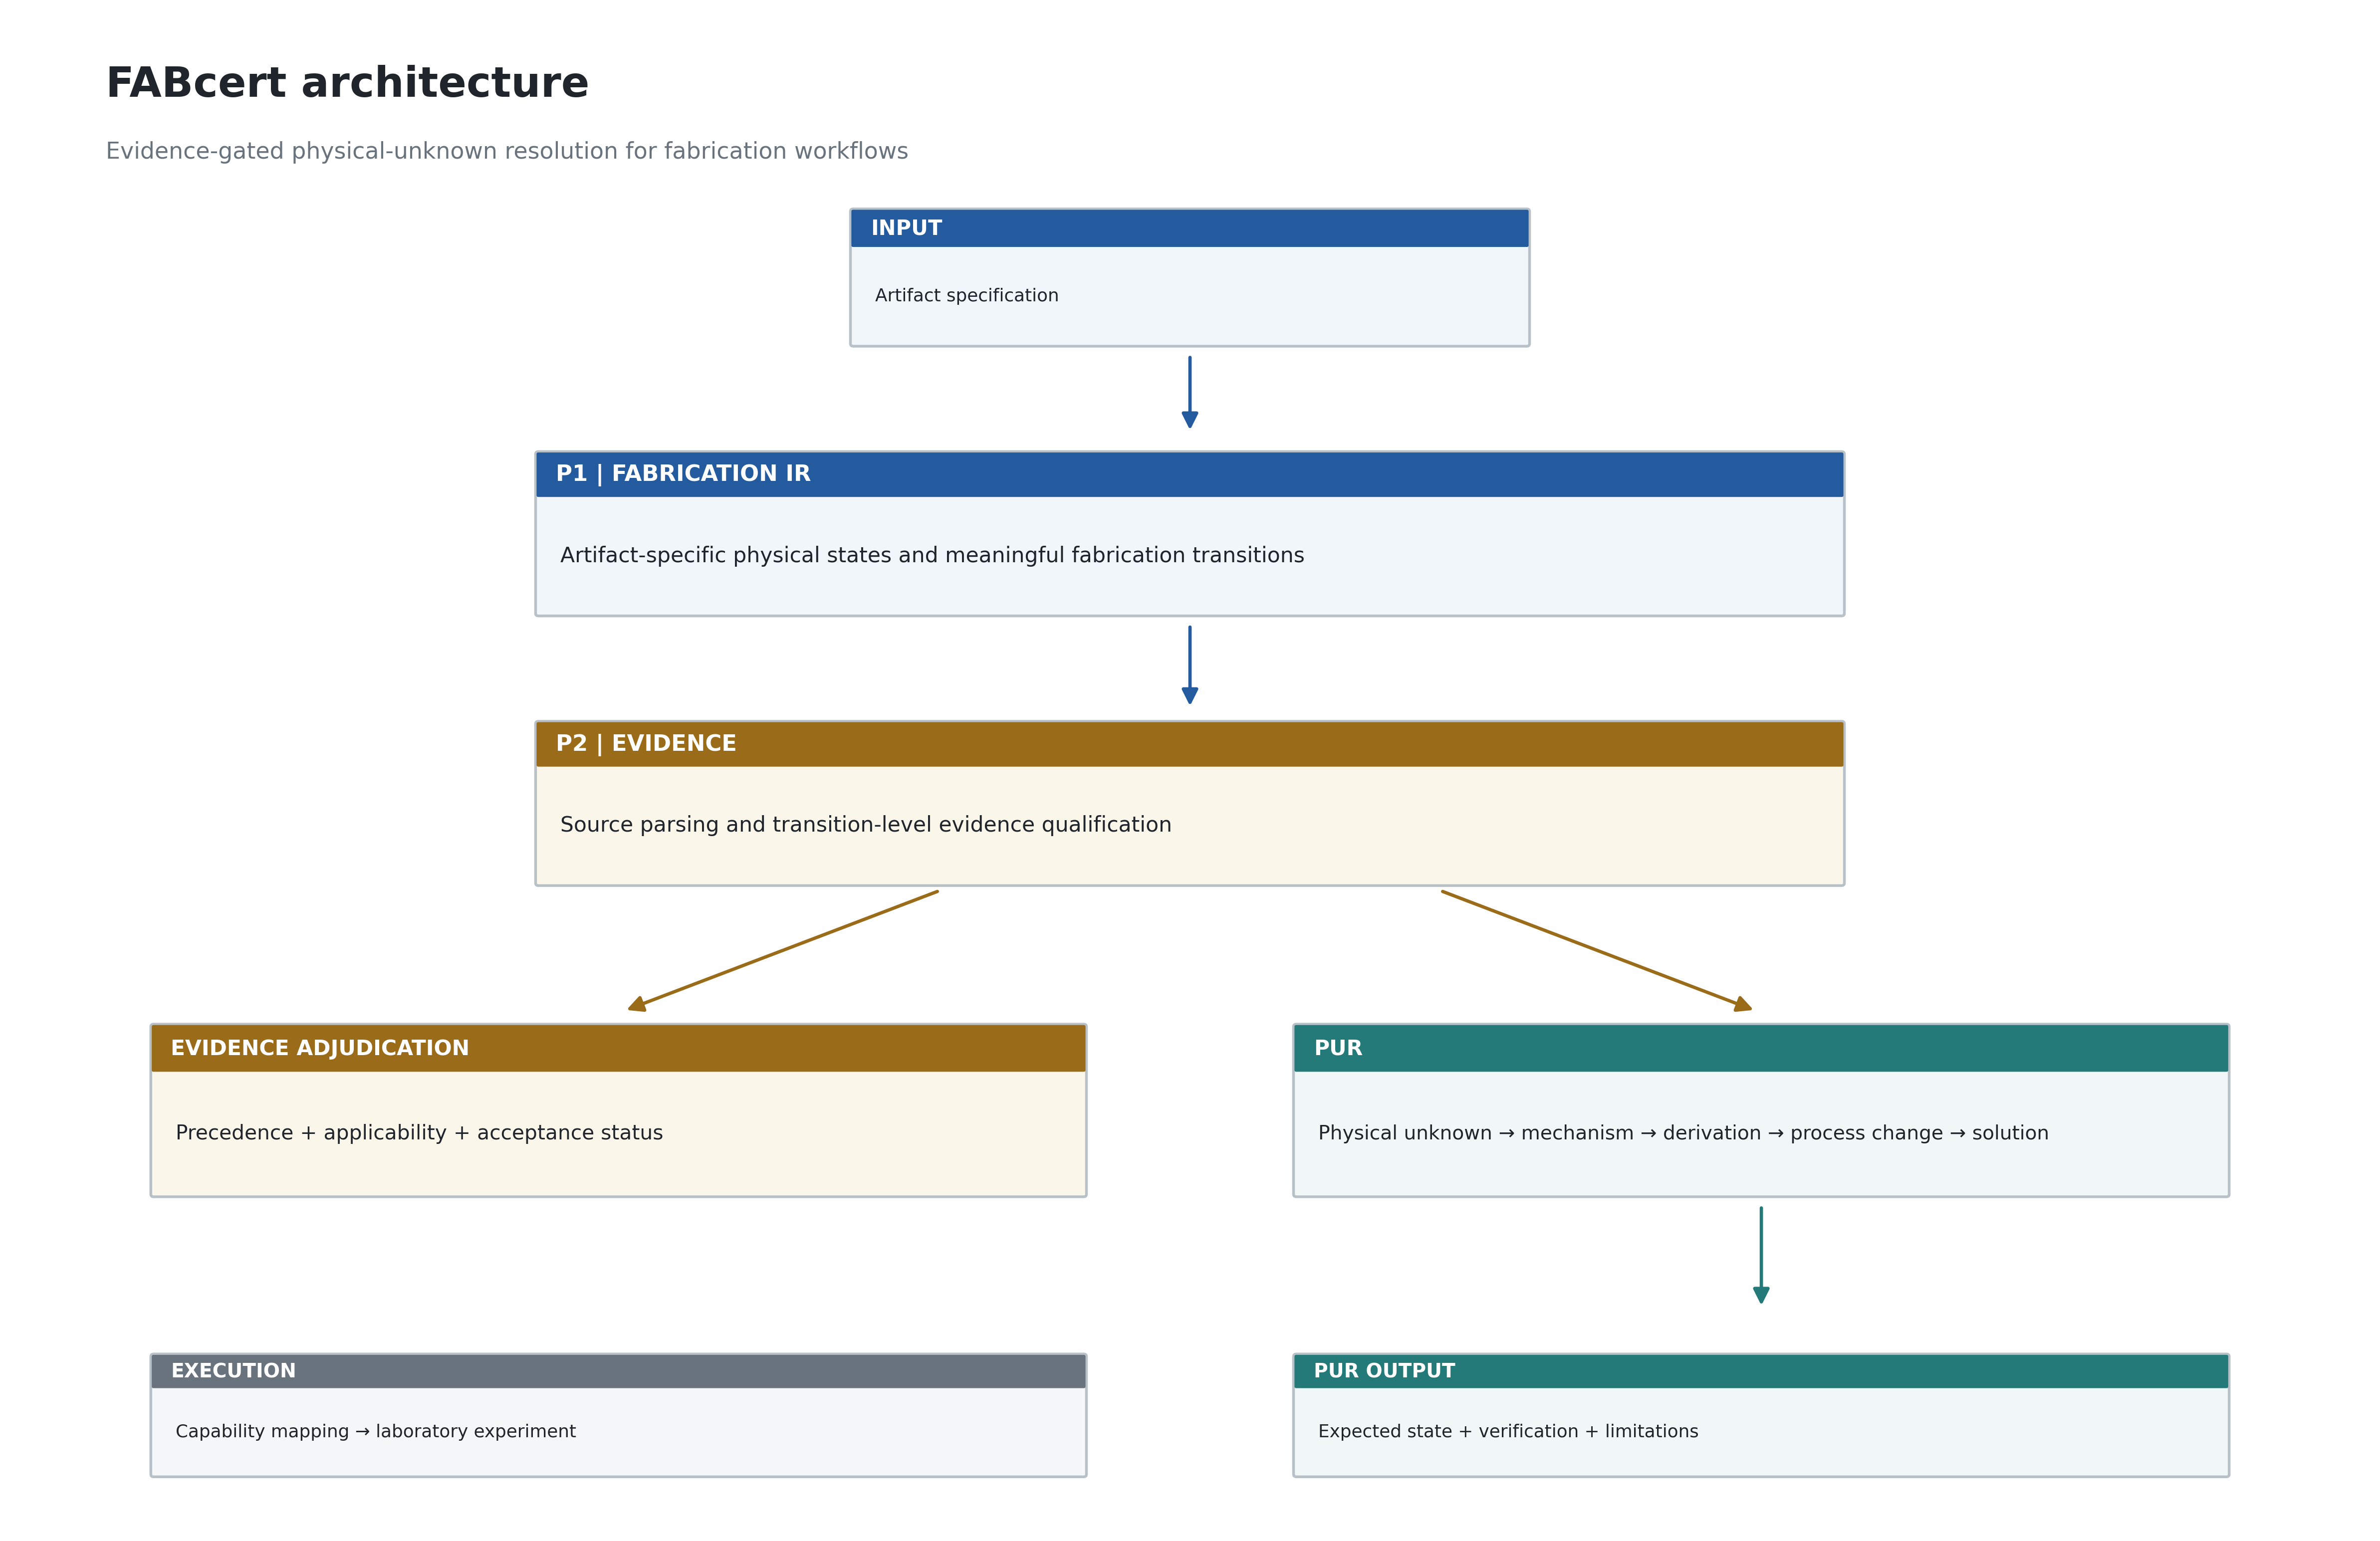


FIGURE 2 — Three fabrication pathways


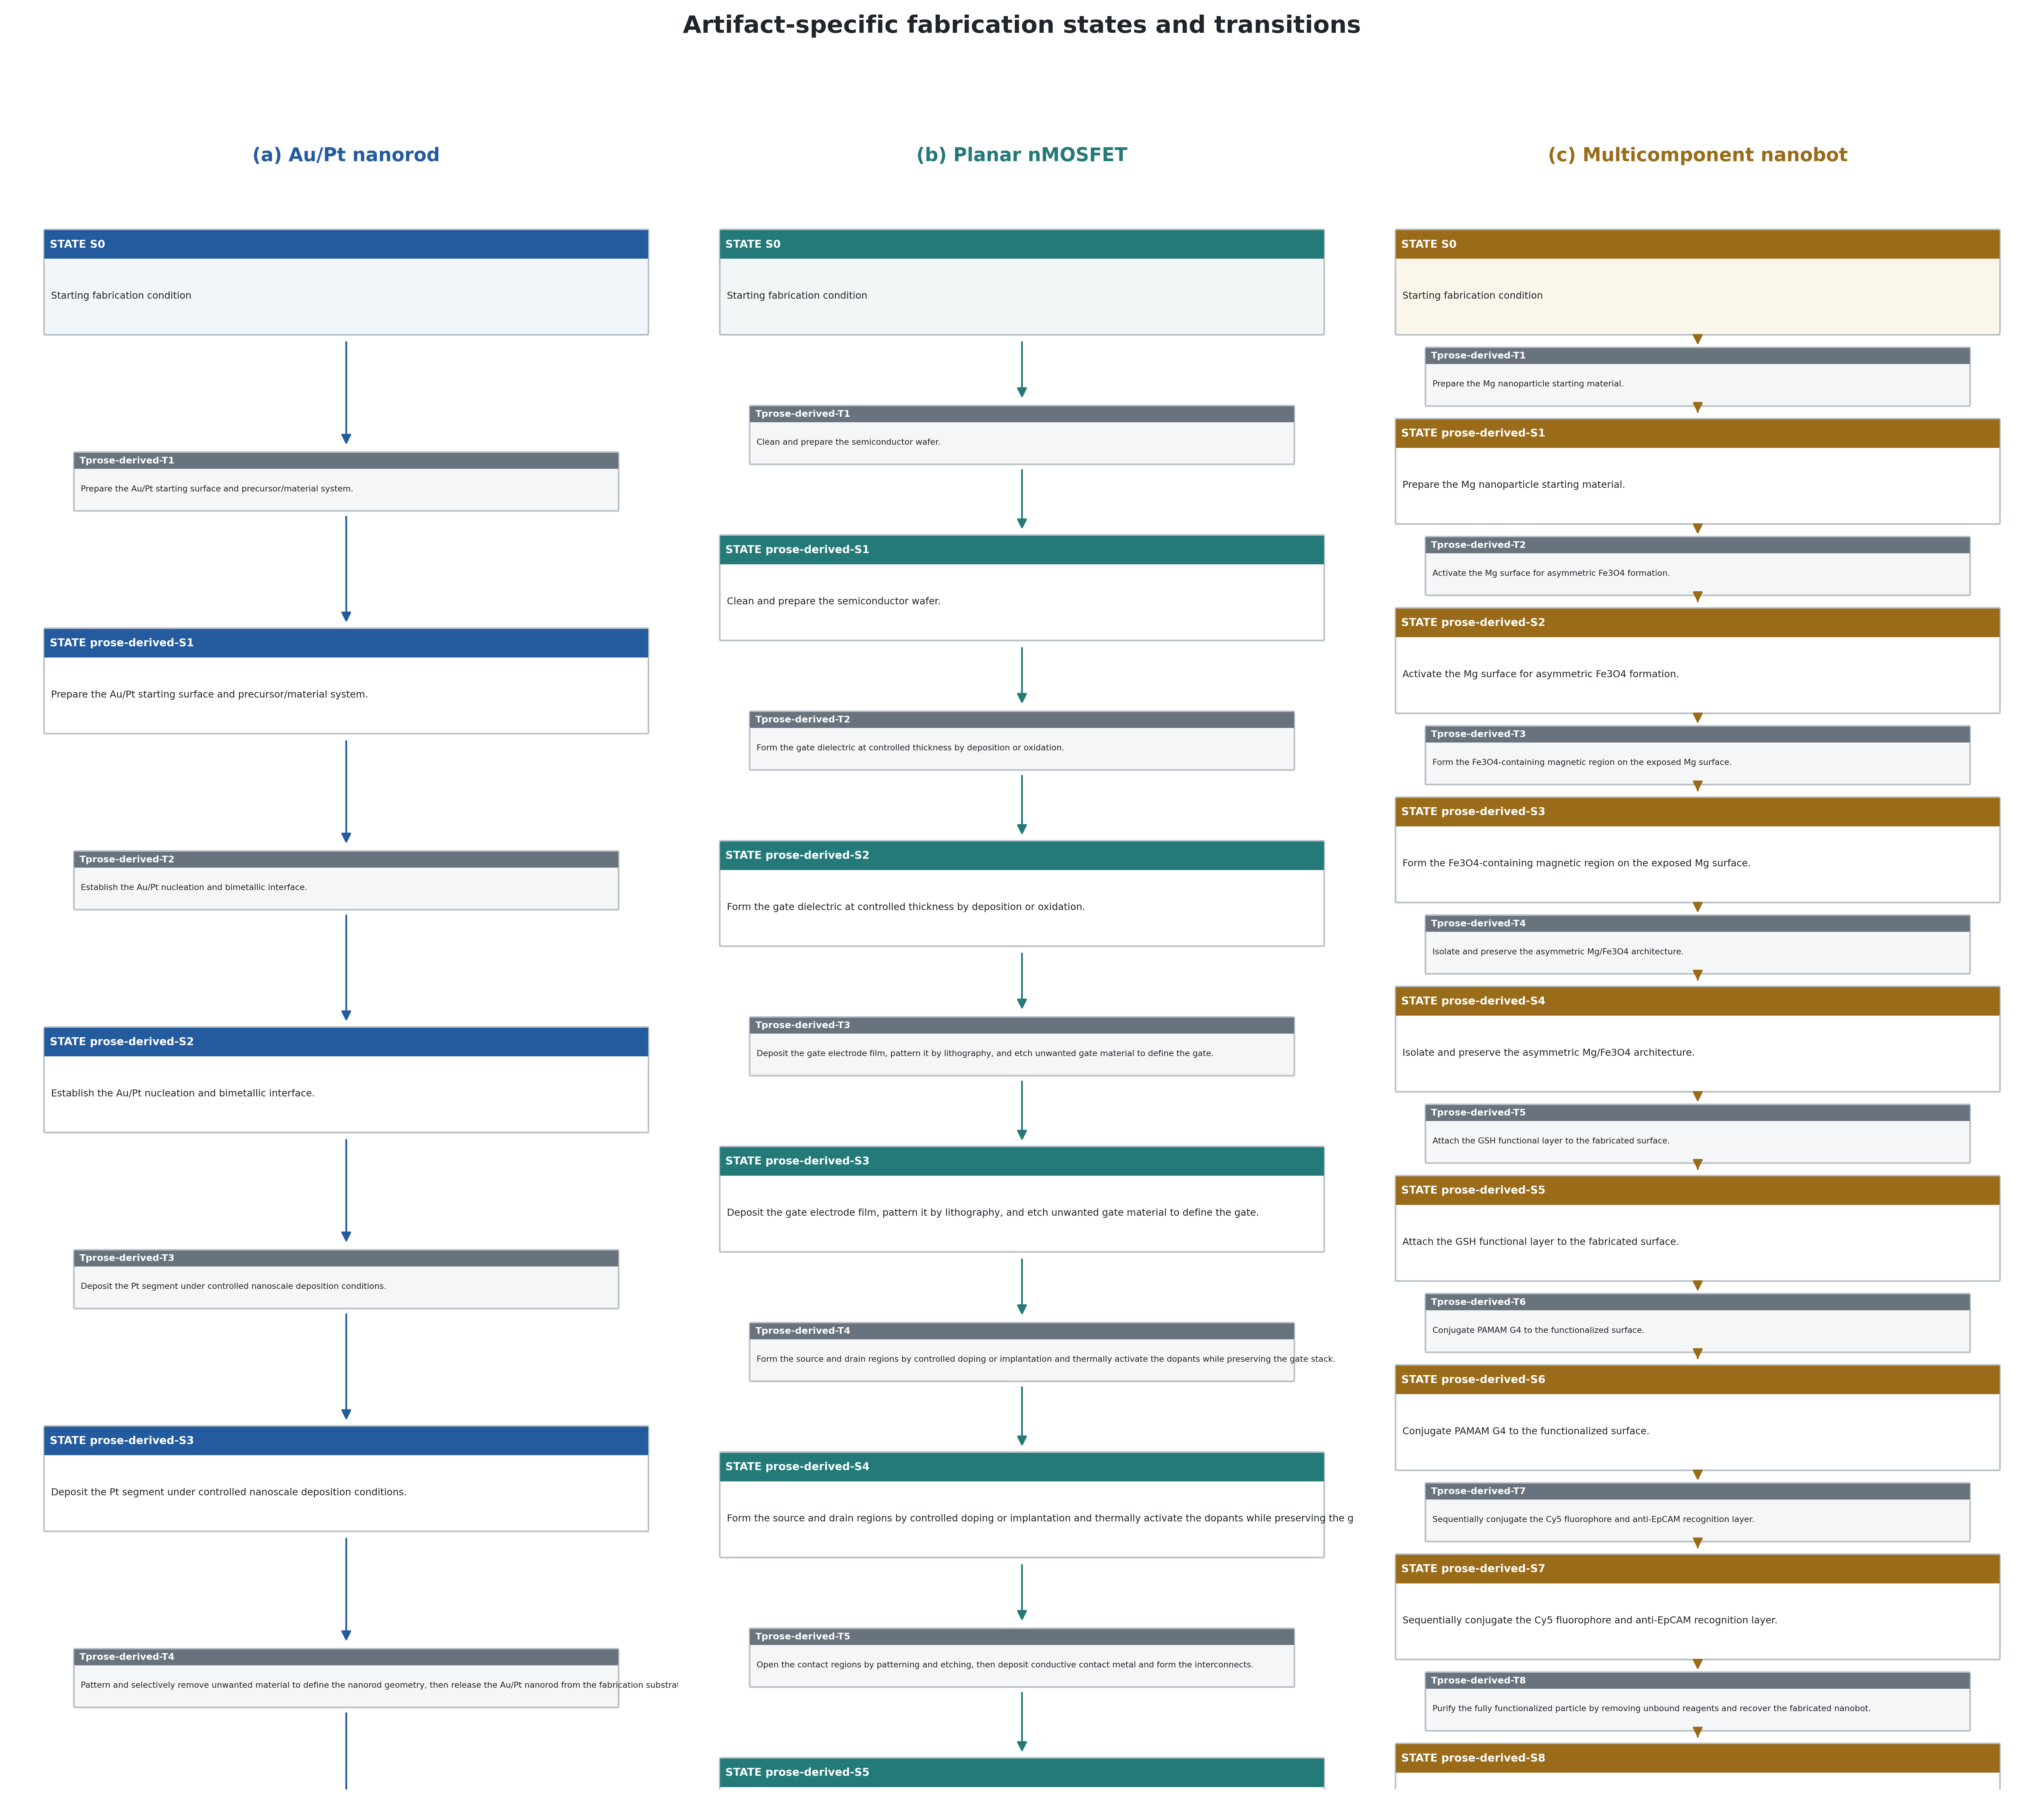


FIGURE 3 — Three-case PUR outputs



FIGURE 4 — Evidence precedence


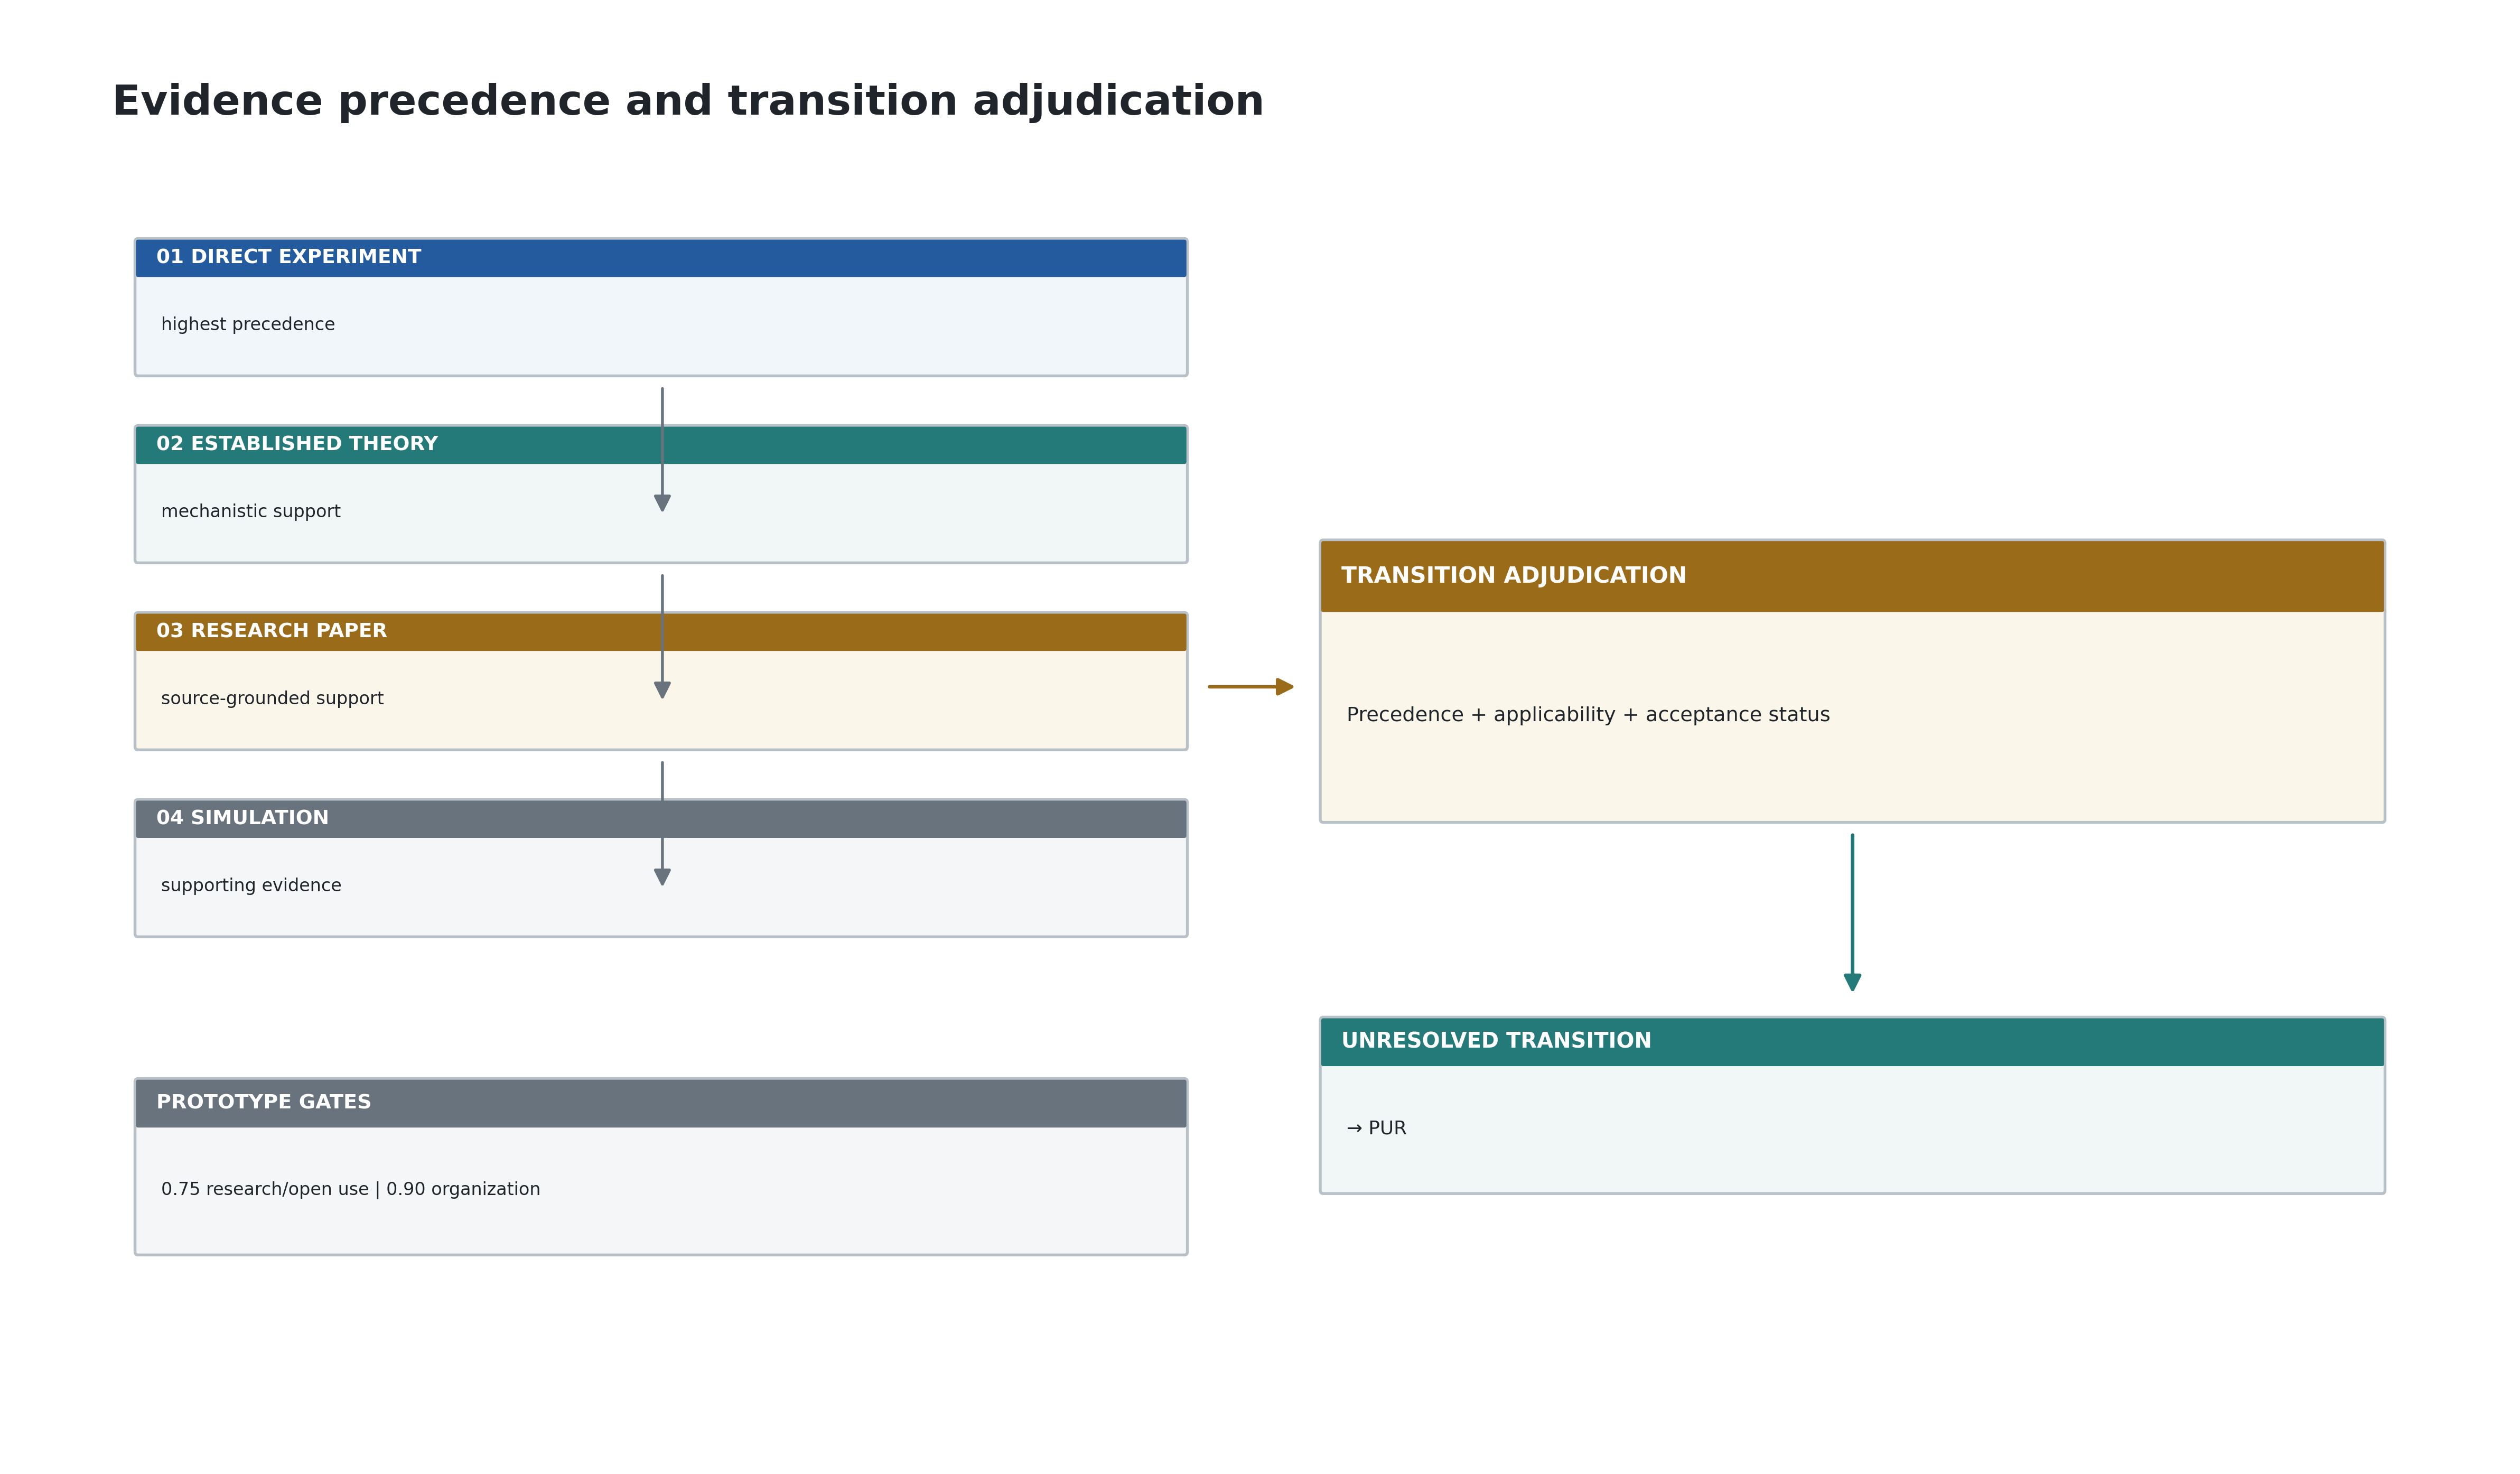


GENERATED PNG FILES

fabcert_final_figures/fig1_fabcert_architecture.png
  Resolution : 4770 × 3089 px
  DPI        : 600

fabcert_final_figures/fig2_three_fabrication_pathways.png
  Resolution : 6732 × 5943 px
  DPI        : 600

fabcert_final_figures/fig3_three_case_solution_panels.png
  Resolution : 6732 × 8035 px
  DPI        : 600

fabcert_final_figures/fig4_evidence_precedence_adjudication.png
  Resolution : 4770 × 2790 px
  DPI        : 600

All four figures have been displayed above.


In [ ]:
# ============================================================
# FABcert — FINAL PUBLICATION FIGURES
# ============================================================
#
# REQUIRED OBJECTS FROM THE FABcert PIPELINE:
#
#   nanobot_states
#   nanobot_transitions
#   mosfet_states
#   mosfet_transitions
#   multi_states
#   multi_transitions
#
#   aupt_case
#   mosfet_case
#   multi_case
#
# OUTPUT:
#   Figure 1 — FABcert architecture
#   Figure 2 — Three fabrication pathways
#   Figure 3 — Three-case PUR outputs
#   Figure 4 — Evidence precedence/adjudication
#
# All figures:
#   - PNG
#   - 600 DPI
#   - displayed inline in the notebook
#   - saved to ./fabcert_final_figures/
#
# ============================================================


# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib import font_manager

from PIL import Image, ImageFont

from IPython.display import display


# ============================================================
# OUTPUT CONFIGURATION
# ============================================================

OUTDIR = Path("fabcert_final_figures")
OUTDIR.mkdir(parents=True, exist_ok=True)

DPI = 600


# ============================================================
# PUBLICATION STYLE
# ============================================================

INK = "#20252B"
GRAY = "#68737D"
BORDER = "#B9C1C8"
WHITE = "#FFFFFF"

BLUE = "#245B9E"
BLUE_LIGHT = "#F1F6FB"

TEAL = "#247A78"
TEAL_LIGHT = "#F0F7F6"

GOLD = "#9A6B18"
GOLD_LIGHT = "#FBF6EA"

GRAY_LIGHT = "#F5F6F7"


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 7,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
})


# ============================================================
# FONT HANDLING
# ============================================================
#
# IMPORTANT:
# Do NOT hard-code:
#
# /usr/share/fonts/...
#
# This function asks Matplotlib where the installed font is.
# It therefore works on Windows/Linux/macOS environments.
# ============================================================

def get_font(size, bold=False):

    if bold:
        candidates = [
            "DejaVu Sans:style=bold",
            "Arial:style=bold",
            "Liberation Sans:style=bold",
        ]
    else:
        candidates = [
            "DejaVu Sans",
            "Arial",
            "Liberation Sans",
        ]

    for family in candidates:

        try:

            font_path = font_manager.findfont(
                family,
                fallback_to_default=True
            )

            if (
                font_path
                and Path(font_path).exists()
            ):

                return ImageFont.truetype(
                    font_path,
                    max(8, int(size * 4))
                )

        except Exception:
            continue

    # Extremely safe final fallback.
    return ImageFont.load_default()


# ============================================================
# PIXEL-BASED WORD WRAPPING
# ============================================================

def wrap_pixels(text, pixel_width, font):

    text = str(
        text
        if text is not None
        else "Not available"
    )

    words = text.split()

    if not words:
        return ""

    lines = []
    current = ""

    for word in words:

        trial = (
            word
            if not current
            else current + " " + word
        )

        if font.getlength(trial) <= pixel_width:

            current = trial

        else:

            if current:
                lines.append(current)

            # Handle exceptionally long tokens.
            if font.getlength(word) > pixel_width:

                chunk = ""

                for char in word:

                    trial = chunk + char

                    if font.getlength(trial) <= pixel_width:

                        chunk = trial

                    else:

                        if chunk:
                            lines.append(chunk)

                        chunk = char

                current = chunk

            else:

                current = word

    if current:
        lines.append(current)

    return "\n".join(lines)


# ============================================================
# TEXT FITTING
# ============================================================

def fit_text(
    ax,
    x,
    y,
    w,
    h,
    text,
    size=5.0,
    bold=False,
    color=INK,
    align="left"
):

    fig = ax.figure

    bbox = ax.get_position()

    # Estimate available output pixels at 600 DPI.
    px_width = max(
        80,
        int(
            fig.get_figwidth()
            * DPI
            * bbox.width
            * w
            / 10
        )
    )

    px_height = max(
        40,
        int(
            fig.get_figheight()
            * DPI
            * bbox.height
            * h
            / 10
        )
    )

    fontsize = float(size)

    while fontsize >= 2.8:

        font = get_font(
            fontsize,
            bold
        )

        wrapped = wrap_pixels(
            text,
            max(
                40,
                px_width - 16
            ),
            font
        )

        number_lines = (
            wrapped.count("\n") + 1
        )

        bb = font.getbbox("Ag")

        line_height = (
            max(
                9,
                bb[3] - bb[1]
            )
            * 1.15
        )

        total_height = (
            number_lines
            * line_height
        )

        if total_height <= px_height * 0.82:
            break

        fontsize -= 0.2

    ax.text(
        x,
        y + h / 2,
        wrapped,
        ha=align,
        va="center",
        fontsize=fontsize,
        fontweight=(
            "bold"
            if bold
            else "normal"
        ),
        color=color,
        linespacing=1.08,
        clip_on=True,
        zorder=8
    )


# ============================================================
# SCIENTIFIC PANEL
# ============================================================

def draw_box(
    ax,
    x,
    y,
    w,
    h,
    title,
    body,
    accent,
    fill=WHITE,
    title_size=5.0,
    body_size=4.3
):

    # Outer panel.
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            w,
            h,
            boxstyle=(
                "round,"
                "pad=0.006,"
                "rounding_size=0.012"
            ),
            facecolor=fill,
            edgecolor=BORDER,
            linewidth=0.65,
            zorder=2
        )
    )

    # Header.
    header_h = min(
        0.25,
        h * 0.27
    )

    ax.add_patch(
        FancyBboxPatch(
            (x, y + h - header_h),
            w,
            header_h,
            boxstyle=(
                "round,"
                "pad=0.002,"
                "rounding_size=0.008"
            ),
            facecolor=accent,
            edgecolor="none",
            zorder=3
        )
    )

    # Header text.
    fit_text(
        ax,
        x + 0.08,
        y + h - header_h,
        w - 0.16,
        header_h,
        title,
        size=title_size,
        bold=True,
        color=WHITE
    )

    # Body text.
    fit_text(
        ax,
        x + 0.10,
        y + 0.04,
        w - 0.20,
        h - header_h - 0.08,
        body,
        size=body_size,
        color=INK
    )


# ============================================================
# CONNECTOR
# ============================================================

def arrow(
    ax,
    x1,
    y1,
    x2,
    y2,
    color=GRAY,
    linewidth=0.8
):

    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="-|>",
            mutation_scale=8,
            linewidth=linewidth,
            color=color,
            shrinkA=2,
            shrinkB=2,
            zorder=7
        )
    )


# ============================================================
# FIGURE 1
# FABcert ARCHITECTURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.0, 5.2)
)

ax.set_xlim(0, 10)
ax.set_ylim(0, 7.2)
ax.axis("off")


ax.text(
    0.35,
    6.85,
    "FABcert architecture",
    fontsize=10,
    fontweight="bold",
    color=INK
)

ax.text(
    0.35,
    6.55,
    "Evidence-gated physical-unknown resolution for fabrication workflows",
    fontsize=5.5,
    color=GRAY
)


# INPUT

draw_box(
    ax,
    3.55,
    5.65,
    2.90,
    0.65,
    "INPUT",
    "Artifact specification",
    BLUE,
    BLUE_LIGHT
)

arrow(
    ax,
    5.00,
    5.63,
    5.00,
    5.20,
    BLUE
)


# P1

draw_box(
    ax,
    2.20,
    4.35,
    5.60,
    0.78,
    "P1 | FABRICATION IR",
    "Artifact-specific physical states and meaningful fabrication transitions",
    BLUE,
    BLUE_LIGHT,
    5.4,
    5.1
)

arrow(
    ax,
    5.00,
    4.33,
    5.00,
    3.87,
    BLUE
)


# P2

draw_box(
    ax,
    2.20,
    3.05,
    5.60,
    0.78,
    "P2 | EVIDENCE",
    "Source parsing and transition-level evidence qualification",
    GOLD,
    GOLD_LIGHT,
    5.4,
    5.1
)


# Evidence split

arrow(
    ax,
    3.95,
    3.03,
    2.55,
    2.43,
    GOLD
)

arrow(
    ax,
    6.05,
    3.03,
    7.45,
    2.43,
    GOLD
)


# Evidence adjudication

draw_box(
    ax,
    0.55,
    1.55,
    4.00,
    0.82,
    "EVIDENCE ADJUDICATION",
    "Precedence + applicability + acceptance status",
    GOLD,
    GOLD_LIGHT,
    5.1,
    4.9
)


# PUR

draw_box(
    ax,
    5.45,
    1.55,
    4.00,
    0.82,
    "PUR",
    "Physical unknown → mechanism → derivation → process change → solution",
    TEAL,
    TEAL_LIGHT,
    5.1,
    4.7
)

arrow(
    ax,
    7.45,
    1.53,
    7.45,
    0.98,
    TEAL
)


# PUR output

draw_box(
    ax,
    5.45,
    0.20,
    4.00,
    0.58,
    "PUR OUTPUT",
    "Expected state + verification + limitations",
    TEAL,
    TEAL_LIGHT,
    4.7,
    4.3
)


# Execution

draw_box(
    ax,
    0.55,
    0.20,
    4.00,
    0.58,
    "EXECUTION",
    "Capability mapping → laboratory experiment",
    GRAY,
    GRAY_LIGHT,
    4.7,
    4.3
)


fig.tight_layout()

fig1_path = (
    OUTDIR /
    "fig1_fabcert_architecture.png"
)

fig.savefig(
    fig1_path,
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white"
)

plt.close(fig)


# ============================================================
# FIGURE 2
# THREE FABRICATION PATHWAYS
# ============================================================

cases_fig2 = [

    (
        "(a) Au/Pt nanorod",
        nanobot_states,
        nanobot_transitions,
        BLUE,
        BLUE_LIGHT
    ),

    (
        "(b) Planar nMOSFET",
        mosfet_states,
        mosfet_transitions,
        TEAL,
        TEAL_LIGHT
    ),

    (
        "(c) Multicomponent nanobot",
        multi_states,
        multi_transitions,
        GOLD,
        GOLD_LIGHT
    ),
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(11.5, 10.0)
)


for ax, (
    title,
    states,
    transitions,
    accent,
    fill
) in zip(
    axes,
    cases_fig2
):

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    ax.text(
        5,
        9.85,
        title,
        ha="center",
        va="top",
        fontsize=7.4,
        fontweight="bold",
        color=accent
    )

    n = len(states)

    top = 9.35
    bottom = 0.35

    state_height = 0.62
    transition_height = 0.34

    available = (
        top
        - bottom
        - n * state_height
        - (n - 1) * transition_height
    )

    gap = max(
        0.06,
        available / max(
            1,
            n - 1
        )
    )

    y = top - state_height

    for i, state in enumerate(states):

        draw_box(
            ax,
            0.45,
            y,
            9.10,
            state_height,
            f"STATE {state.state_id}",
            state.description,
            accent,
            fill if i == 0 else WHITE,
            4.25,
            3.8
        )

        if i < len(transitions):

            transition_y = (
                y
                - gap
                - transition_height
            )

            # State -> transition
            arrow(
                ax,
                5.00,
                y - 0.02,
                5.00,
                transition_y
                + transition_height
                + 0.02,
                accent,
                0.70
            )

            draw_box(
                ax,
                0.90,
                transition_y,
                8.20,
                transition_height,
                f"T{transitions[i].transition_id}",
                transitions[i].operation,
                GRAY,
                GRAY_LIGHT,
                3.7,
                3.25
            )

            # Transition -> next state.
            next_y = (
                transition_y
                - gap
            )

            arrow(
                ax,
                5.00,
                transition_y - 0.01,
                5.00,
                next_y + 0.01,
                accent,
                0.70
            )

            y = next_y - state_height


fig.suptitle(
    "Artifact-specific fabrication states and transitions",
    fontsize=9.5,
    fontweight="bold",
    y=0.995,
    color=INK
)

fig.tight_layout(
    rect=[
        0.01,
        0.01,
        0.99,
        0.97
    ],
    w_pad=0.7
)

fig2_path = (
    OUTDIR /
    "fig2_three_fabrication_pathways.png"
)

fig.savefig(
    fig2_path,
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white"
)

plt.close(fig)


# ============================================================
# FIGURE 3
# THREE-CASE PUR OUTPUTS
# ============================================================

def get_best_solution(case):

    return max(
        case["pur_candidates"],
        key=lambda x: getattr(
            x,
            "pur_score",
            0.0
        )
    )


cases_fig3 = [

    (
        "(a) Au/Pt nanorod",
        aupt_case,
        BLUE,
        BLUE_LIGHT
    ),

    (
        "(b) MOSFET",
        mosfet_case,
        TEAL,
        TEAL_LIGHT
    ),

    (
        "(c) Multicomponent nanobot",
        multi_case,
        GOLD,
        GOLD_LIGHT
    ),
]


fig, axes = plt.subplots(
    3,
    1,
    figsize=(11.5, 13.5)
)


for ax, (
    title,
    case,
    accent,
    fill
) in zip(
    axes,
    cases_fig3
):

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 4.35)
    ax.axis("off")

    best = get_best_solution(case)

    question_map = {
        q.question_id: q
        for q in case["pur_questions"]
    }

    question = question_map.get(
        best.question_id
    )

    question_text = (
        question.question
        if question
        else "PUR question not available"
    )


    ax.text(
        0.25,
        4.23,
        title,
        fontsize=7.5,
        fontweight="bold",
        color=accent,
        va="top"
    )


    # --------------------------------------------------------
    # LEFT COLUMN
    # --------------------------------------------------------

    draw_box(
        ax,
        0.25,
        2.92,
        4.50,
        1.05,
        "PHYSICAL UNKNOWN / QUESTION",
        question_text,
        accent,
        fill,
        5.0,
        4.2
    )


    draw_box(
        ax,
        0.25,
        1.72,
        4.50,
        0.92,
        "PROPOSED SOLUTION",
        best.proposed_solution,
        accent,
        WHITE,
        4.8,
        4.1
    )


    reasoning = " ".join(
        str(x)
        for x in best.reasoning_steps
    )

    unresolved = ", ".join(
        str(x)
        for x in best.unresolved_variables
    )

    draw_box(
        ax,
        0.25,
        0.42,
        4.50,
        1.02,
        "REASONING / CONSTRAINTS",
        reasoning
        + "  Unresolved: "
        + unresolved,
        accent,
        WHITE,
        4.8,
        3.9
    )


    # --------------------------------------------------------
    # RIGHT COLUMN
    # --------------------------------------------------------

    draw_box(
        ax,
        5.25,
        2.92,
        4.50,
        1.05,
        "EXPECTED PHYSICAL STATE",
        best.expected_state,
        GRAY,
        GRAY_LIGHT,
        5.0,
        4.2
    )


    draw_box(
        ax,
        5.25,
        1.72,
        4.50,
        0.92,
        "VERIFICATION",
        "; ".join(
            str(x)
            for x in best.verification_plan
        ),
        TEAL,
        TEAL_LIGHT,
        4.8,
        4.0
    )


    evidence = (
        " ".join(
            str(x)
            for x in best.evidence_claims
        )
        if best.evidence_claims
        else
        "No transition-specific experimental evidence supplied."
    )


    limitations = " ".join(
        str(x)
        for x in best.limitations
    )


    quality = (
        f"Evidence: {evidence} "
        f"Limitations: {limitations} "
        f"Quality: "
        f"reasoning {best.reasoning_score:.2f}; "
        f"parameters {best.parameter_score:.2f}; "
        f"constraints {best.constraint_score:.2f}; "
        f"evidence {best.evidence_score:.2f}; "
        f"verification {best.verification_score:.2f}."
    )


    draw_box(
        ax,
        5.25,
        0.42,
        4.50,
        1.02,
        "EVIDENCE / LIMITATIONS / QUALITY",
        quality,
        GRAY,
        WHITE,
        4.6,
        3.55
    )


    # Connector only in the central gutter.
    arrow(
        ax,
        4.78,
        3.44,
        5.22,
        3.44,
        accent,
        0.9
    )


fig.suptitle(
    "Physical Unknown Resolution — generated question-to-solution outputs",
    fontsize=9.8,
    fontweight="bold",
    y=0.998,
    color=INK
)

fig.tight_layout(
    rect=[
        0.01,
        0.01,
        0.99,
        0.975
    ],
    h_pad=0.8
)


fig3_path = (
    OUTDIR /
    "fig3_three_case_solution_panels.png"
)


fig.savefig(
    fig3_path,
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white"
)

plt.close(fig)


# ============================================================
# FIGURE 4
# EVIDENCE PRECEDENCE
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.0, 4.7)
)

ax.set_xlim(0, 10)
ax.set_ylim(0, 5.1)
ax.axis("off")


ax.text(
    0.35,
    4.78,
    "Evidence precedence and transition adjudication",
    fontsize=9.5,
    fontweight="bold",
    color=INK
)


levels = [

    (
        "01",
        "DIRECT EXPERIMENT",
        "highest precedence",
        BLUE,
        BLUE_LIGHT
    ),

    (
        "02",
        "ESTABLISHED THEORY",
        "mechanistic support",
        TEAL,
        TEAL_LIGHT
    ),

    (
        "03",
        "RESEARCH PAPER",
        "source-grounded support",
        GOLD,
        GOLD_LIGHT
    ),

    (
        "04",
        "SIMULATION",
        "supporting evidence",
        GRAY,
        GRAY_LIGHT
    ),
]


for i, (
    num,
    label,
    note,
    accent,
    fill
) in enumerate(levels):

    y = 3.85 - i * 0.67

    draw_box(
        ax,
        0.45,
        y,
        4.25,
        0.48,
        f"{num}  {label}",
        note,
        accent,
        fill,
        4.5,
        4.0
    )

    if i < 3:

        arrow(
            ax,
            2.58,
            y - 0.02,
            2.58,
            y - 0.53,
            GRAY,
            0.65
        )


draw_box(
    ax,
    5.25,
    2.25,
    4.30,
    1.00,
    "TRANSITION ADJUDICATION",
    "Precedence + applicability + acceptance status",
    GOLD,
    GOLD_LIGHT,
    5.1,
    4.6
)


arrow(
    ax,
    4.76,
    2.73,
    5.18,
    2.73,
    GOLD
)


draw_box(
    ax,
    5.25,
    0.92,
    4.30,
    0.62,
    "UNRESOLVED TRANSITION",
    "→ PUR",
    TEAL,
    TEAL_LIGHT,
    4.8,
    4.3
)


arrow(
    ax,
    7.40,
    2.23,
    7.40,
    1.60,
    TEAL
)


draw_box(
    ax,
    0.45,
    0.70,
    4.25,
    0.62,
    "PROTOTYPE GATES",
    "0.75 research/open use  |  0.90 organization",
    GRAY,
    GRAY_LIGHT,
    4.6,
    4.0
)


fig.tight_layout()


fig4_path = (
    OUTDIR /
    "fig4_evidence_precedence_adjudication.png"
)


fig.savefig(
    fig4_path,
    dpi=DPI,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor="white"
)

plt.close(fig)


# ============================================================
# DISPLAY ALL FOUR FIGURES
# ============================================================

print()
print("=" * 70)
print("FIGURE 1 — FABcert architecture")
print("=" * 70)

display(
    Image.open(fig1_path)
)


print()
print("=" * 70)
print("FIGURE 2 — Three fabrication pathways")
print("=" * 70)

display(
    Image.open(fig2_path)
)


print()
print("=" * 70)
print("FIGURE 3 — Three-case PUR outputs")
print("=" * 70)

display(
    Image.open(fig3_path)
)


print()
print("=" * 70)
print("FIGURE 4 — Evidence precedence")
print("=" * 70)

display(
    Image.open(fig4_path)
)


# ============================================================
# OUTPUT SUMMARY
# ============================================================

print()
print("=" * 70)
print("GENERATED PNG FILES")
print("=" * 70)

for path in [
    fig1_path,
    fig2_path,
    fig3_path,
    fig4_path
]:

    image = Image.open(path)

    print(
        f"\n{path}"
        f"\n  Resolution : "
        f"{image.width} × {image.height} px"
        f"\n  DPI        : 600"
    )

print()
print("All four figures have been displayed above.")

# Research references used by this notebook

### Mathematical / Olympiad reasoning
1. Shao et al., **DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models**, 2024. DOI: 10.48550/arXiv.2402.03300.
2. Trinh et al., **Solving Olympiad Geometry without Human Demonstrations**, Nature, 2024. DOI: 10.1038/s41586-023-06747-5.
3. Lightman et al., **Let's Verify Step by Step**, ICLR, 2024. arXiv:2305.20050.
4. Wang et al., **Self-Consistency Improves Chain of Thought Reasoning in Language Models**, ICLR, 2023.
5. Schick et al., **Toolformer: Language Models Can Teach Themselves to Use Tools**, NeurIPS, 2023.
6. Yao et al., **ReAct: Synergizing Reasoning and Acting in Language Models**, ICLR, 2023.
7. Gao et al., **Omni-MATH: A Universal Olympiad Level Mathematic Benchmark for Large Language Models**, 2024.
8. Kaggle, **AI Mathematical Olympiad -- Progress Prize 3**.
9. S. Nagpure, **AIMO 3 | (42/50) - Stable LB | Possible 43+ (Luck)**, Kaggle Notebook.

### Nanorobotics / nanofabrication
10. Ju et al., **Technology Roadmap of Micro/Nanorobots**, ACS Nano, 2025, DOI: 10.1021/acsnano.5c03911.
11. Wavhale et al., **Water-powered self-propelled magnetic nanobot for rapid and highly efficient capture of circulating tumor cells**, Communications Chemistry, 2021, DOI: 10.1038/s42004-021-00598-9.
12. GO FAIR, **GO NANOFAB: Nano-Fabrication**, implementation network documentation.
13. SEMI, **Information and Control Standards** and **SEMI Standards and Smart Manufacturing**.

### Experimental MOSFET fabrication
16. Experimental MOSFET fabrication: **A 20 nm physical gate length NMOSFET with a 1.2 nm gate oxide fabricated by mixed dry and wet hard mask etching**, Solid-State Electronics, 2001, DOI: 10.1016/S0038-1101(01)00107-1.
17. Experimental MOSFET processing: **Annealing effects of polycrystalline silicon gate on electrical properties of thin gate oxide**, Solid-State Electronics, 1998, DOI: 10.1016/S0038-1101(97)00285-2.
18. Experimental sub-100-nm MOSFET fabrication and electrical characterization, **Sub-100-nm MOSFET fabrication using step and flash imprint lithography**, SPIE, 2003.

### Semiconductor manufacturing / virtual metrology
14. Tin et al., **Virtual Metrology in Semiconductor Fabrication Foundry Using Deep Learning Neural Networks**, IEEE Access, 2022, DOI: 10.1109/ACCESS.2022.3193783.
15. Maitra, Su and Shi, **Virtual metrology in semiconductor manufacturing: Current status and future prospects**, Expert Systems with Applications, 2024, DOI: 10.1016/j.eswa.2024.123559.

### AI governance / certification context
16. Tabassi, **Artificial Intelligence Risk Management Framework (AI RMF 1.0)**, NIST AI 100-1, 2023, DOI: 10.6028/NIST.AI.100-1.
17. ISO/IEC 42001:2023, **Information technology — Artificial intelligence — Management system**.
18. Microsoft, **Responsible AI Standard**, v2 and associated reference/impact-assessment materials.

### SLM / implementation
19. Qwen Team, **Qwen2.5-0.5B-Instruct**, Hugging Face model card.
20. Lattner et al., **MLIR: Scaling Compiler Infrastructure for Domain Specific Computation**, CGO, 2021.

**Citation policy:** Kaggle notebooks, model cards and industrial standards are used here for implementation/contextual references. Scholarly claims about reasoning methods are supported by peer-reviewed or archival research papers where available.

FABcert — PUR REVIEW RESULTS
PUR score = independent physical-solution solver/verifier score.
P2 evidence score = transition evidence score.
The 0.75/0.90 readiness gates are separate from both quantities.



,Case,Transition,Physical unknown / question,Selected solution,Solver mode,PUR score,P2 evidence score,P2 status,Evidence basis,Verification,PUR status
0,Au/Pt,prose-derived-T1,"Solve the physical transition 'Prepare the Au/Pt starting surface and precursor/material system.' from S0 to prose-derived-S1. Determine the mechanism and concrete process change required to obtain the target state while preserving the stated material, geometry and process constraints. If the current route is physically incompatible, identify the incompatibility and give a modified route that can resolve it; do not answer with 'monitor', 'watch', or 'test' alone.","Decompose the transition into material formation, geometry establishment, environmental compatibility and functional activation. Resolve each dependency before declaring the transition physically achievable.",process_reconstruction,0.8485,0.0625,UNRESOLVED,Target-definition source; underlying experimental references must be traced.,material characterization; geometry characterization; functional test,generated
1,Au/Pt,prose-derived-T2,"Solve the physical transition 'Establish the Au/Pt nucleation and bimetallic interface.' from prose-derived-S1 to prose-derived-S2. Determine the mechanism and concrete process change required to obtain the target state while preserving the stated material, geometry and process constraints. If the current route is physically incompatible, identify the incompatibility and give a modified route that can resolve it; do not answer with 'monitor', 'watch', or 'test' alone.","Decompose the transition into material formation, geometry establishment, environmental compatibility and functional activation. Resolve each dependency before declaring the transition physically achievable.",process_reconstruction,0.8485,0.0625,UNRESOLVED,Target-definition source; underlying experimental references must be traced.,material characterization; geometry characterization; functional test,generated
2,Au/Pt,prose-derived-T3,"Solve the physical transition 'Deposit the Pt segment under controlled nanoscale deposition conditions.' from prose-derived-S2 to prose-derived-S3. Determine the mechanism and concrete process change required to obtain the target state while preserving the stated material, geometry and process constraints. If the current route is physically incompatible, identify the incompatibility and give a modified route that can resolve it; do not answer with 'monitor', 'watch', or 'test' alone.","Decompose the transition into material formation, geometry establishment, environmental compatibility and functional activation. Resolve each dependency before declaring the transition physically achievable.",process_reconstruction,0.8485,0.0625,UNRESOLVED,Target-definition source; underlying experimental references must be traced.,material characterization; geometry characterization; functional test,generated
3,Au/Pt,prose-derived-T4,"Solve the physical transition 'Pattern and selectively remove unwanted material to define the nanorod geometry, then release the Au/Pt nanorod from the fabrication substrate or template.' from prose-derived-S3 to prose-derived-S4. Determine the mechanism and concrete process change required to obtain the target state while preserving the stated material, geometry and process constraints. If the current route is physically incompatible, identify the incompatibility and give a modified route that can resolve it; do not answer with 'monitor', 'watch', or 'test' alone.","Decompose the transition into material formation, geometry establishment, environmental compatibility and functional activation. Resolve each dependency before declaring the transition physically achievable.",process_reconstruction,0.8485,0.0625,UNRESOLVED,Target-definition source; underlying experimental references must be traced.,material characterization; geometry characterization; functional test,generated
4,Au/Pt,prose-derived-T5,"Solve the physical transition 'Wash and purify the r


PUR SCORE SUMMARY
                  Case  PUR questions / results  Scored PUR results  Best PUR score  Mean PUR score
                 Au/Pt                        5                   5          0.8485          0.8485
                MOSFET                        2                   2          0.8373          0.8373
Multicomponent nanobot                        8                   8          0.8485          0.8485


,Case,PUR questions / results,Scored PUR results,Best PUR score,Mean PUR score
0,Au/Pt,5,5,0.8485,0.8485
1,MOSFET,2,2,0.8373,0.8373
2,Multicomponent nanobot,8,8,0.8485,0.8485


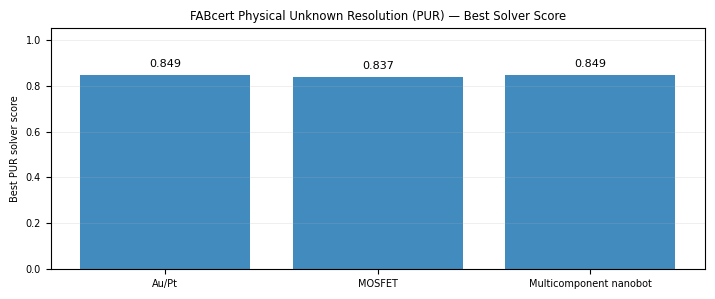

In [ ]:
# ============================================================
# PUR RESULTS —-FACING QUESTION / SOLUTION / SCORE TABLE
# ============================================================
# Enhancement only:
# - Does not modify P1, P2, PUR generation, evidence scoring, or gates.
# - Reads the PUR results already produced by the notebook.
# - Keeps PUR score explicitly separate from P2 evidence score and readiness gates.
# - Displays the physical question, selected/best solution, solver mode,
#   PUR score, verification and status.
#
# The table is intentionally generated from existing runtime objects.
# No case-specific PUR questions or scores are hardcoded here.

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def _safe_get(obj, name, default=""):
    if obj is None:
        return default
    if isinstance(obj, dict):
        return obj.get(name, default)
    return getattr(obj, name, default)

def _flatten_text(value):
    if value is None:
        return ""
    if isinstance(value, (list, tuple)):
        return "; ".join(str(x) for x in value)
    if isinstance(value, dict):
        return "; ".join(f"{k}={v}" for k, v in value.items())
    return str(value)

def _find_pur_score(obj):
    # Preserve the notebook's actual PUR scoring terminology where available.
    for key in (
        "pur_score",
        "final_candidate_score",
        "solver_score",
        "score",
        "verifier_score",
    ):
        value = _safe_get(obj, key, None)
        if value is not None and value != "":
            try:
                return float(value)
            except (TypeError, ValueError):
                pass
    return None

def _best_candidates(results):
    if results is None:
        return []
    if isinstance(results, dict):
        results = list(results.values())
    try:
        rows = list(results)
    except TypeError:
        return []
    return rows

# Discover case-level PUR results from the common CASE_PIPELINES schema.
# This keeps the table dynamic and avoids hardcoded case-specific answers.
_case_sources = []
if "CASE_PIPELINES" in globals():
    for label, case in CASE_PIPELINES.items():
        _case_sources.append((label, case))
else:
    for name, label in (
        ("aupt_pur_results", "Au/Pt"),
        ("mosfet_pur_results", "MOSFET"),
        ("multi_pur_results", "Multicomponent nanobot"),
    ):
        if name in globals():
            _case_sources.append((label, {
                "pur_candidates": globals()[name],
                "pur_questions": globals().get(
                    name.replace("_pur_results", "_pur_questions"), []
                ),
                "adjudication": {},
            }))

pur_display_rows = []

for case_label, case_or_results in _case_sources:
    if isinstance(case_or_results, dict):
        results = case_or_results.get("pur_candidates", [])
        questions = case_or_results.get("pur_questions", [])
        adjudication = case_or_results.get("adjudication", {})
    else:
        results = case_or_results
        questions = []
        adjudication = {}

    rows = _best_candidates(results)

    # Select the highest-scoring generated candidate for each actual PUR
    # question. This is a dynamic tournament result, not a hardcoded answer.
    by_question = {}
    for item in rows:
        qid = _safe_get(item, "question_id", "")
        if isinstance(item, (tuple, list)) and len(item) >= 2:
            solution = item[1]
            qid = _safe_get(solution, "question_id", qid)
        else:
            solution = item
        by_question.setdefault(qid, []).append(solution)

    question_map = {
        _safe_get(q, "question_id", ""): q
        for q in questions
    }

    for qid, candidates_for_question in by_question.items():
        solution = max(
            candidates_for_question,
            key=lambda x: _find_pur_score(x) if _find_pur_score(x) is not None else -1.0
        )
        question = question_map.get(qid)

        q_text = _flatten_text(
            _safe_get(question, "question", qid)
        )

        solution_text = (
            _safe_get(solution, "proposed_solution", None)
            or _safe_get(solution, "final_solution", None)
            or _safe_get(solution, "solution", None)
            or _flatten_text(solution)
        )

        solver_mode = (
            _safe_get(solution, "solver_mode", None)
            or _safe_get(solution, "mode", None)
            or _safe_get(solution, "solver", "")
        )

        score = _find_pur_score(solution)

        verification = (
            _safe_get(solution, "verification_plan", None)
            or _safe_get(solution, "verification_condition", None)
        )

        evidence_basis = (
            _safe_get(solution, "evidence_claims", None)
            or _safe_get(solution, "source_basis", None)
        )

        transition_id = (
            _safe_get(question, "transition_id", None)
            or _safe_get(solution, "transition_id", "")
        )

        # P2 evidence is deliberately reported as a separate quantity.
        p2_score = None
        p2_status = ""
        if transition_id in adjudication:
            p2_score = adjudication[transition_id].get("score")
            p2_status = adjudication[transition_id].get("status", "")

        pur_display_rows.append({
            "Case": case_label,
            "Transition": transition_id,
            "Physical unknown / question": q_text,
            "Selected solution": _flatten_text(solution_text),
            "Solver mode": _flatten_text(solver_mode),
            "PUR score": score,
            "P2 evidence score": p2_score,
            "P2 status": p2_status,
            "Evidence basis": _flatten_text(evidence_basis),
            "Verification": _flatten_text(verification),
            "PUR status": _flatten_text(
                _safe_get(solution, "status", "generated")
            ),
        })

if pur_display_rows:
    PUR_REVIEW_TABLE = pd.DataFrame(pur_display_rows)

    print("=" * 100)
    print("FABcert — PUR RESULTS")
    print("=" * 100)
    print("PUR score = independent physical-solution solver/verifier score.")
    print("P2 evidence score = transition evidence score.")
    print("The 0.75/0.90 readiness gates are separate from both quantities.")
    print()

    display(
        PUR_REVIEW_TABLE.style
        .format({
            "PUR score": lambda x: "" if pd.isna(x) else f"{x:.4f}",
            "P2 evidence score": lambda x: "" if pd.isna(x) else f"{x:.4f}",
        })
        .set_properties(**{
            "white-space": "pre-wrap",
            "vertical-align": "top"
        })
    )

    # Compact case-level summary for the paper/ view.
    summary_rows = []
    for case_label, group in PUR_REVIEW_TABLE.groupby("Case", sort=False):
        scores = pd.to_numeric(group["PUR score"], errors="coerce").dropna()
        summary_rows.append({
            "Case": case_label,
            "PUR questions / results": len(group),
            "Scored PUR results": int(scores.notna().sum()),
            "Best PUR score": scores.max() if len(scores) else None,
            "Mean PUR score": scores.mean() if len(scores) else None,
        })

    PUR_SCORE_SUMMARY = pd.DataFrame(summary_rows)

    print("\nPUR SCORE SUMMARY")
    print(PUR_SCORE_SUMMARY.to_string(index=False))
    display(
        PUR_SCORE_SUMMARY.style
        .format({
            "Best PUR score": lambda x: "" if pd.isna(x) else f"{x:.4f}",
            "Mean PUR score": lambda x: "" if pd.isna(x) else f"{x:.4f}",
        })
        .set_properties(**{
            "white-space": "pre-wrap",
            "vertical-align": "top"
        })
    )

    # Neat, paper-friendly score figure: PUR only.
    # It intentionally does not plot P2 evidence or readiness thresholds here,
    # preventing visual conflation of the three quantities.
    scored_summary = PUR_SCORE_SUMMARY.dropna(subset=["Best PUR score"]).copy()

    if len(scored_summary):
        fig_pur_score, ax = plt.subplots(figsize=(7.16, 3.0))
        ax.bar(
            scored_summary["Case"],
            scored_summary["Best PUR score"],
            alpha=0.85
        )
        ax.set_ylabel("Best PUR solver score")
        ax.set_title("FABcert Physical Unknown Resolution (PUR) — Best Solver Score")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", alpha=0.20, linewidth=0.7)

        for i, value in enumerate(scored_summary["Best PUR score"]):
            ax.text(i, value + 0.025, f"{value:.3f}",
                    ha="center", va="bottom", fontsize=8)

        fig_pur_score.tight_layout()
        display(fig_pur_score)
        plt.close(fig_pur_score)
else:
    print("No existing PUR result objects were found. Run the existing PUR case-study cells first.")